In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

In [2]:
df = pd.read_csv('bangkok_traffy.csv')

In [3]:
df.head()

,ticket_id,type,organization,comment,photo,photo_after,coords,address,subdistrict,district,province,timestamp,state,star,count_reopen,last_activity
0,2021-FYJTFP,{ความสะอาด},เขตบางซื่อ,ขยะเยอะ,https://storage.googleapis.com/traffy_public_b...,NaN,"100.53084,13.81865",12/14 ถนน กรุงเทพ- นนทบุรี แขวง บางซื่อ เขตบาง...,NaN,NaN,กรุงเทพมหานคร,2021-09-03 12:51:09.453003+00,เสร็จสิ้น,NaN,0,2022-06-04 15:34:14.609206+00
1,2021-CGPMUN,"{น้ำท่วม,ร้องเรียน}","เขตประเวศ,ฝ่ายโยธา เขตประเวศ",น้ำท่วมเวลาฝนตกและทะลุเข้าบ้านเดือดร้อนมากทุกๆ...,https://storage.googleapis.com/traffy_public_b...,https://storage.googleapis.com/traffy_public_b...,"100.66709,13.67891",189 เฉลิมพระเกียรติ ร.9 แขวง หนองบอน เขต ประเว...,หนองบอน,ประเวศ,กรุงเทพมหานคร,2021-09-19 14:56:08.924992+00,เสร็จสิ้น,4.0,0,2022-06-21 08:21:09.532782+00
2,2021-7XATFA,{สะพาน},เขตสาทร,สะพานลอยปรับปรุงไม่เสร็จตามกำหนด\nปากซอย สาทร12,https://storage.googleapis.com/traffy_public_b...,NaN,"100.52649,13.72060",191/1 ถนน สาทรเหนือ แขวง สีลม เขตบางรัก กรุงเท...,ยานนาวา,สาทร,กรุงเทพมหานคร,2021-09-26 05:03:52.594898+00,เสร็จสิ้น,NaN,0,2022-06-06 01:17:12.272904+00
3,2021-9U2NJT,{น้ำท่วม},"เขตบางซื่อ,ฝ่ายโยธา เขตบางซื่อ",น้ำท่วม,https://storage.googleapis.com/traffy_public_b...,https://storage.googleapis.com/traffy_public_b...,"100.53099,13.81853",12/14 ถนน กรุงเทพ- นนทบุรี แขวง บางซื่อ เขตบาง...,NaN,NaN,กรุงเทพมหานคร,2021-10-14 10:45:27.713884+00,เสร็จสิ้น,NaN,0,2022-09-08 08:35:43.784519+00
4,2021-DVEWYM,"{น้ำท่วม,ถนน}","เขตลาดพร้าว,ฝ่ายโยธา เขตลาดพร้าว",ซอยลาดพร้าววังหิน 75 ถนนลาดพร้าววังหิน แขวงลาด...,https://storage.googleapis.com/traffy_public_b...,NaN,"100.59165,13.82280",702 ถ. ลาดพร้าววังหิน แขวงลาดพร้าว เขตลาดพร้าว...,ลาดพร้าว,ลาดพร้าว,กรุงเทพมหานคร,2021-12-09 12:29:08.408763+00,เสร็จสิ้น,5.0,0,2022-08-12 07:18:44.884945+00


In [4]:
df.shape

(787026, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787026 entries, 0 to 787025
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ticket_id      778254 non-null  object 
 1   type           786929 non-null  object 
 2   organization   786455 non-null  object 
 3   comment        778254 non-null  object 
 4   photo          786911 non-null  object 
 5   photo_after    641309 non-null  object 
 6   coords         787026 non-null  object 
 7   address        778254 non-null  object 
 8   subdistrict    786460 non-null  object 
 9   district       786465 non-null  object 
 10  province       786831 non-null  object 
 11  timestamp      787026 non-null  object 
 12  state          787026 non-null  object 
 13  star           274097 non-null  float64
 14  count_reopen   787026 non-null  int64  
 15  last_activity  787026 non-null  object 
dtypes: float64(1), int64(1), object(14)
memory usage: 96.1+ MB


In [6]:
df['state'].unique()
df.shape

(787026, 16)

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['type'])
df = df.dropna(subset=['district'])
df.shape

(786368, 16)

In [8]:
df.isnull().sum()

ticket_id          8771
type                  0
organization        443
comment            8771
photo               102
photo_after      145504
coords                0
address            8771
subdistrict           7
district              0
province              0
timestamp             1
state                 0
star             512301
count_reopen          0
last_activity         0
dtype: int64

In [9]:
df2 = df[['timestamp', 'type', 'state', 'district']].copy()
df2.head()
df['type'].apply(type).value_counts()


type
<class 'str'>    786368
Name: count, dtype: int64

In [10]:
df2['type'] = (
    df2['type']
    .str.replace(r'[{}]', '', regex=True)  # ลบ { }
    .str.split(',')                        # split ด้วย comma
)

df2 = df2.explode('type').reset_index(drop=True)


In [11]:
df2.head()

,timestamp,type,state,district
0,2021-09-19 14:56:08.924992+00:00,น้ำท่วม,เสร็จสิ้น,ประเวศ
1,2021-09-19 14:56:08.924992+00:00,ร้องเรียน,เสร็จสิ้น,ประเวศ
2,2021-09-26 05:03:52.594898+00:00,สะพาน,เสร็จสิ้น,สาทร
3,2021-12-09 12:29:08.408763+00:00,น้ำท่วม,เสร็จสิ้น,ลาดพร้าว
4,2021-12-09 12:29:08.408763+00:00,ถนน,เสร็จสิ้น,ลาดพร้าว


In [12]:
df2['state'].unique()

array(['เสร็จสิ้น', 'กำลังดำเนินการ', 'รอรับเรื่อง'], dtype=object)

In [13]:
unresolved = df2[df2['state'].isin(['รอรับเรื่อง', 'กำลังดำเนินการ'])].copy()

In [14]:
df_sorted = df2.sort_values(['district', 'timestamp'])
df_sorted['next_type'] = df_sorted.groupby('district')['type'].shift(-1)
df_sorted['next_state'] = df_sorted.groupby('district')['state'].shift(-1)

In [15]:
chain = df_sorted[df_sorted['state'].isin(['รอรับเรื่อง', 'กำลังดำเนินการ'])]

In [16]:
pattern = chain.groupby(['district', 'type', 'next_type']).size().reset_index(name='count')
pattern = pattern.sort_values('count', ascending=False)
pattern

,district,type,next_type,count
6635,บางขุนเทียน,ทางเท้า,ทางเท้า,556
10516,ปทุมวัน,,,456
18735,หนองจอก,ถนน,ถนน,353
6696,บางขุนเทียน,ป้าย,ทางเท้า,352
6638,บางขุนเทียน,ทางเท้า,ป้าย,346
...,...,...,...,...
11,คลองสาน,,คนจรจัด,1
7,กะทู้,,,1
6,กระทุ่มแบน,ถนน,ความปลอดภัย,1
5,กระทุ่มแบน,จราจร,ถนน,1


In [17]:
pattern.shape
pattern.isnull().sum()

district     0
type         0
next_type    0
count        0
dtype: int64

In [18]:
pattern[pattern['district'] == 'ปทุมวัน']

,district,type,next_type,count
10516,ปทุมวัน,,,456
10758,ปทุมวัน,ทางเท้า,ทางเท้า,325
10733,ปทุมวัน,ถนน,ทางเท้า,266
10757,ปทุมวัน,ทางเท้า,ถนน,208
10732,ปทุมวัน,ถนน,ถนน,196
...,...,...,...,...
10554,ปทุมวัน,PM2.5,แสงสว่าง,1
10553,ปทุมวัน,PM2.5,เสียงรบกวน,1
10552,ปทุมวัน,PM2.5,เสนอแนะ,1
10551,ปทุมวัน,PM2.5,สายไฟ,1


In [19]:
# Fill NaN next_type with a label (optional)
pattern['next_type'] = pattern['next_type'].fillna("ไม่มีเหตุการณ์ถัดไป")

# Create a list of districts
districts = pattern['district'].unique()

In [20]:
# Try using Sarabun or fallback to Tahoma
font_path = r"C:\Windows\Fonts\angsana.ttc"  # <-- change if needed

# Load font
font = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font.get_name()
plt.rcParams['axes.unicode_minus'] = False

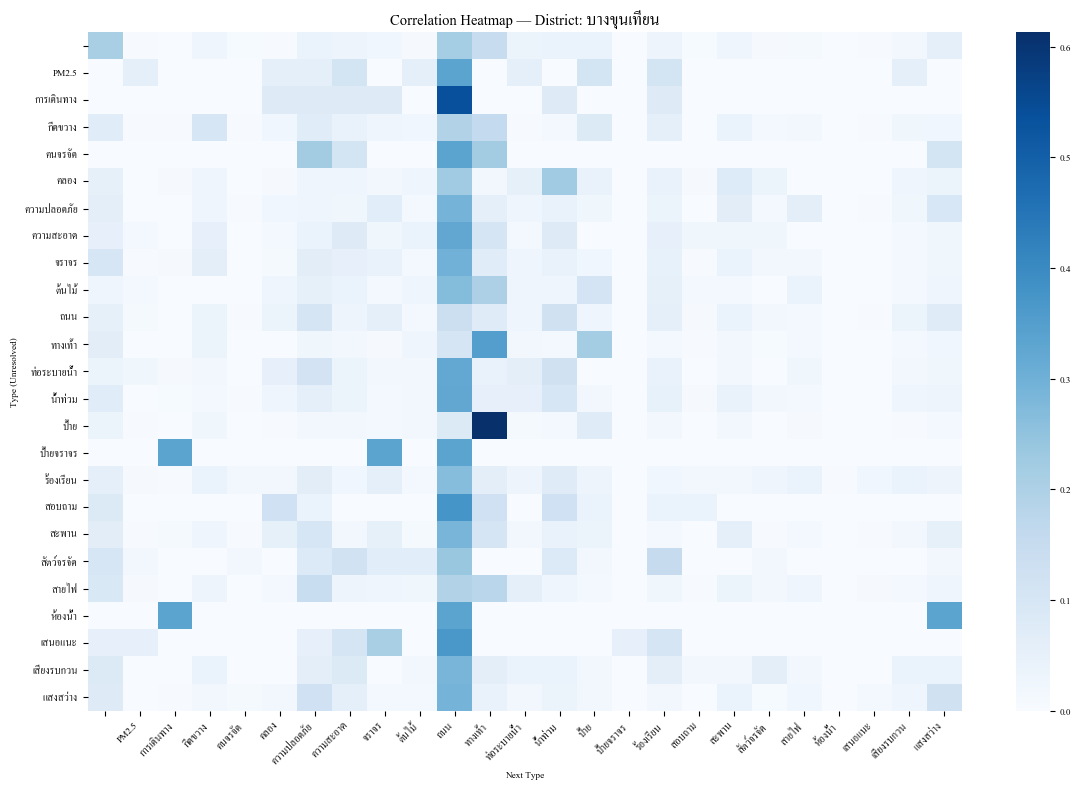

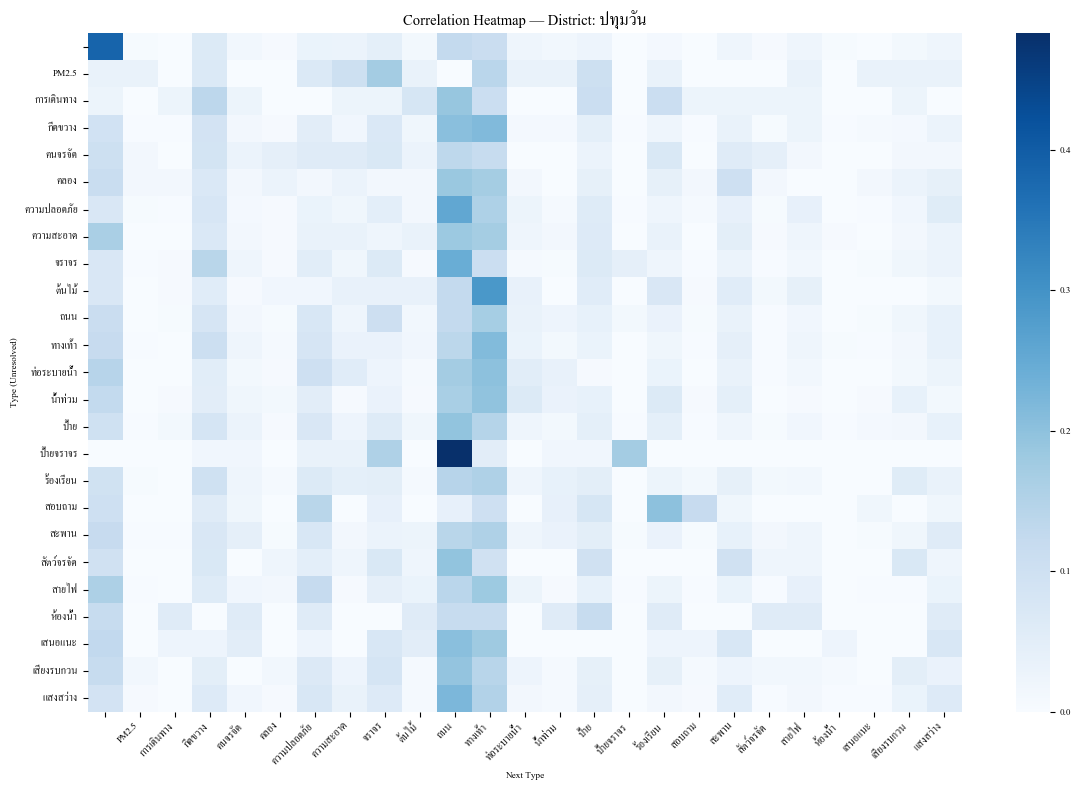

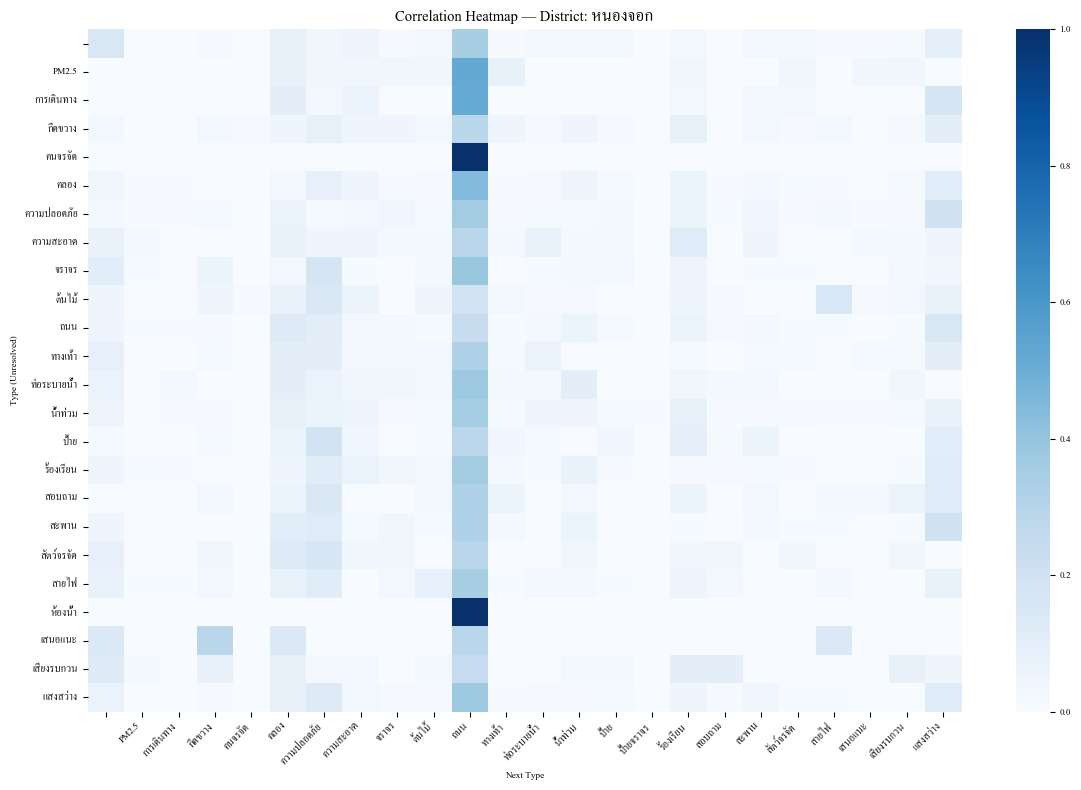

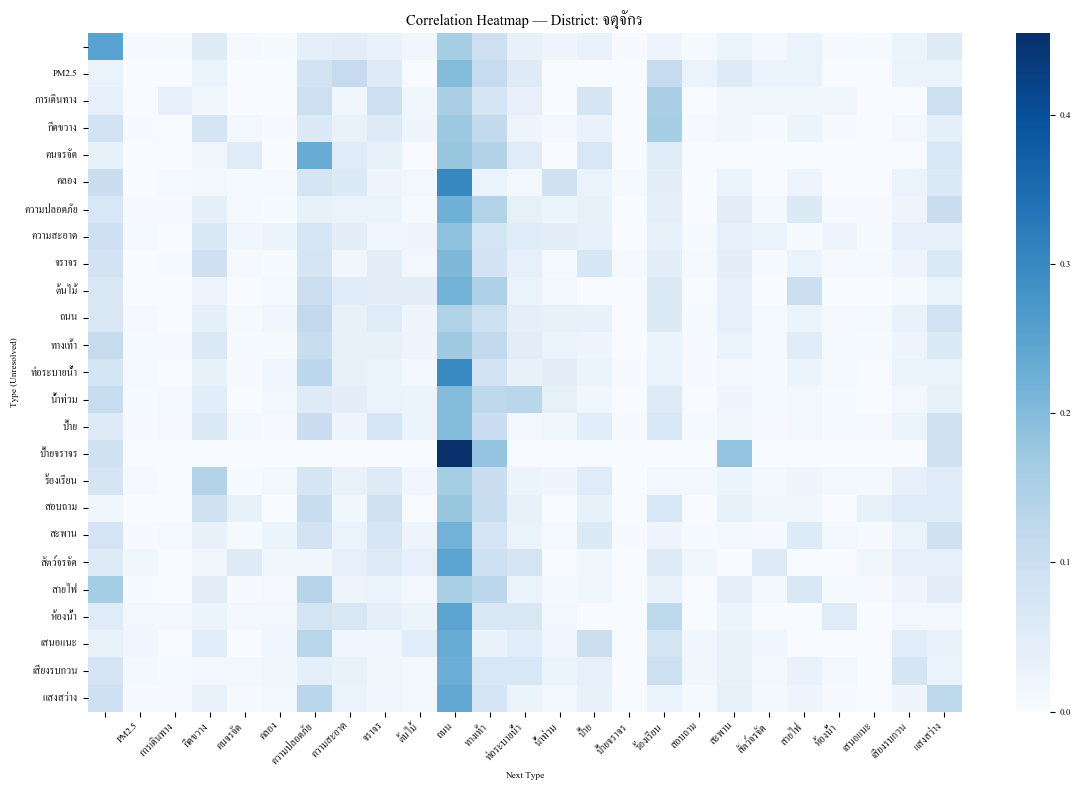

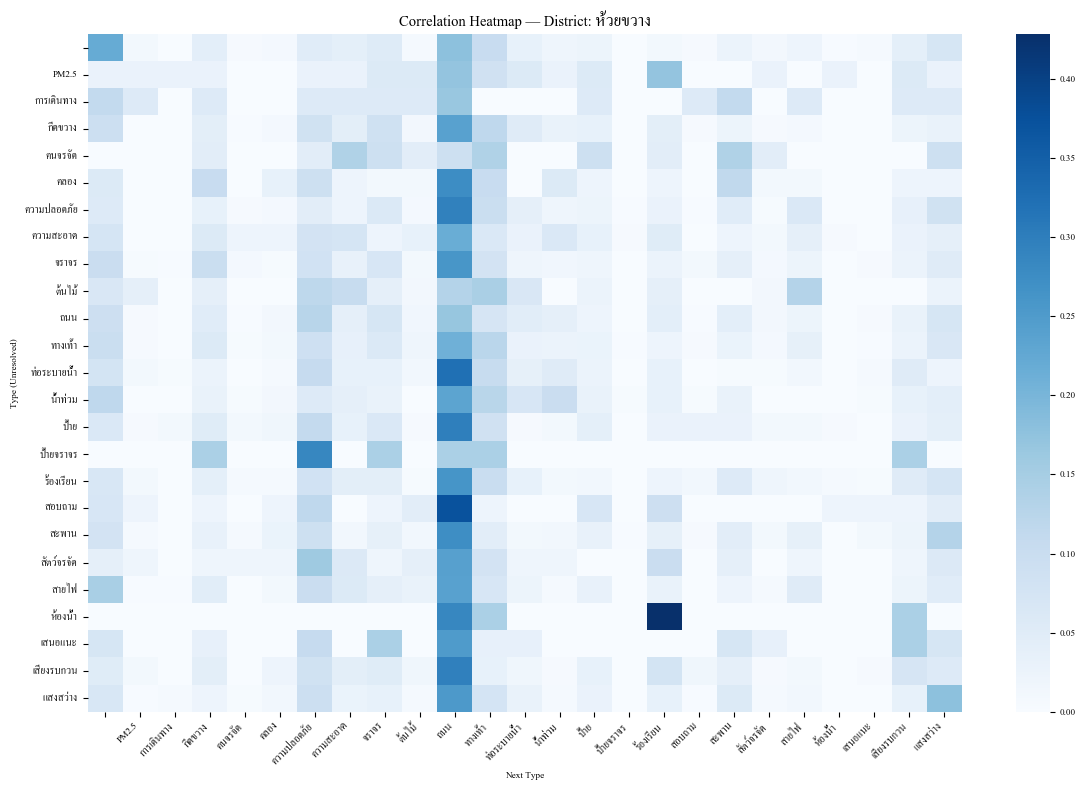

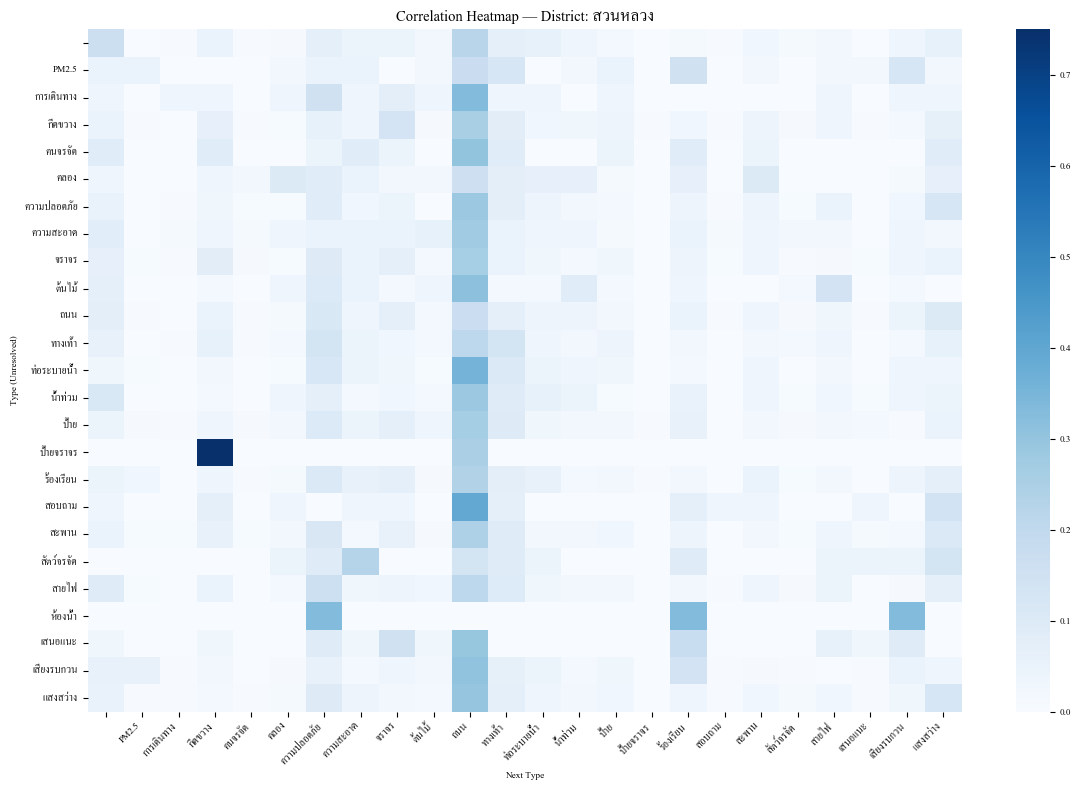

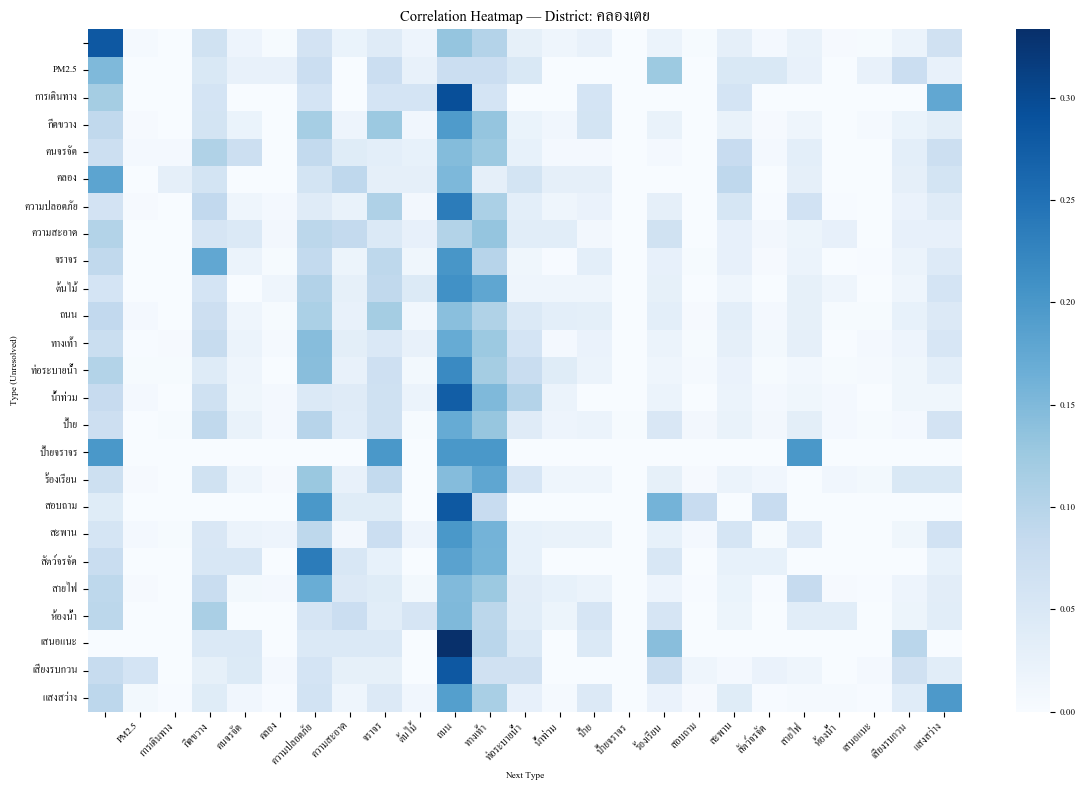

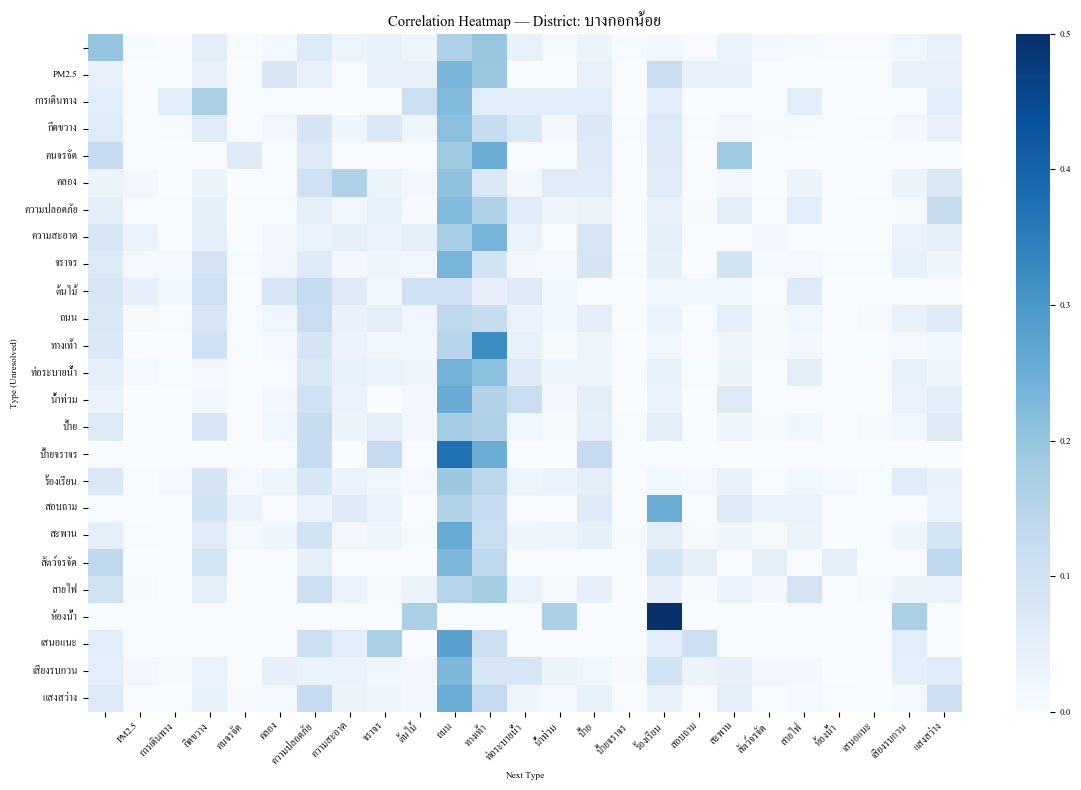

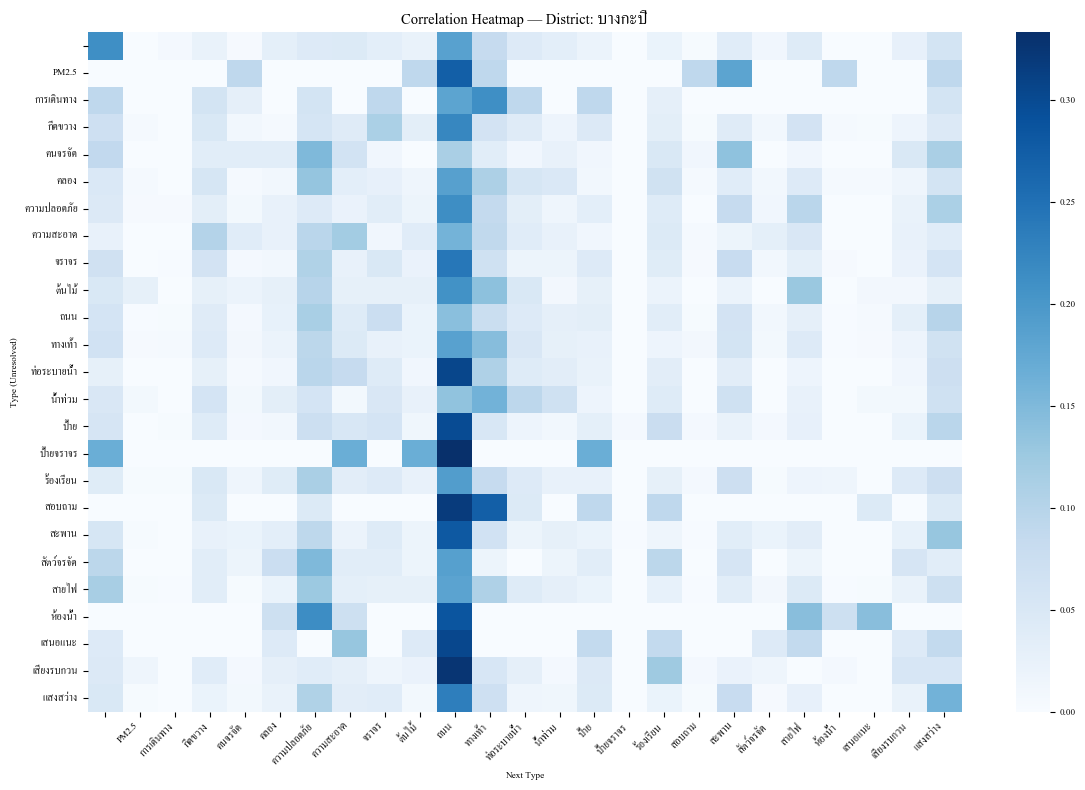

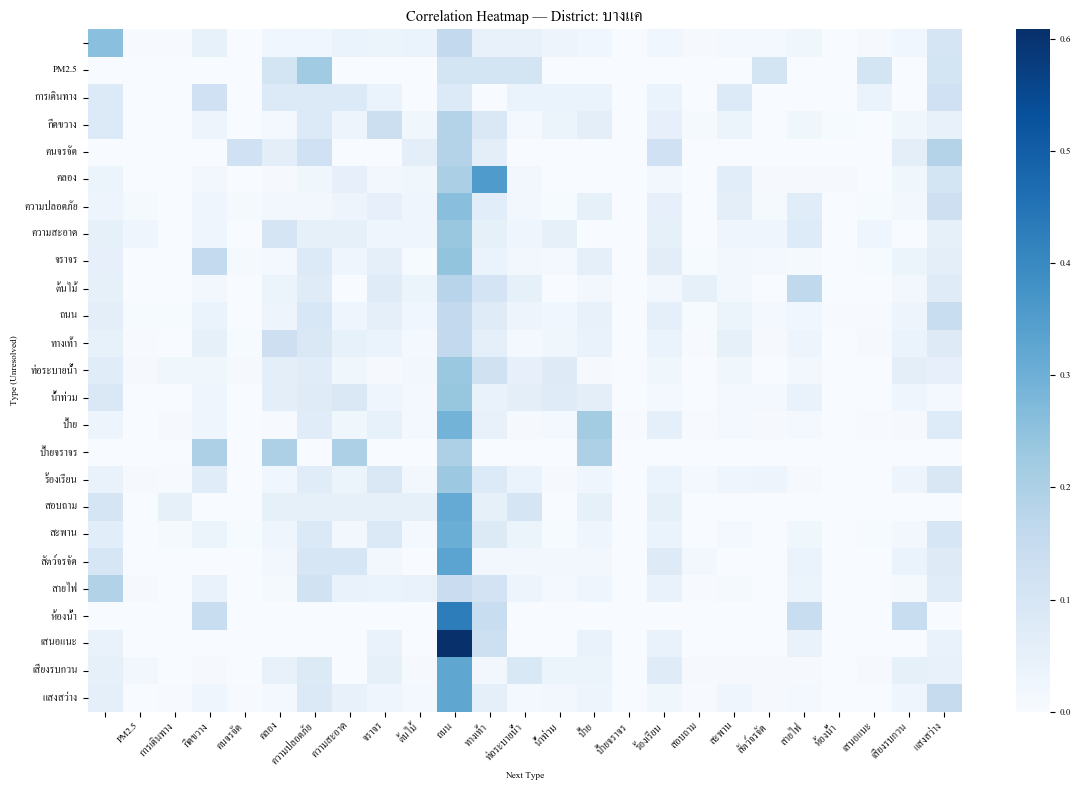

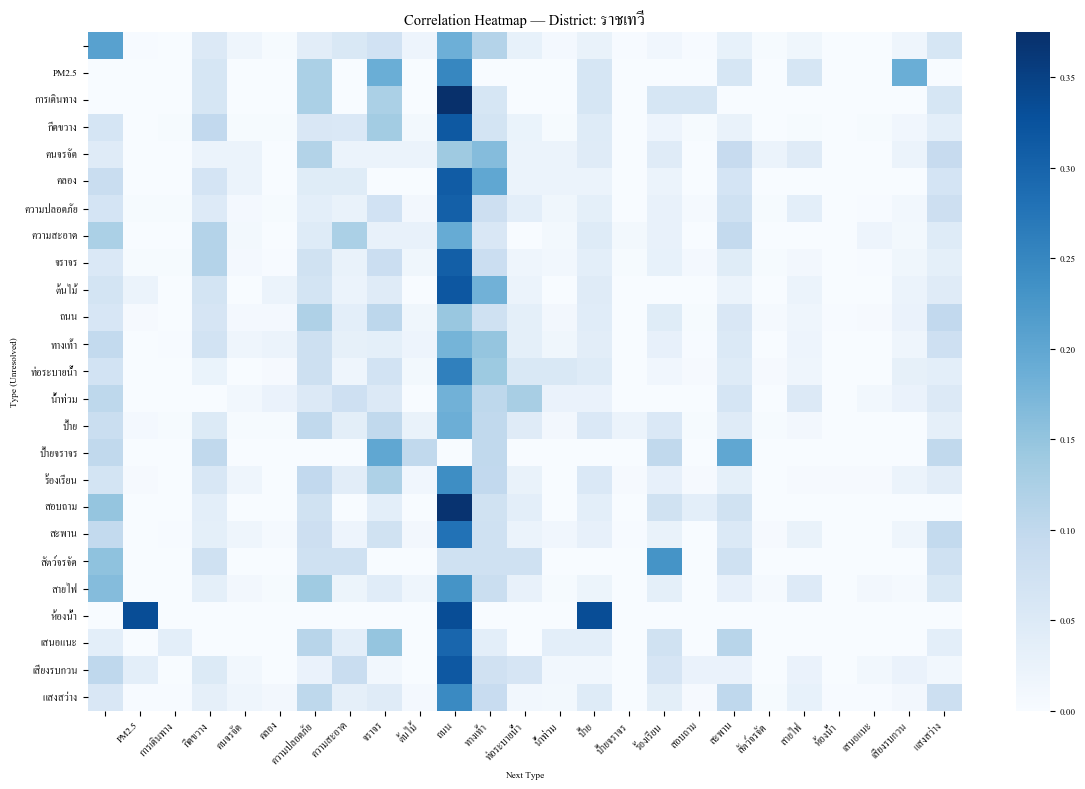

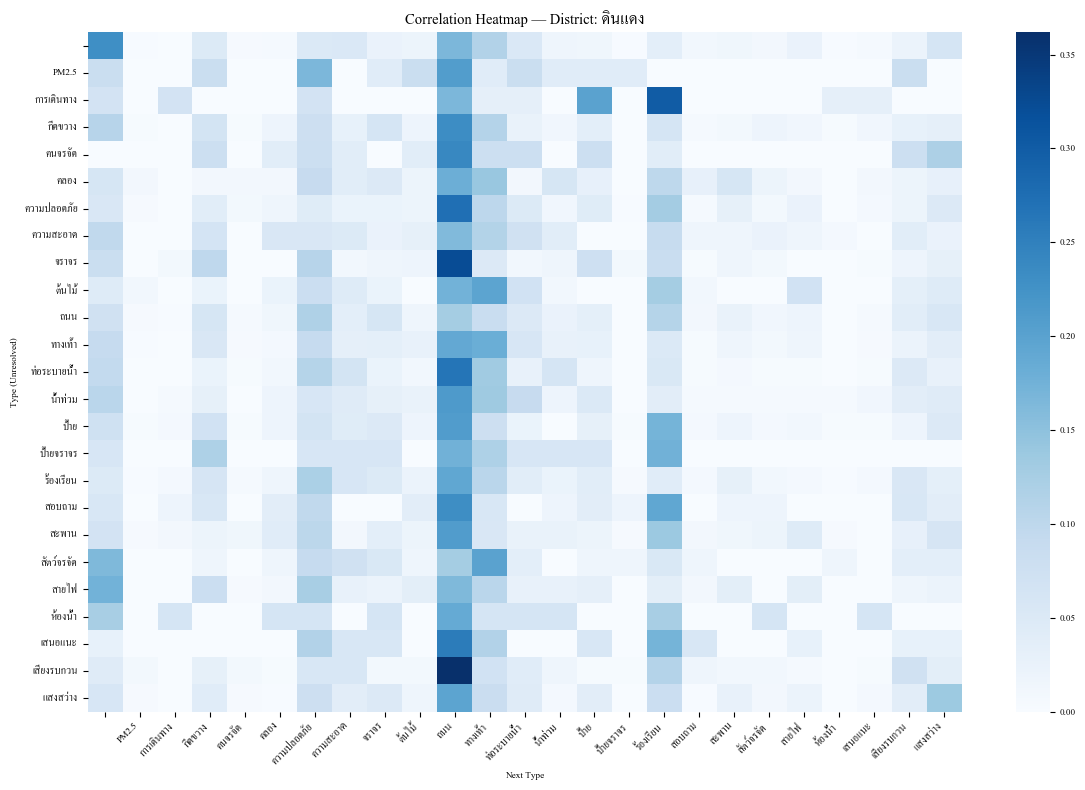

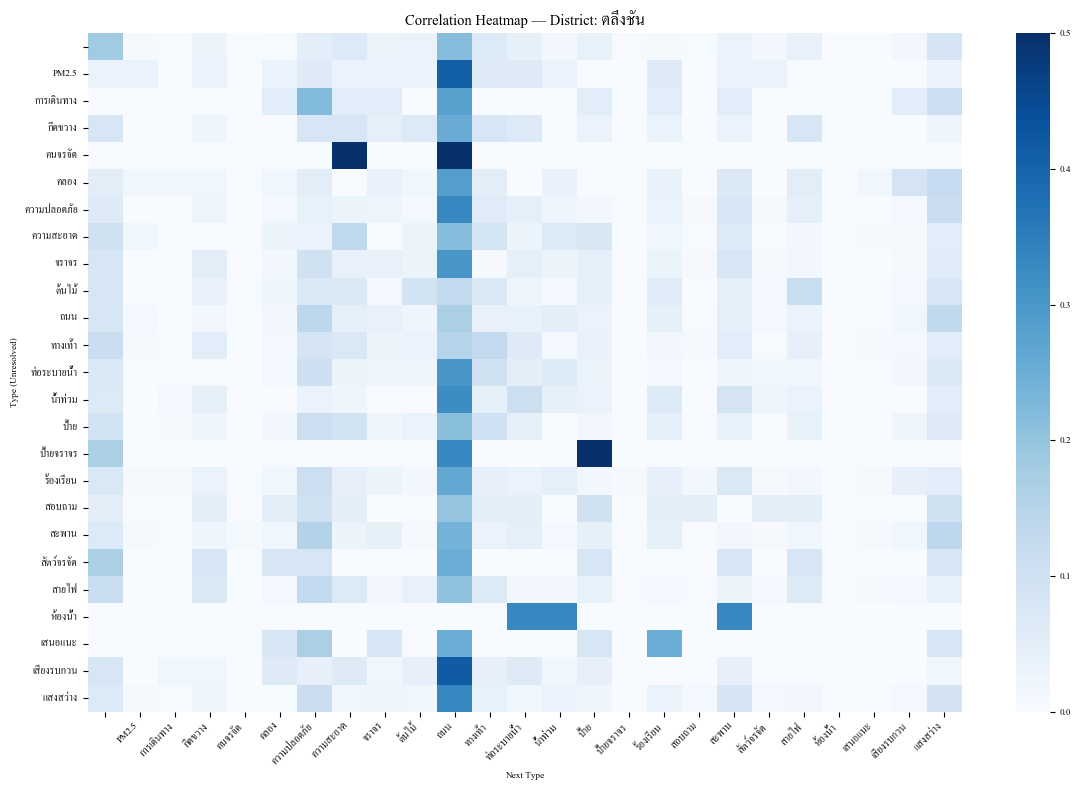

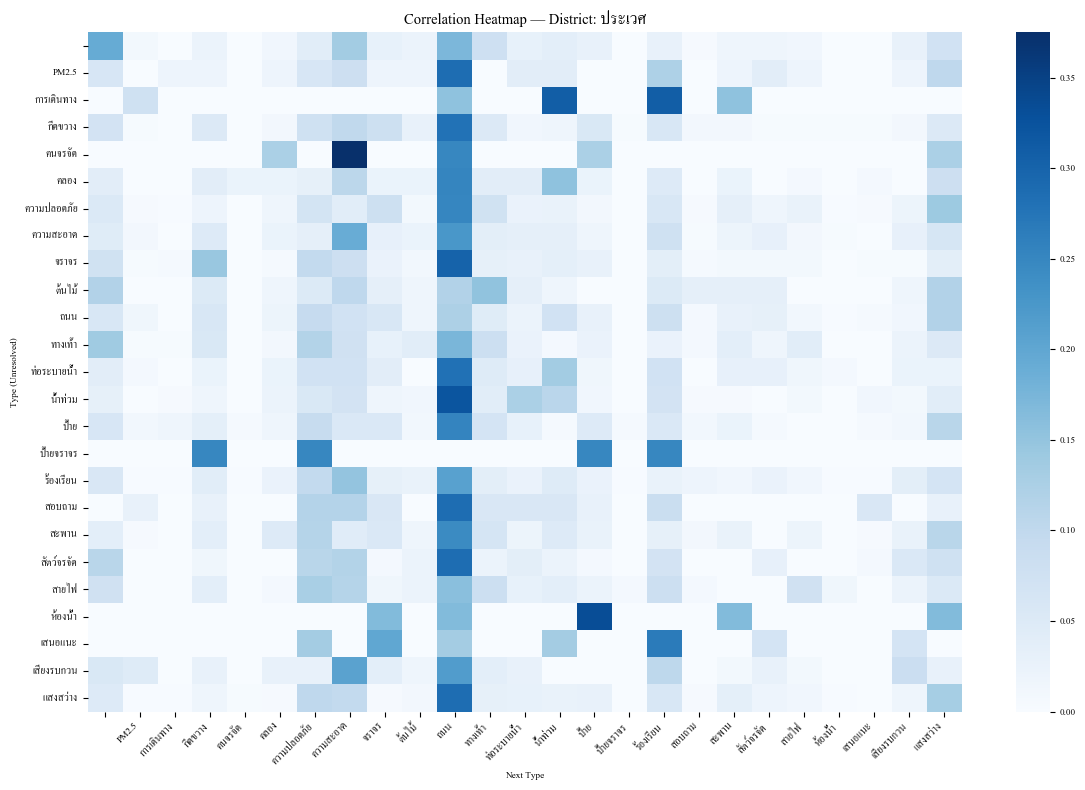

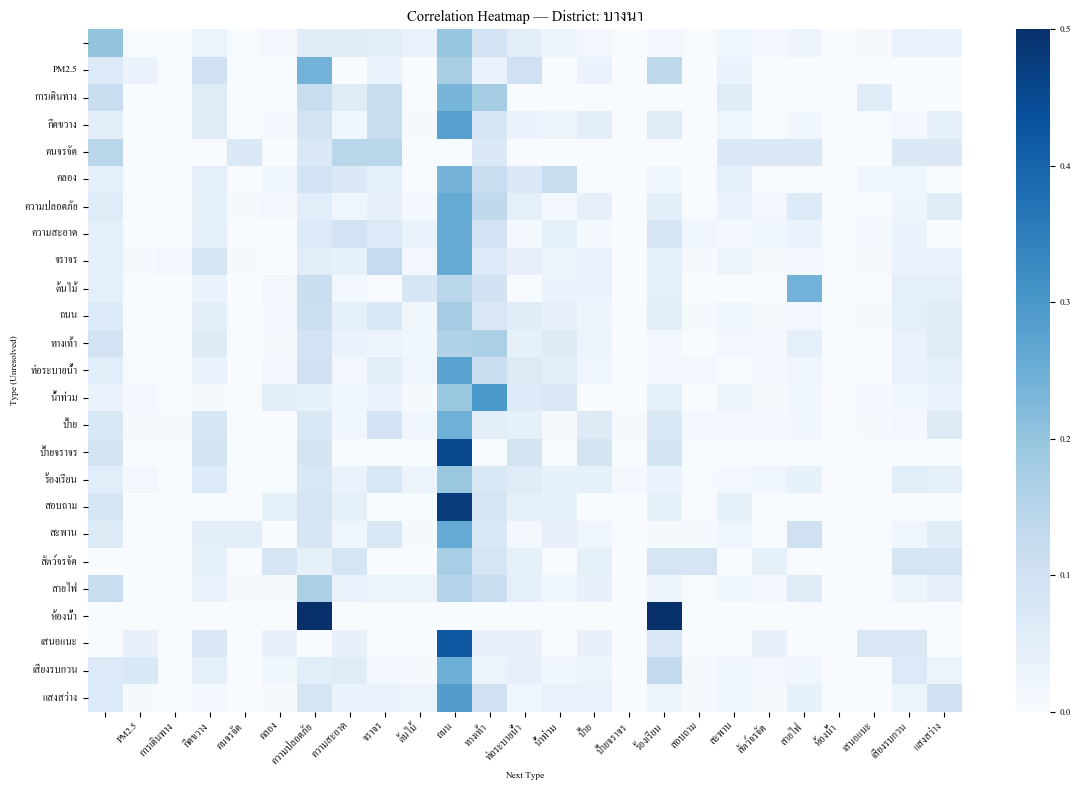

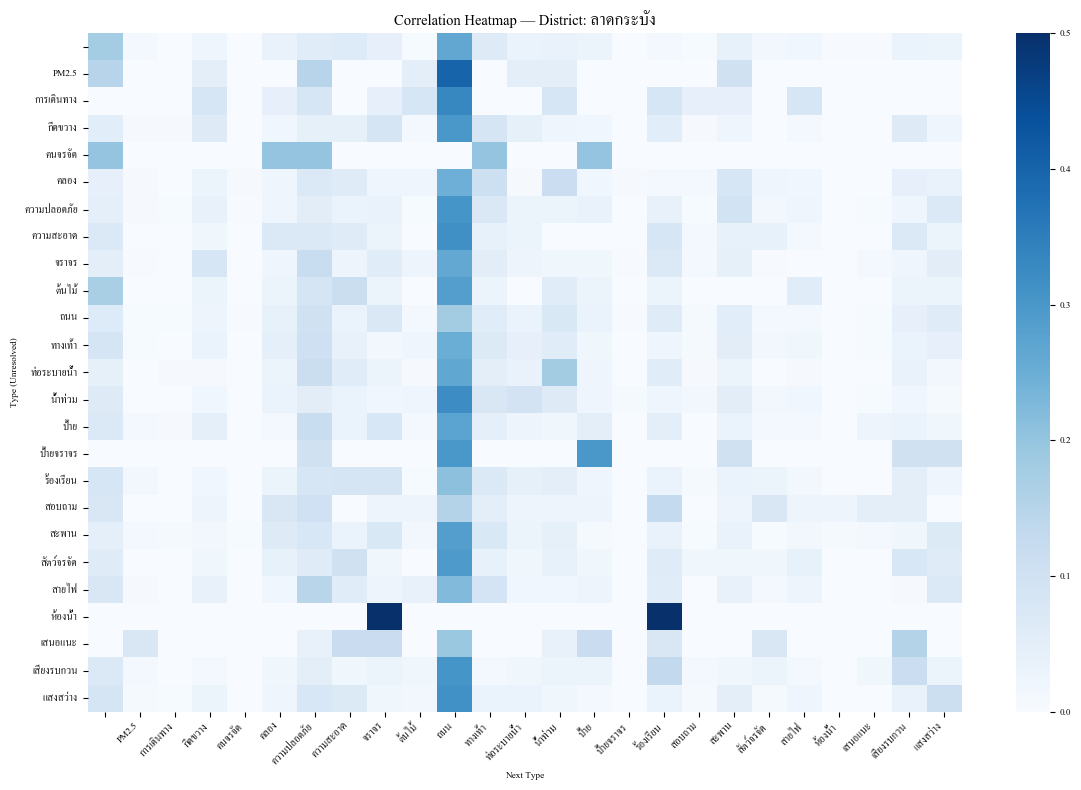

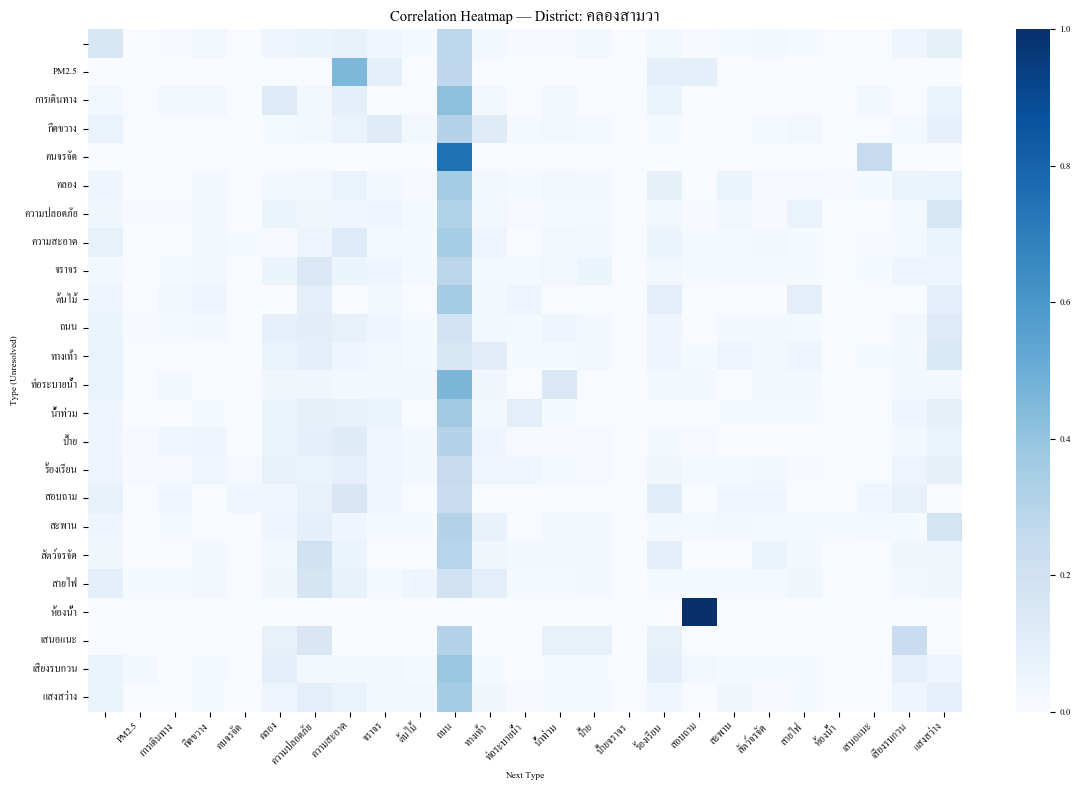

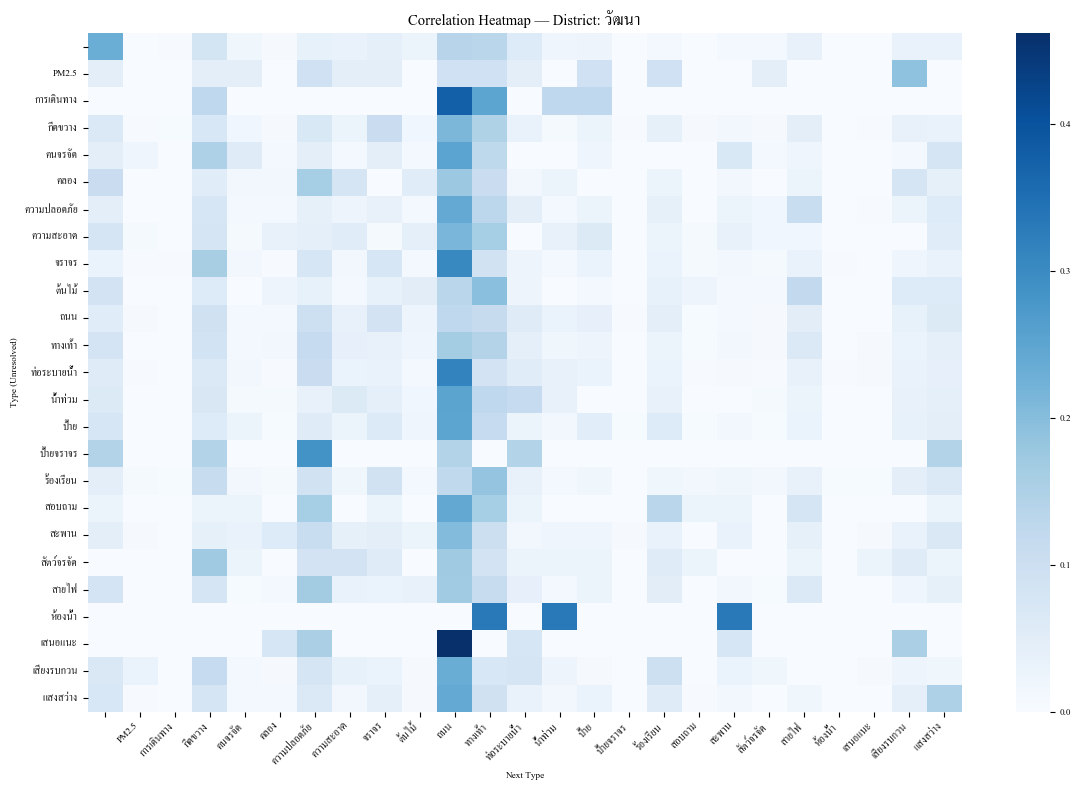

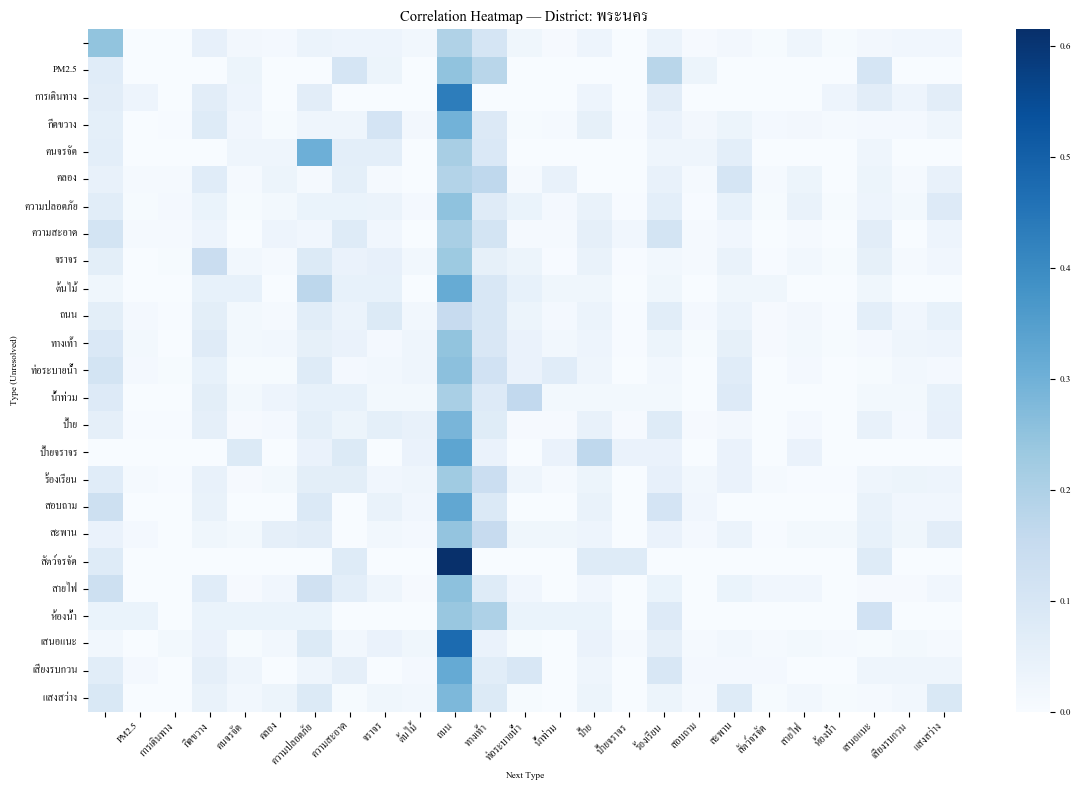

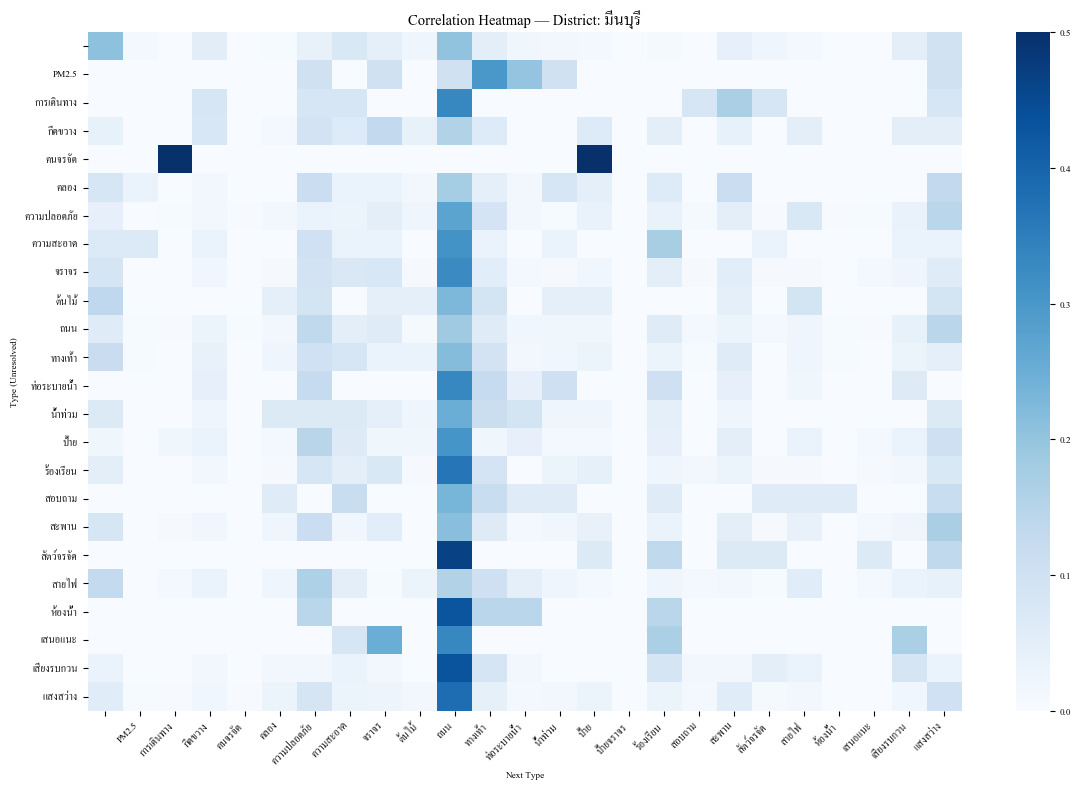

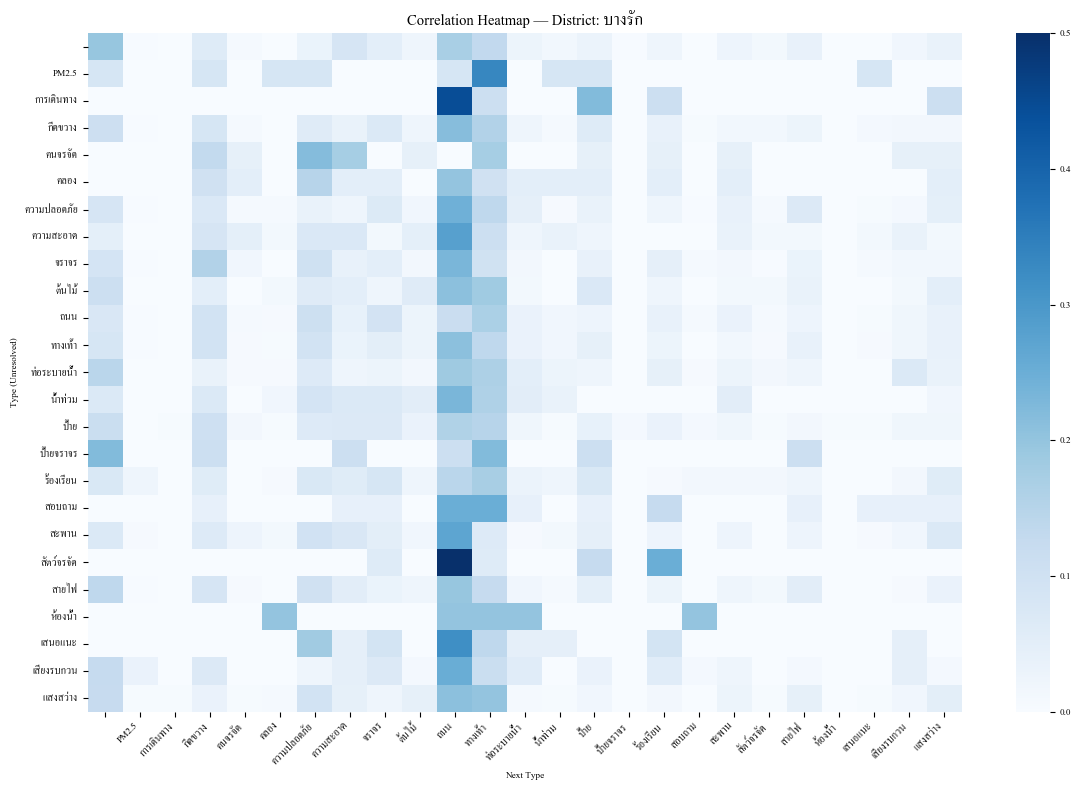

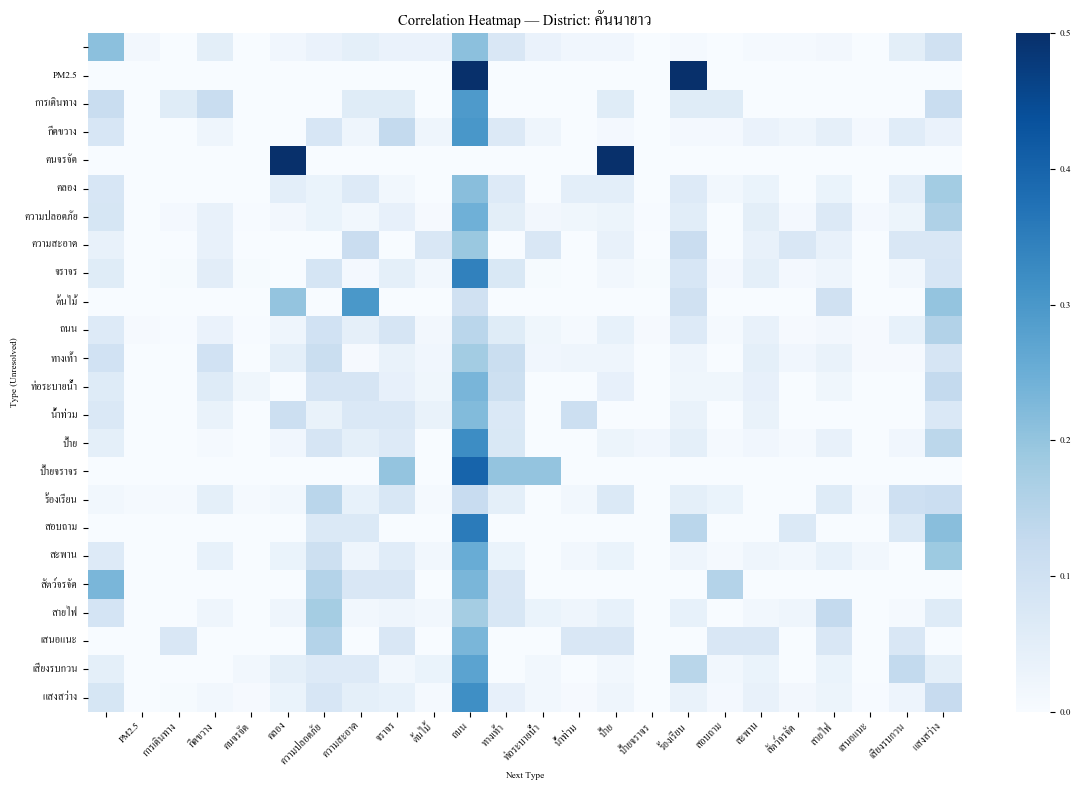

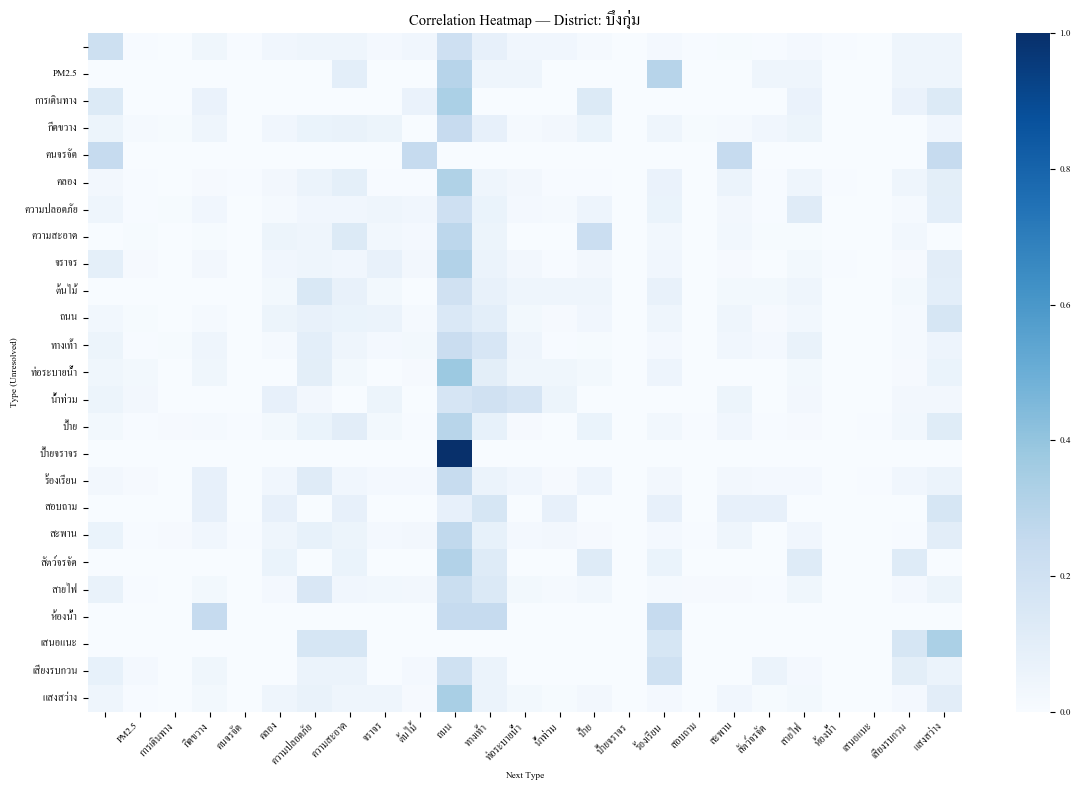

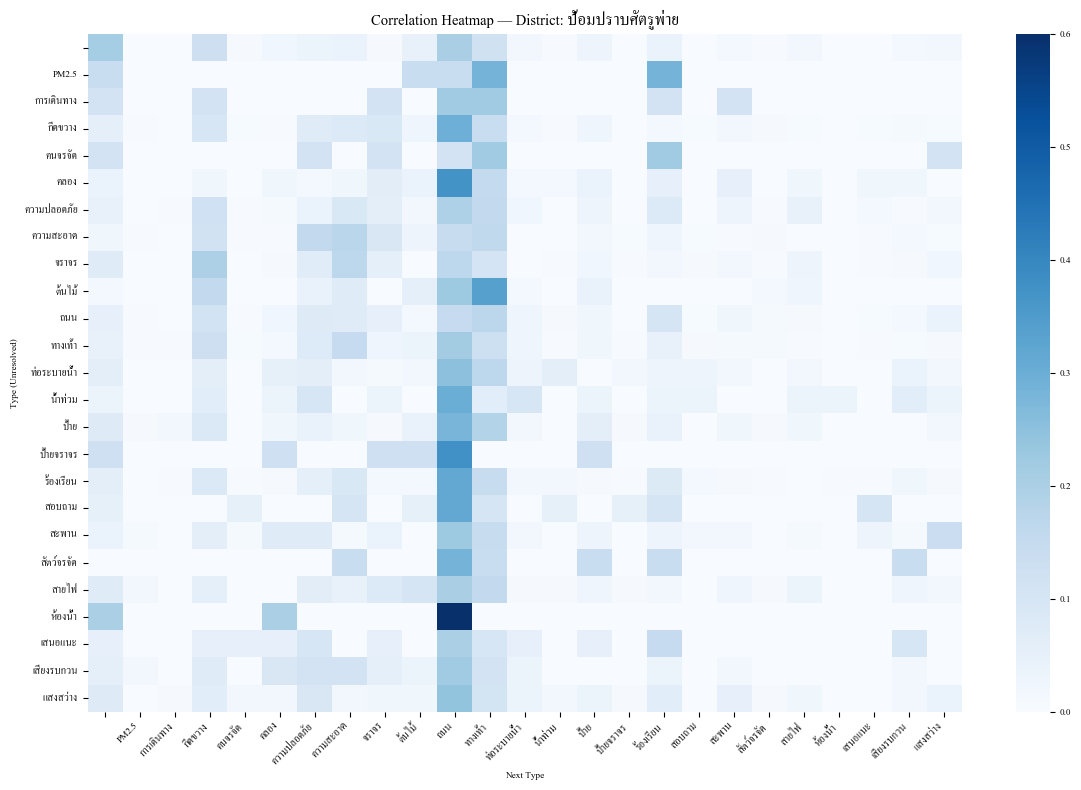

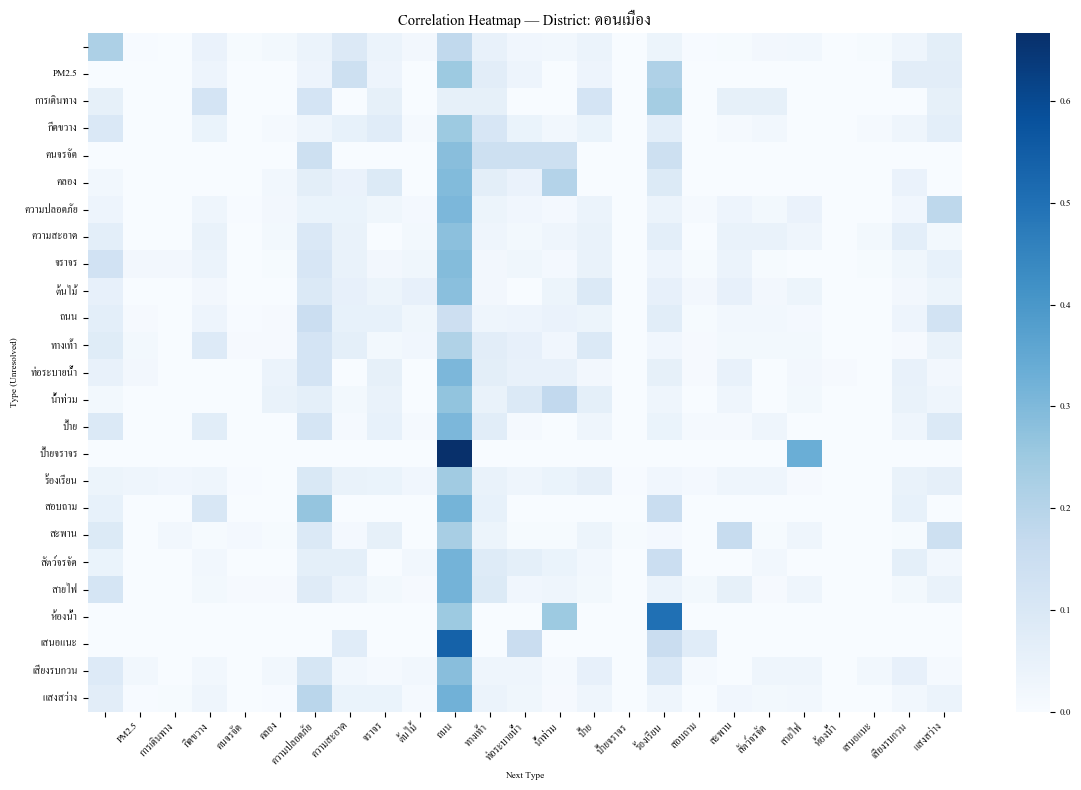

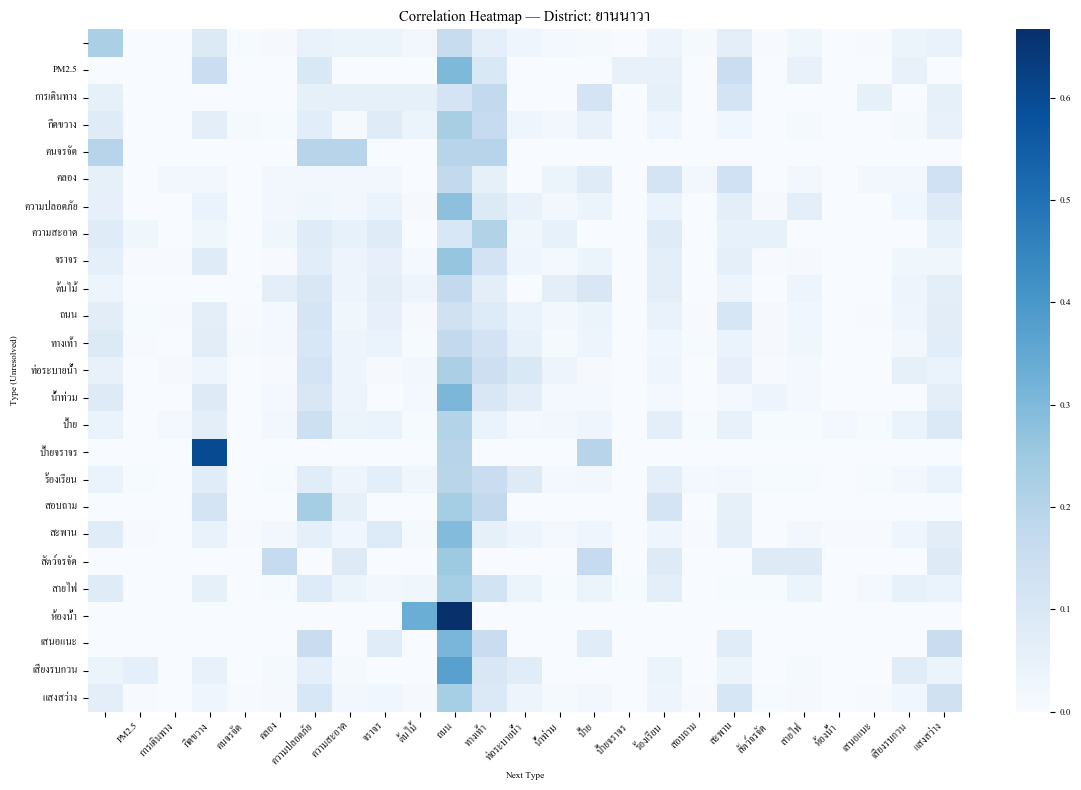

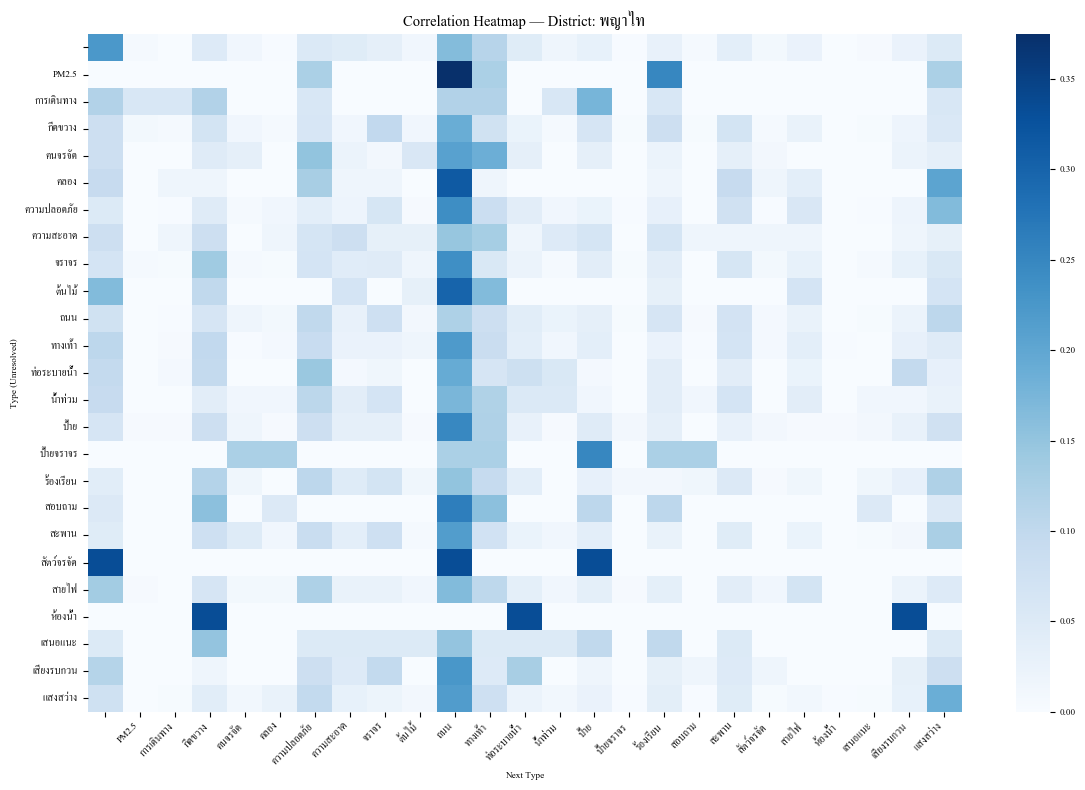

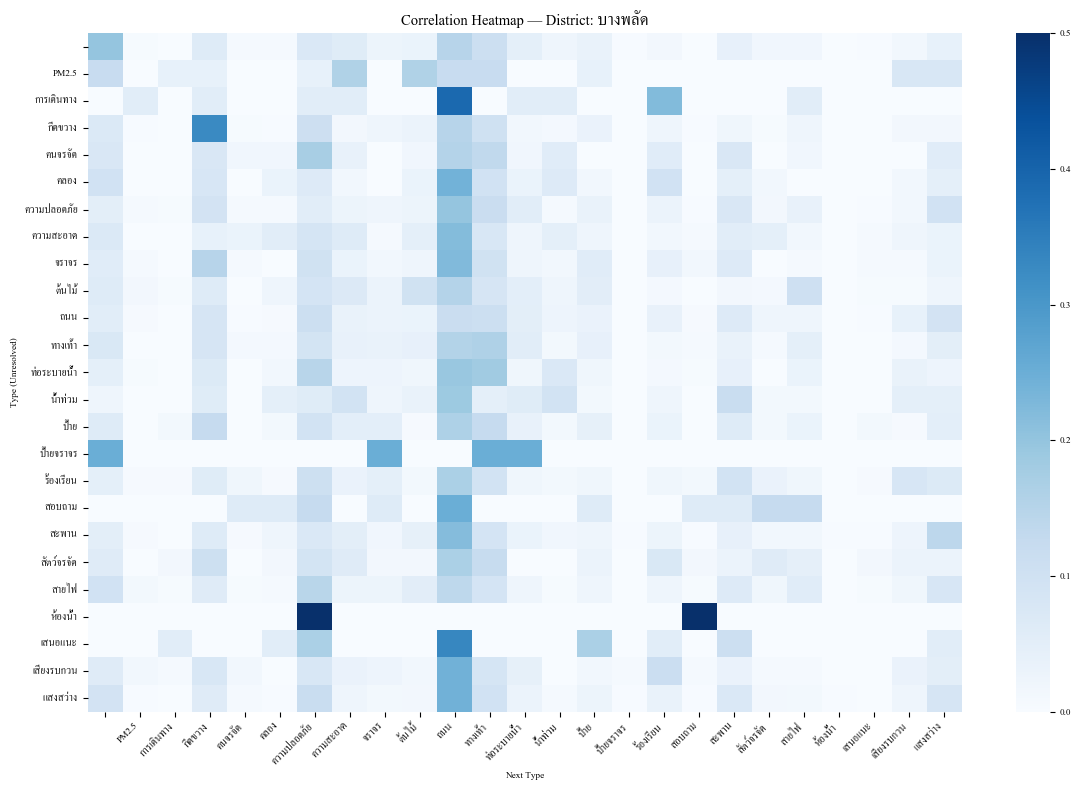

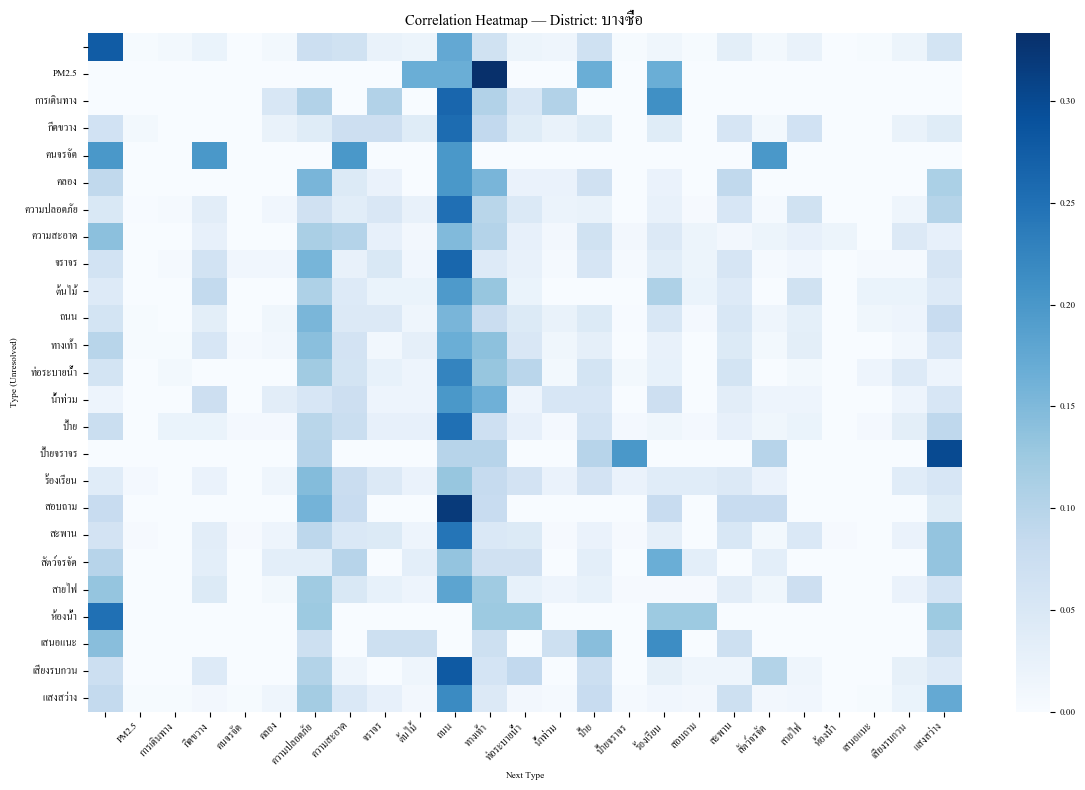

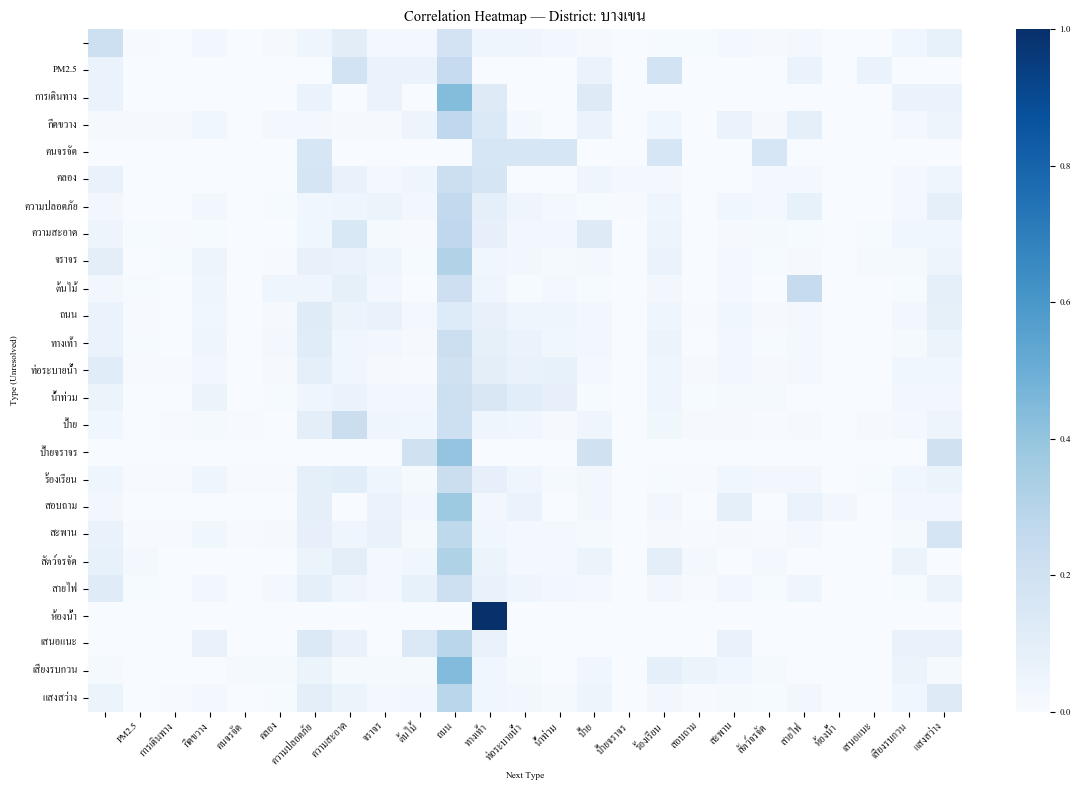

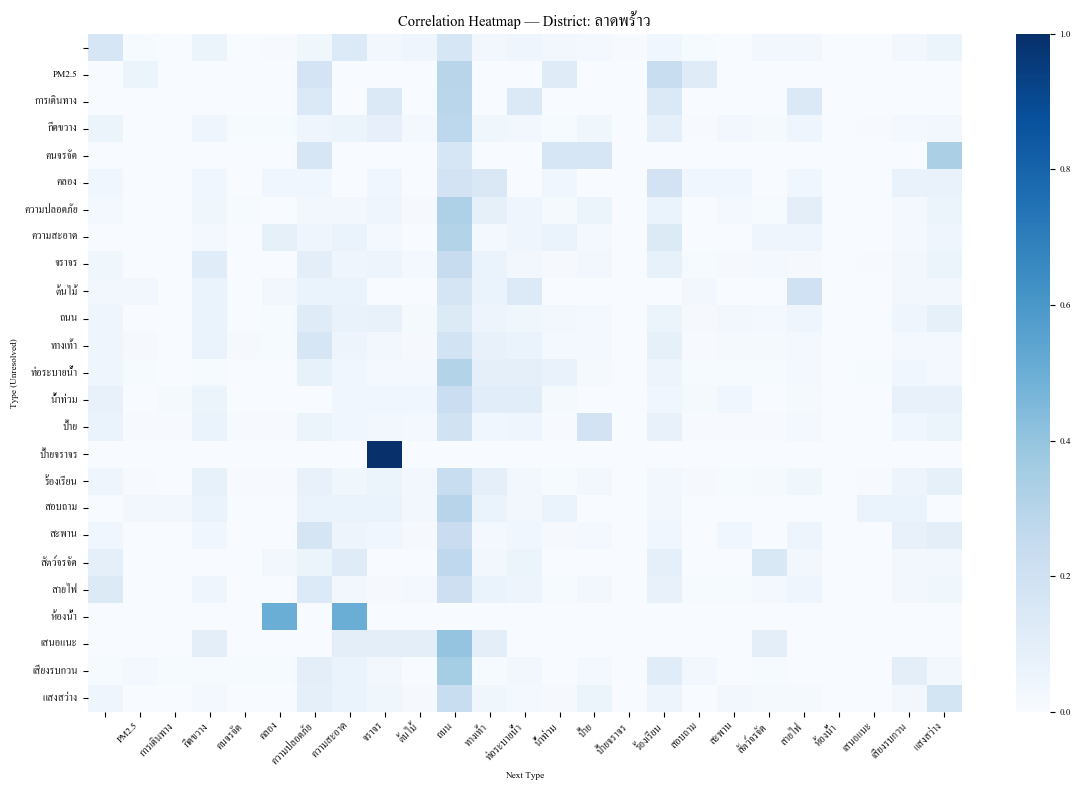

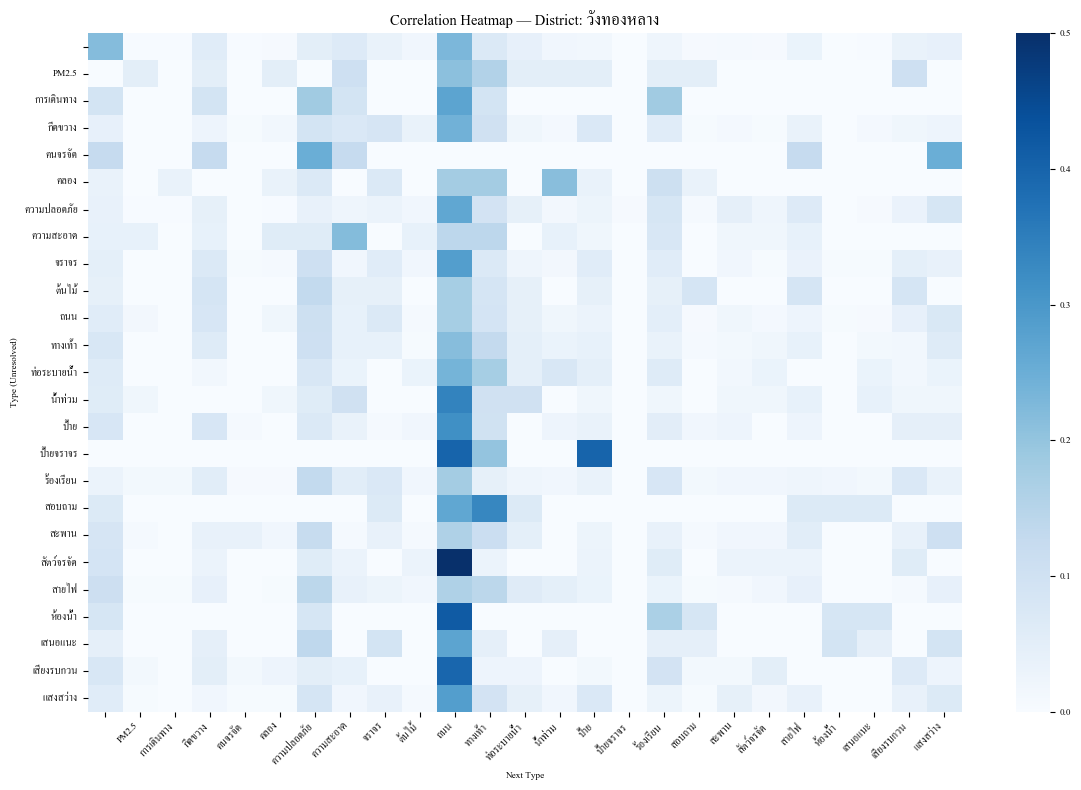

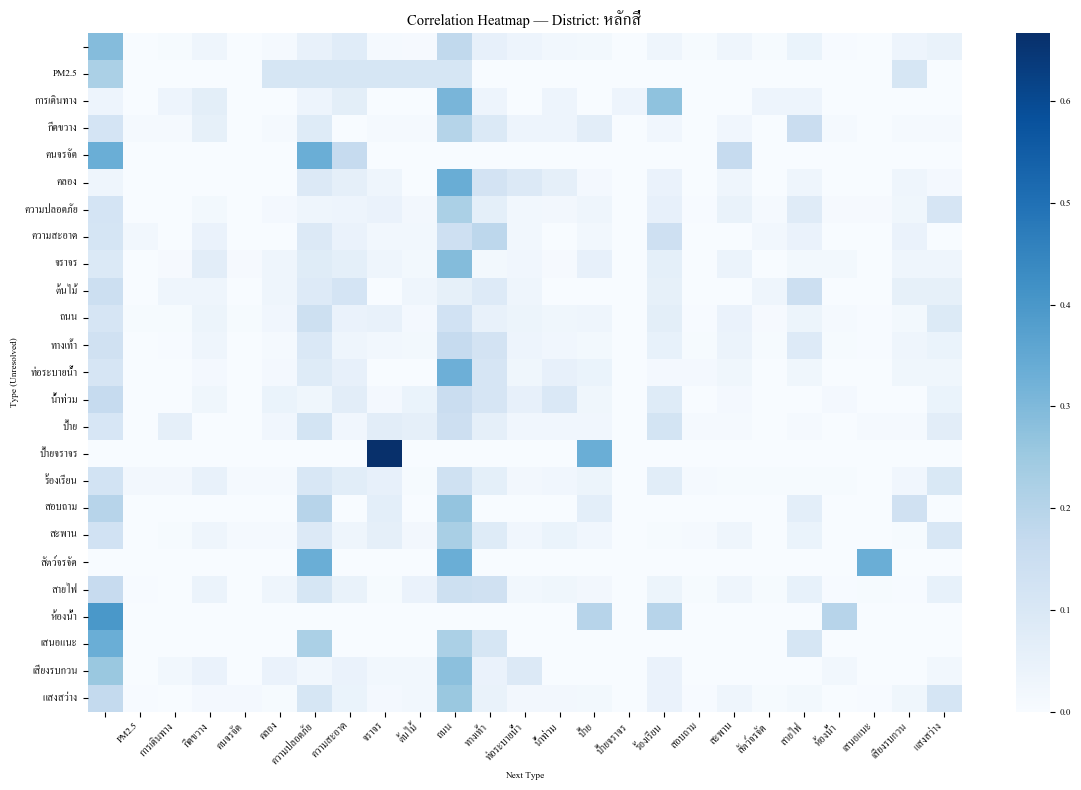

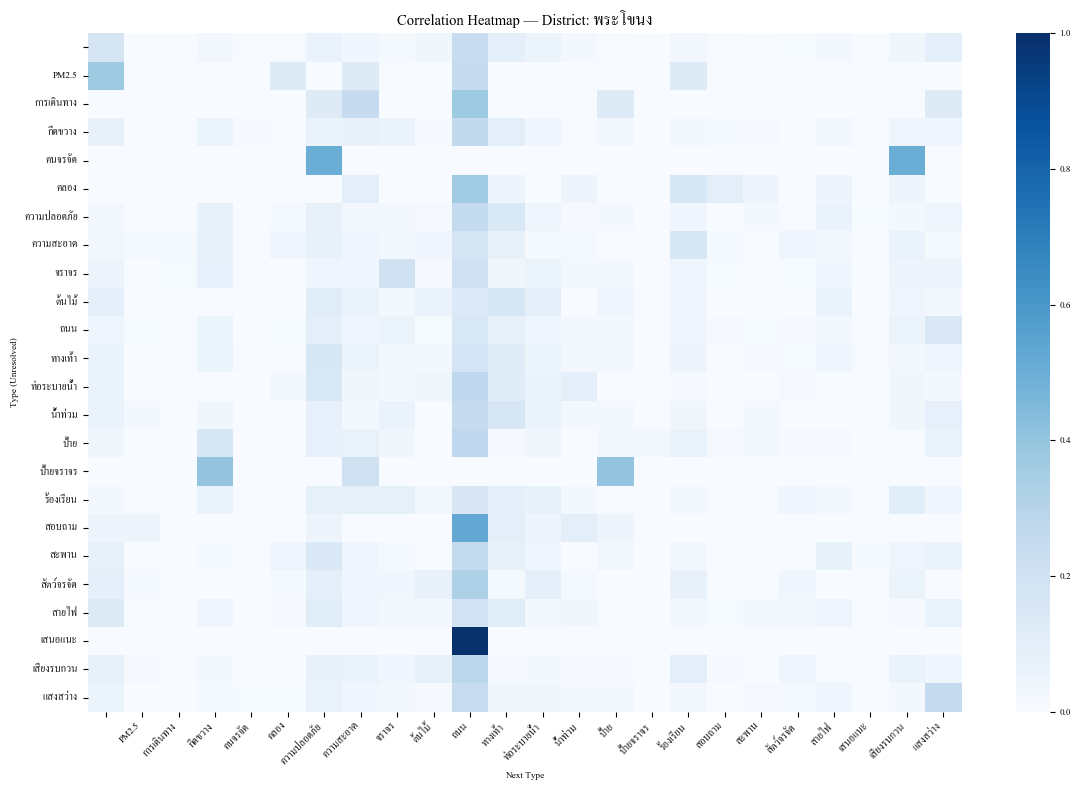

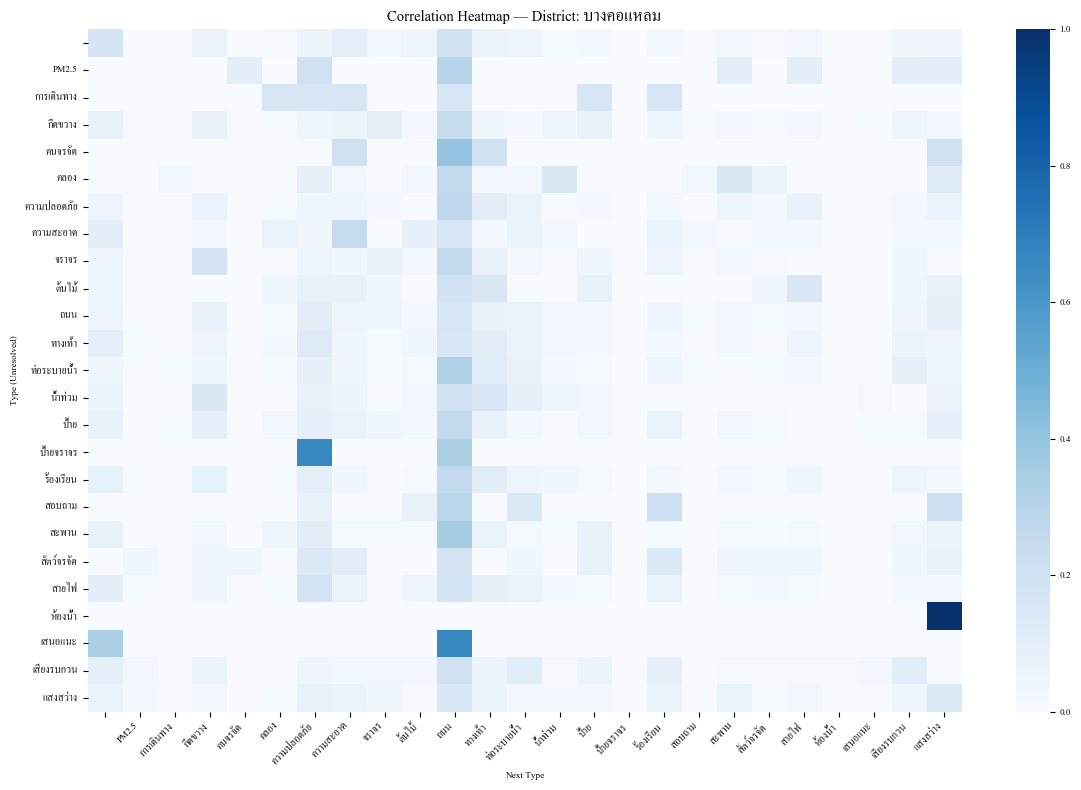

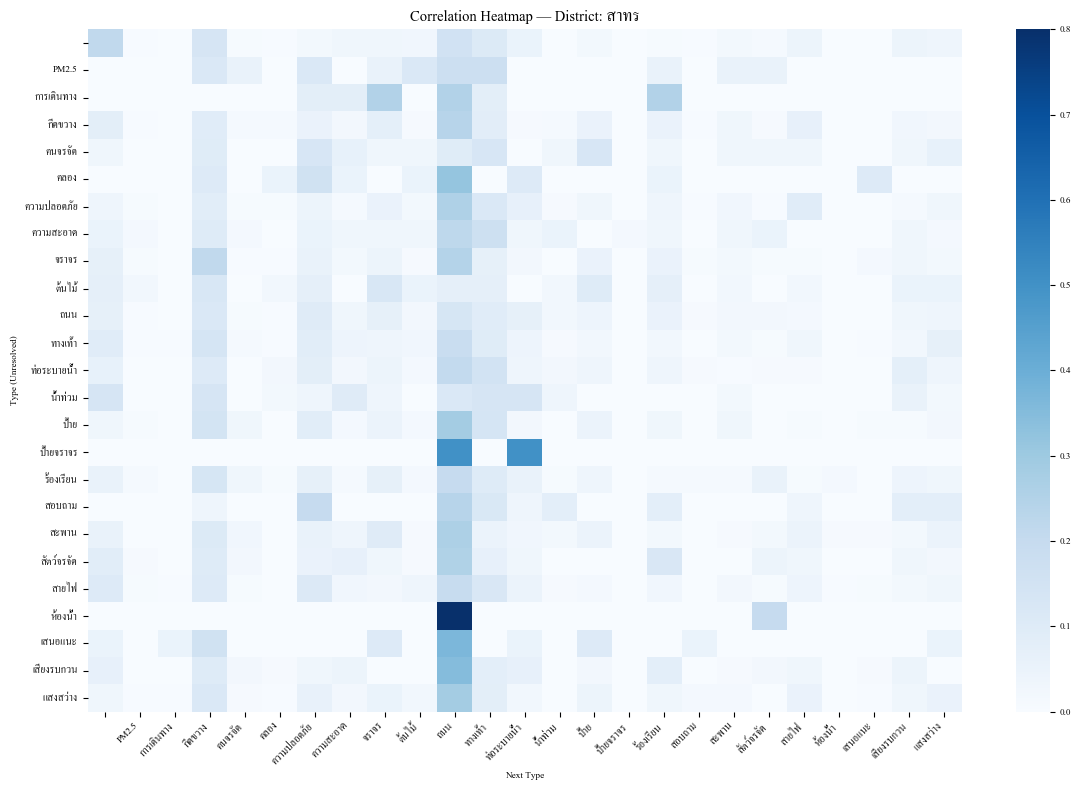

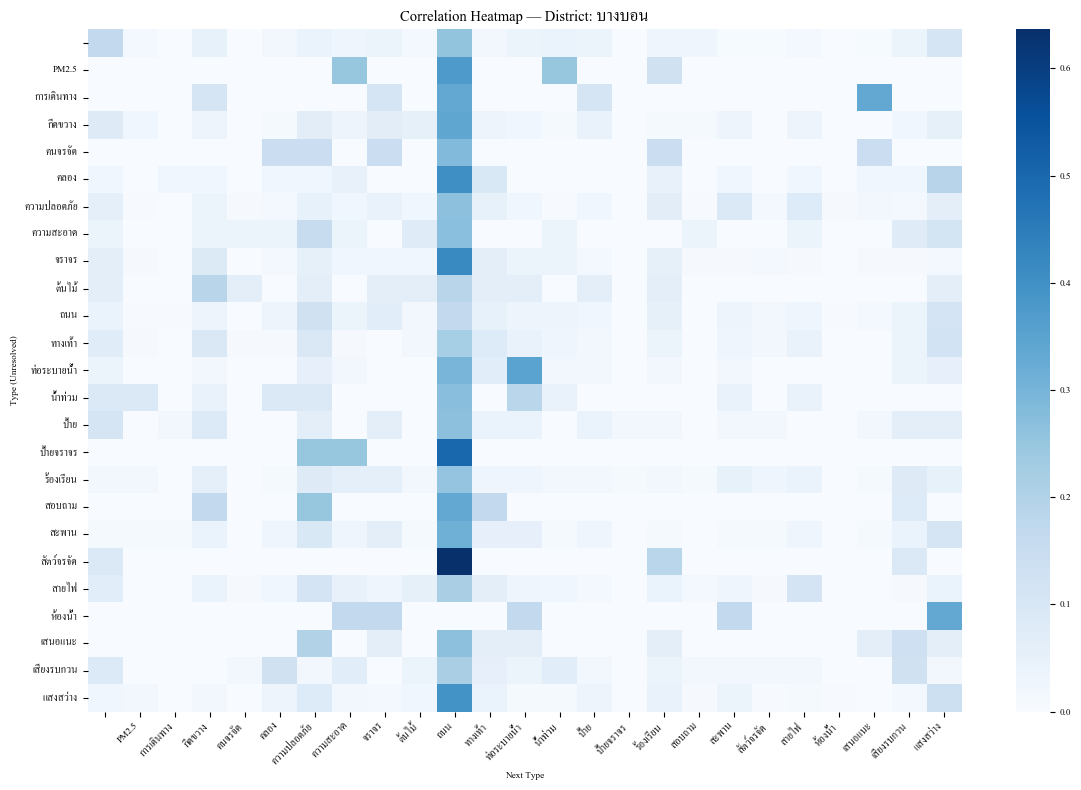

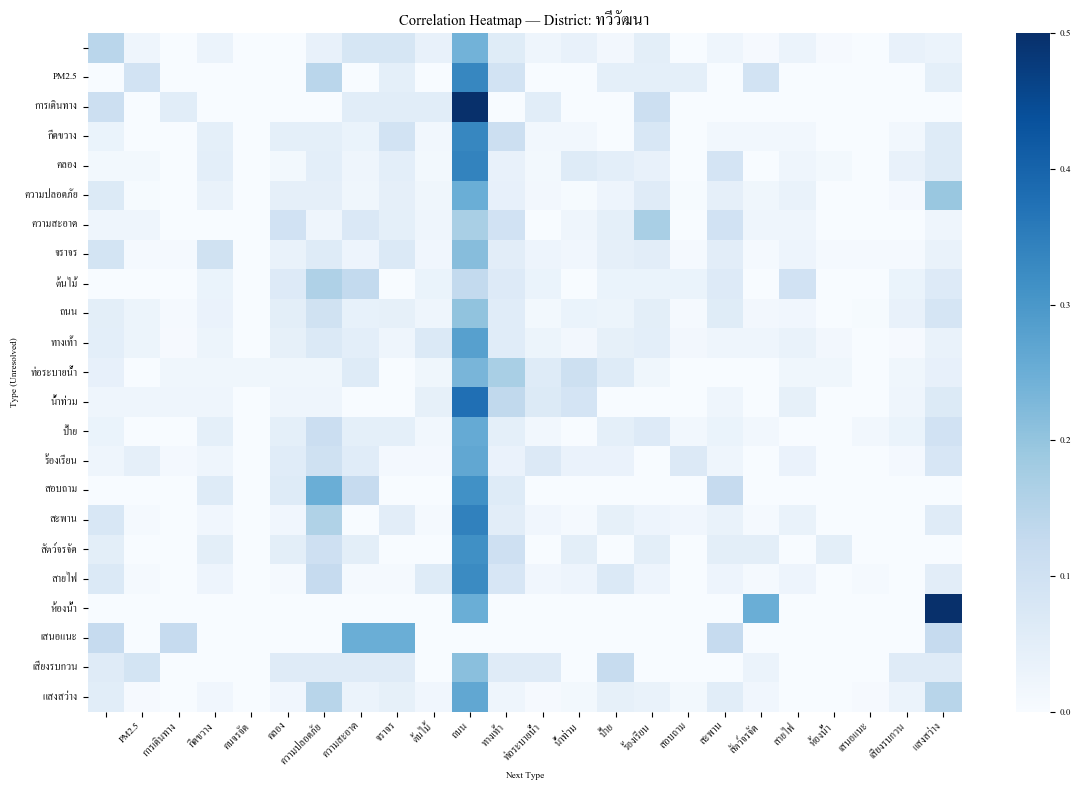

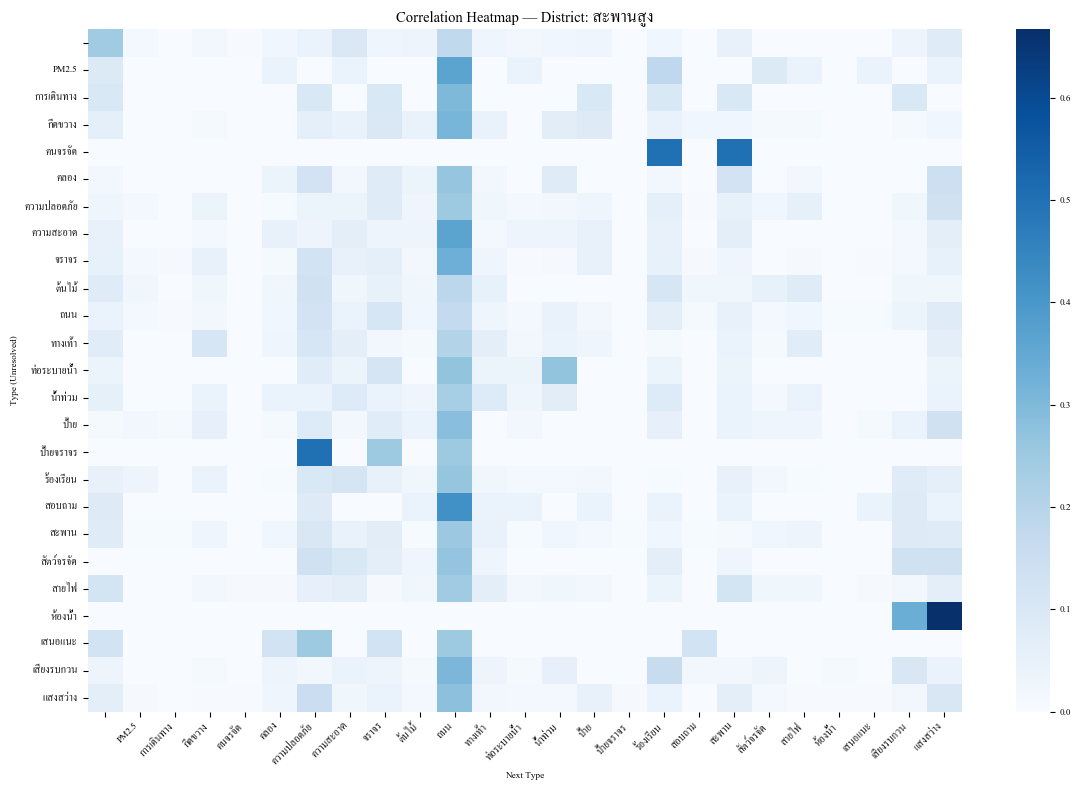

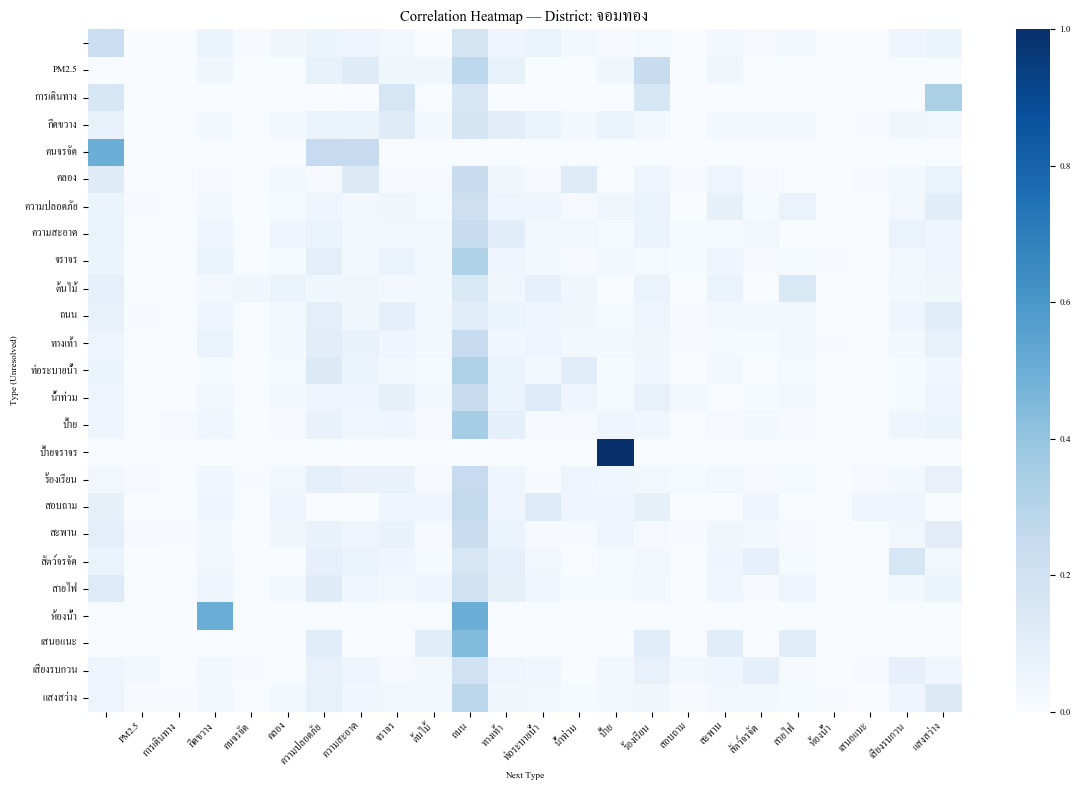

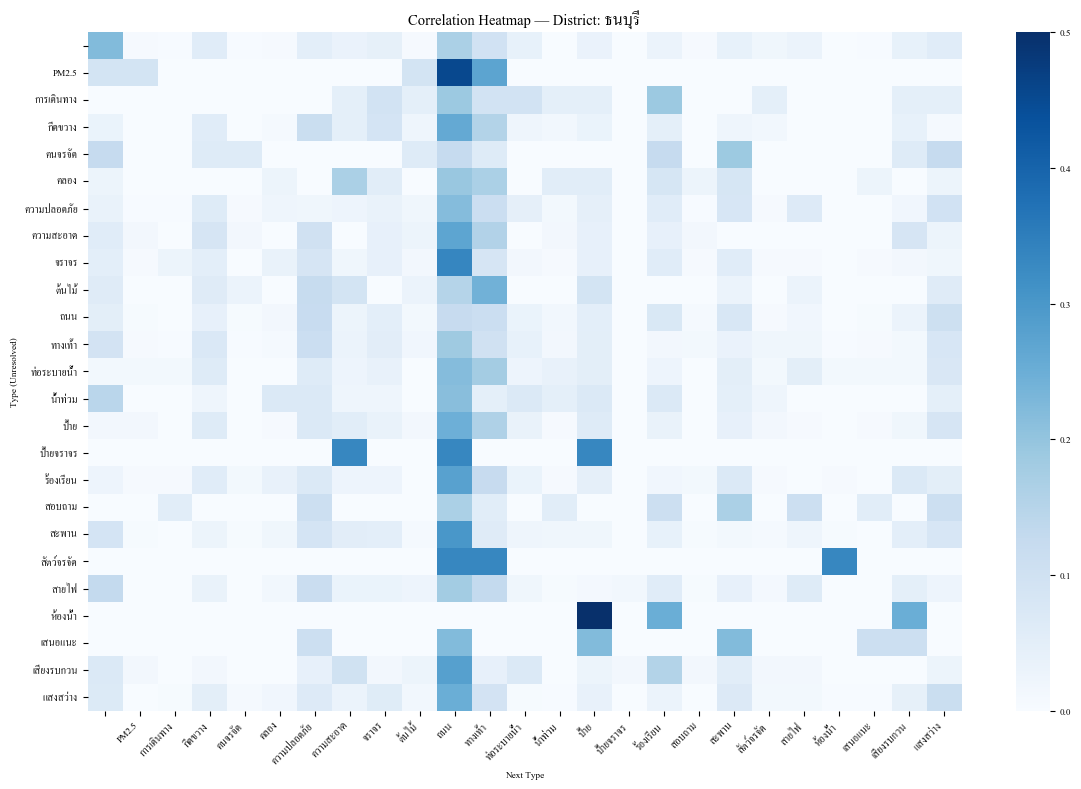

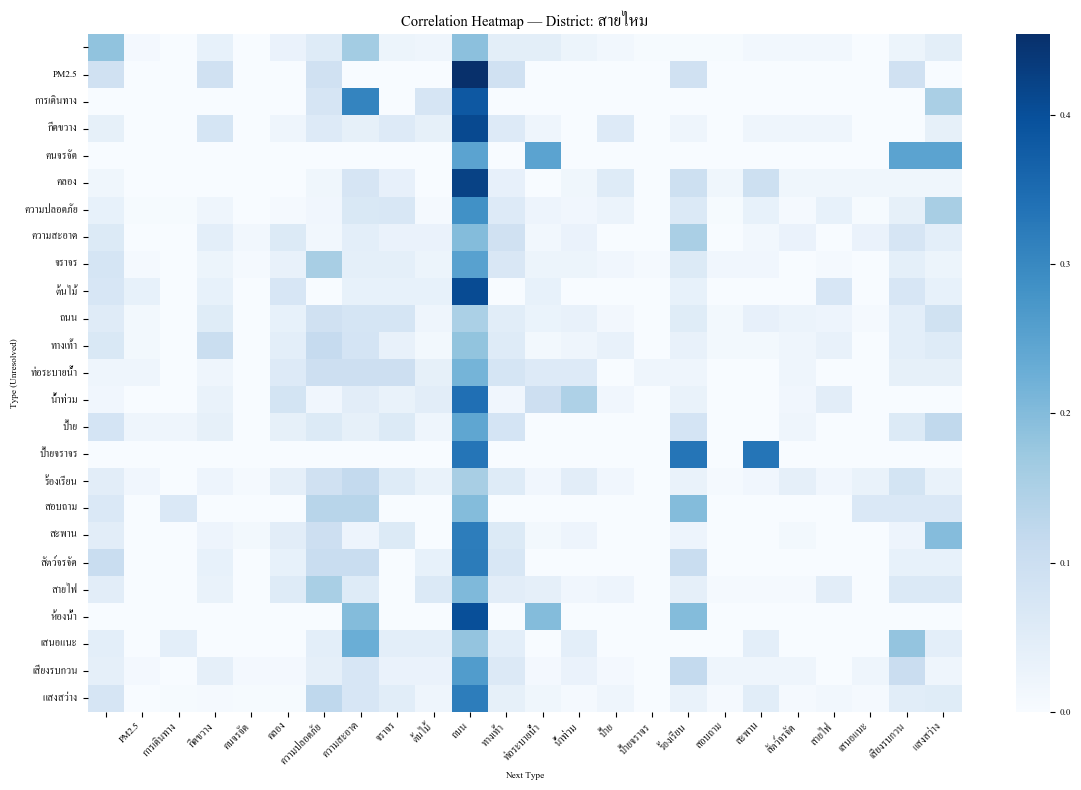

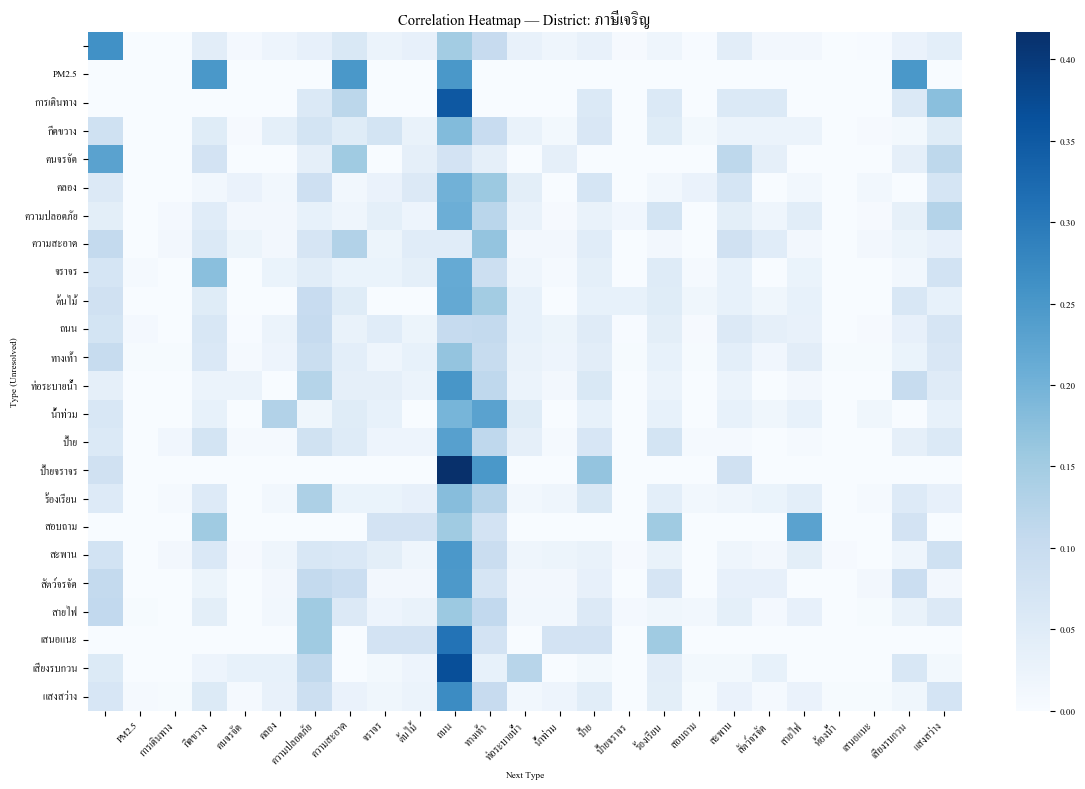

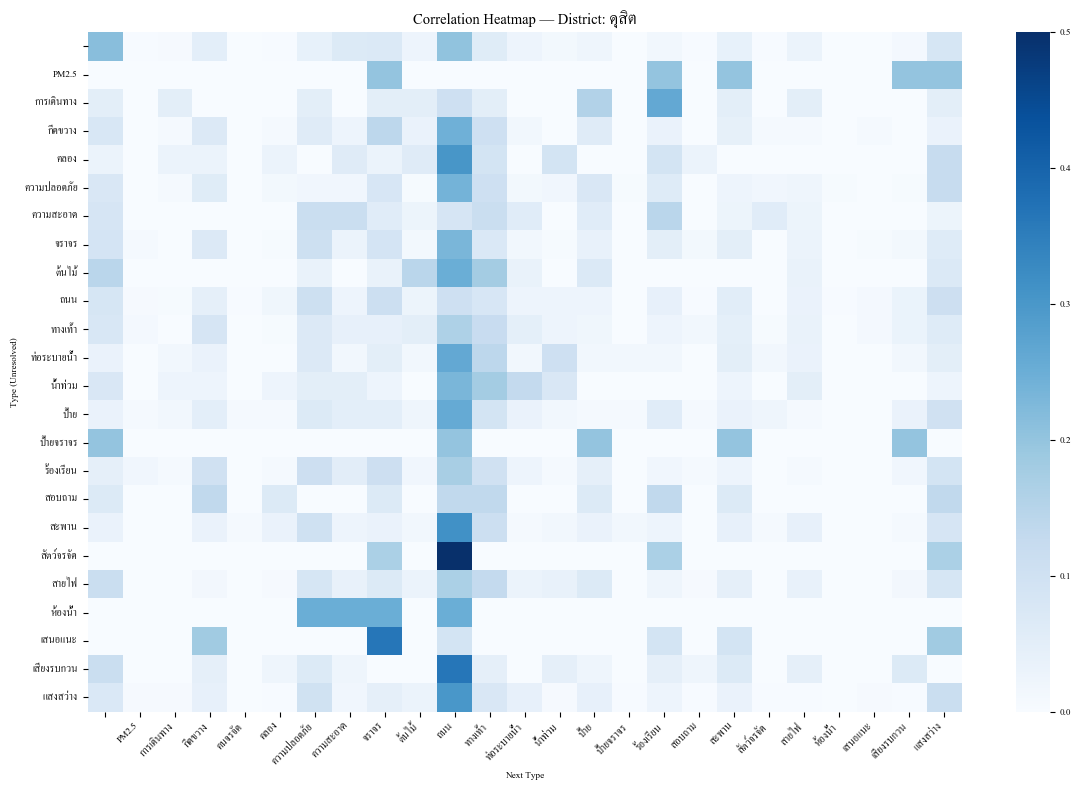

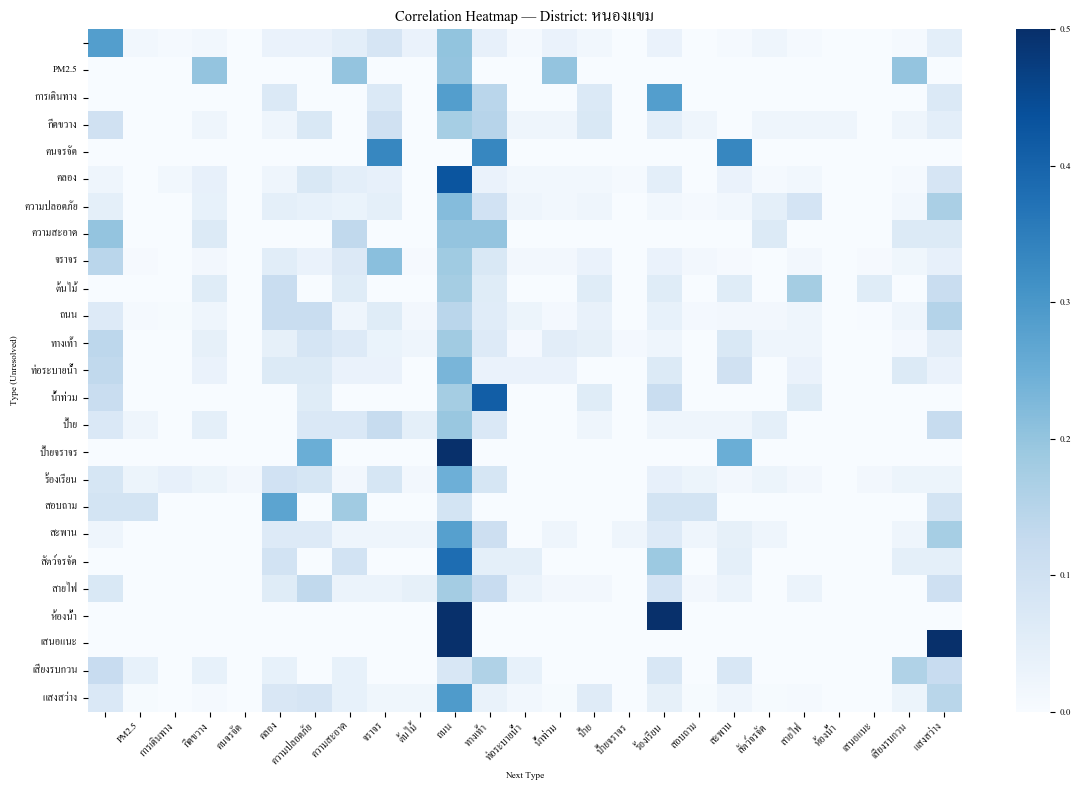

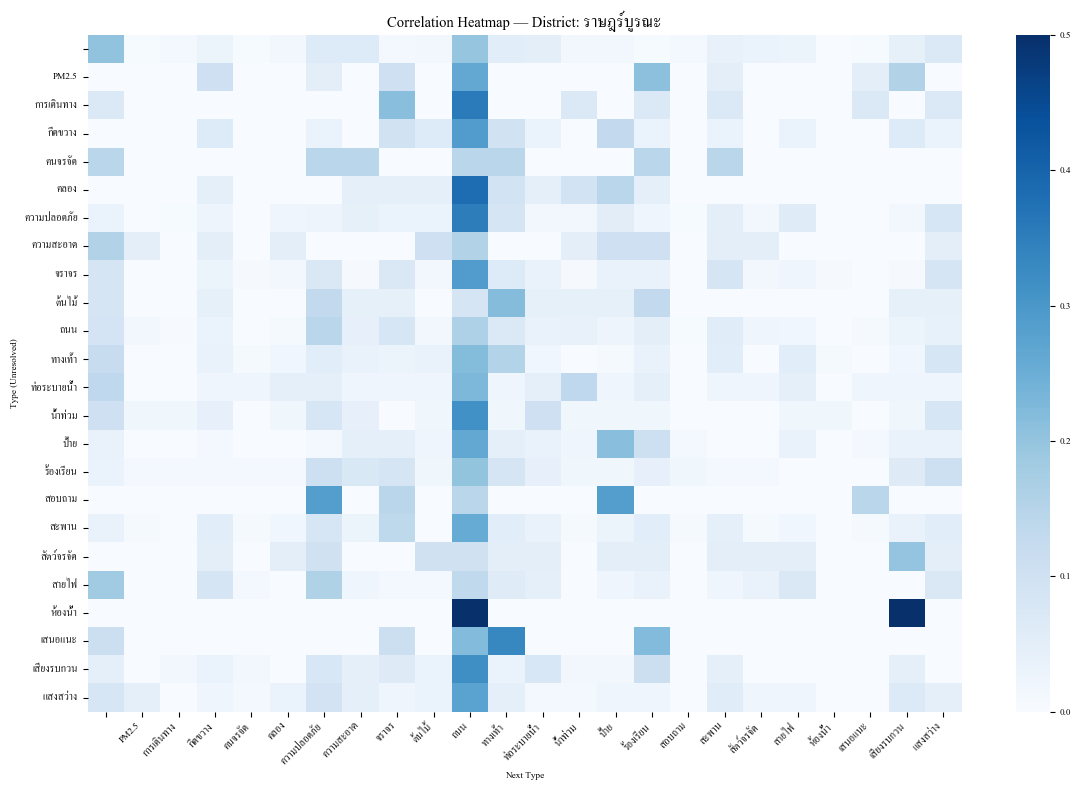

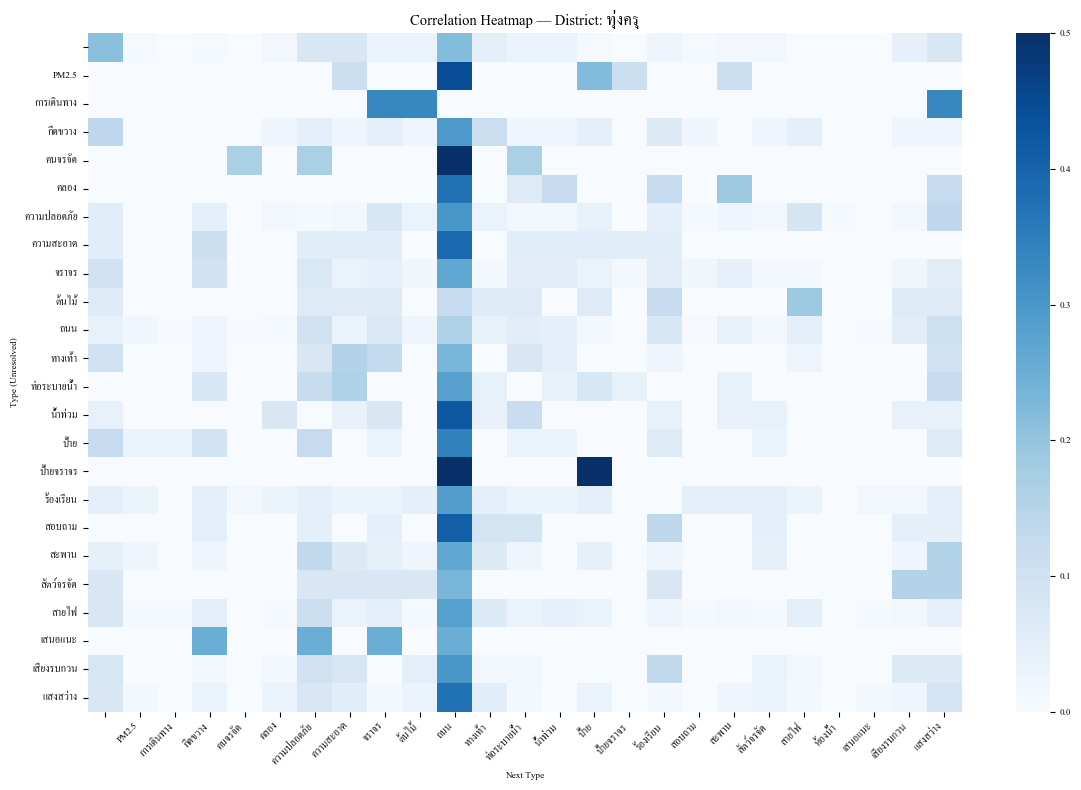

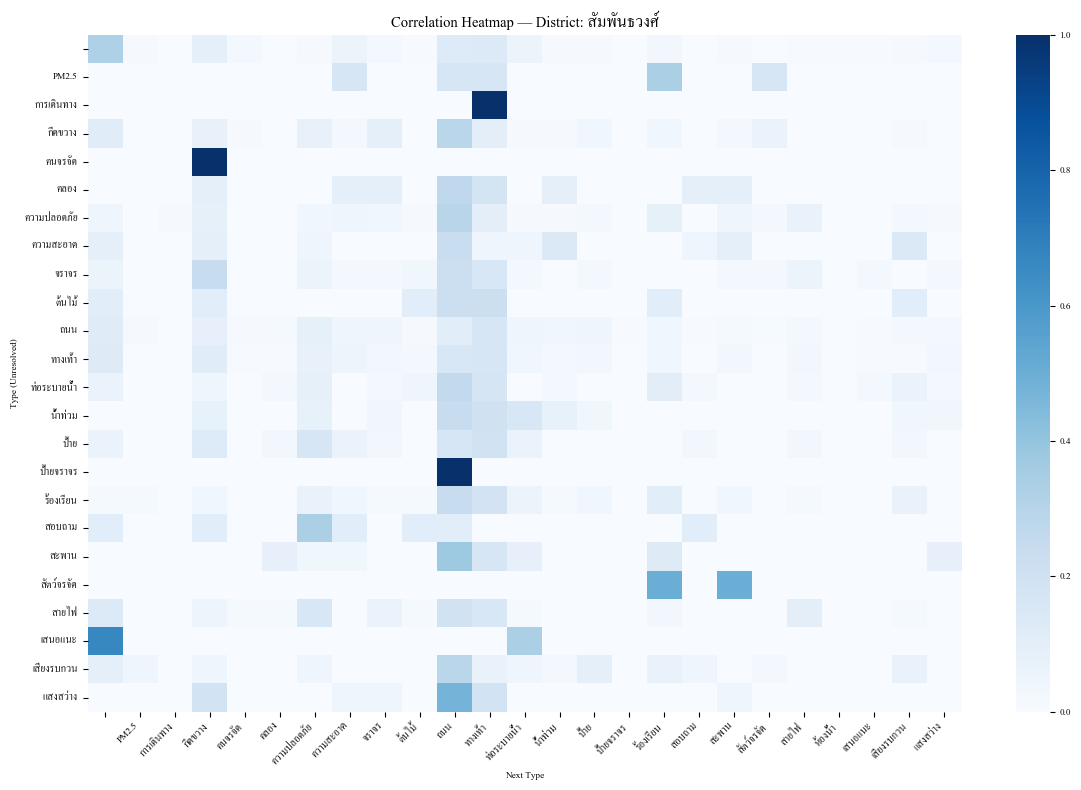

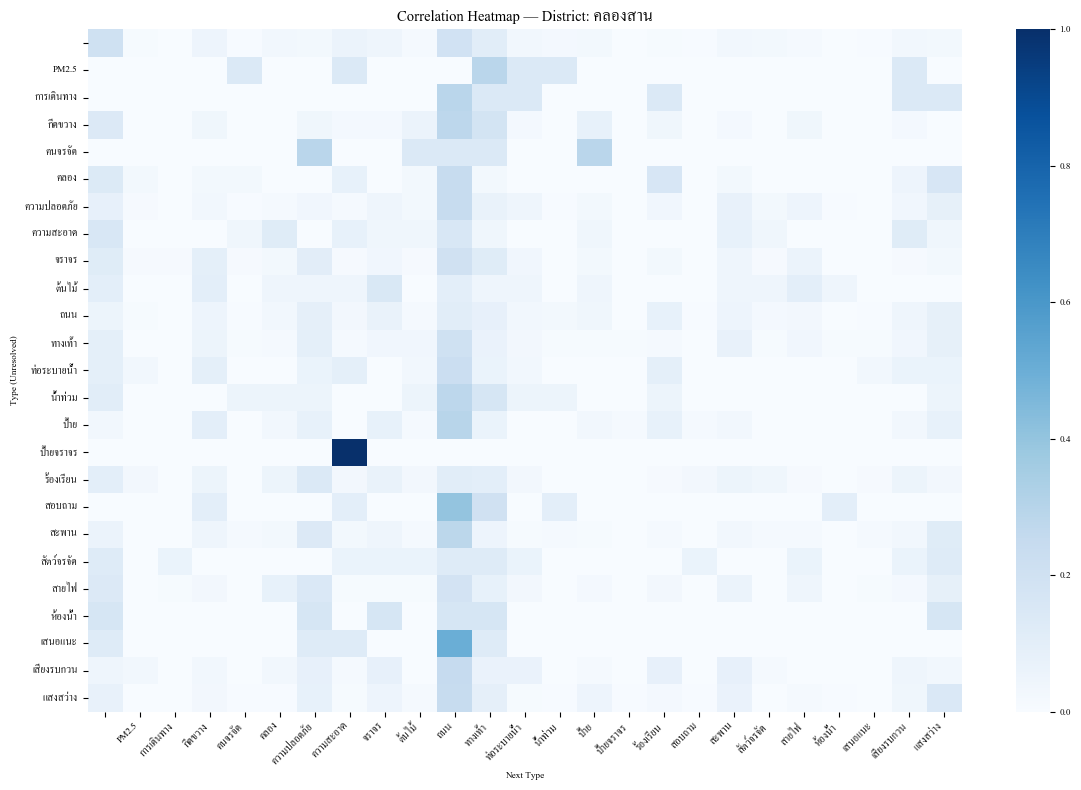

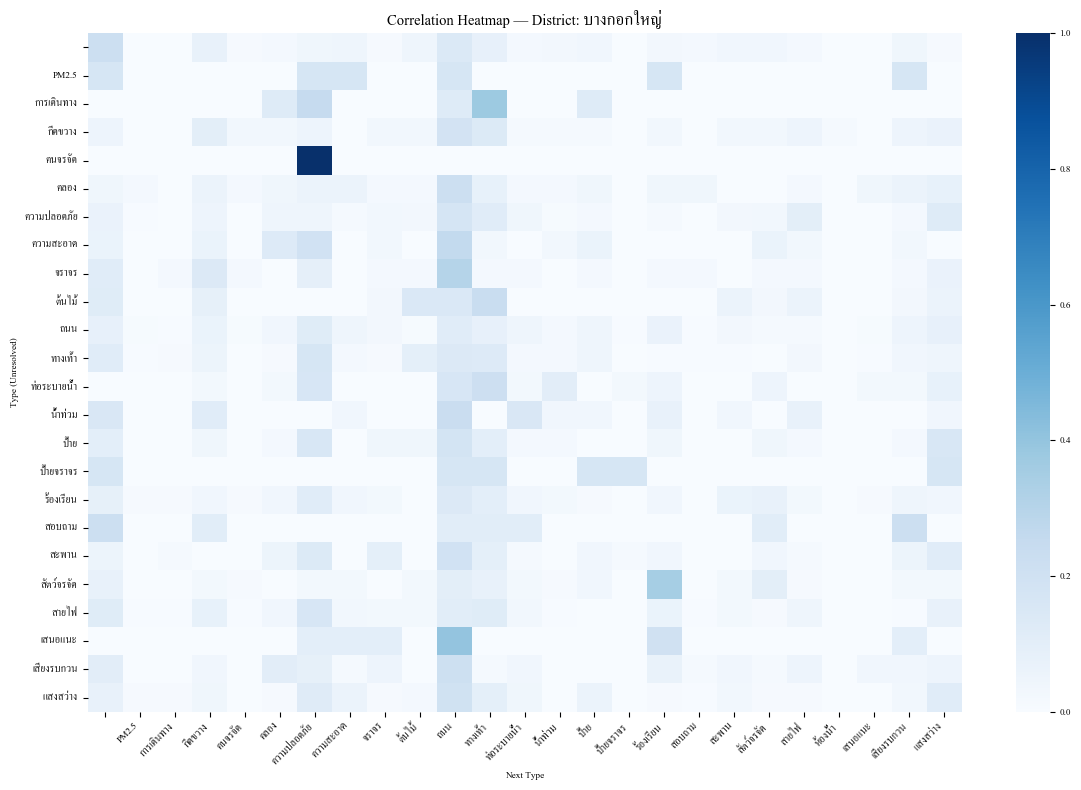

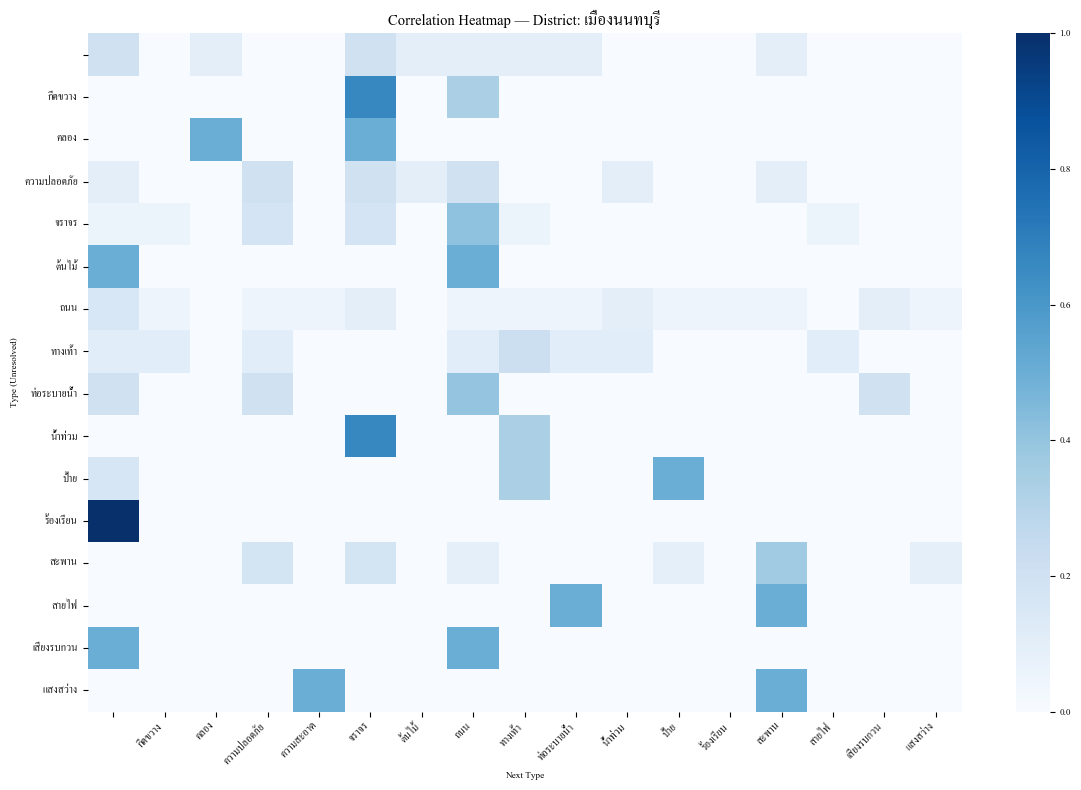

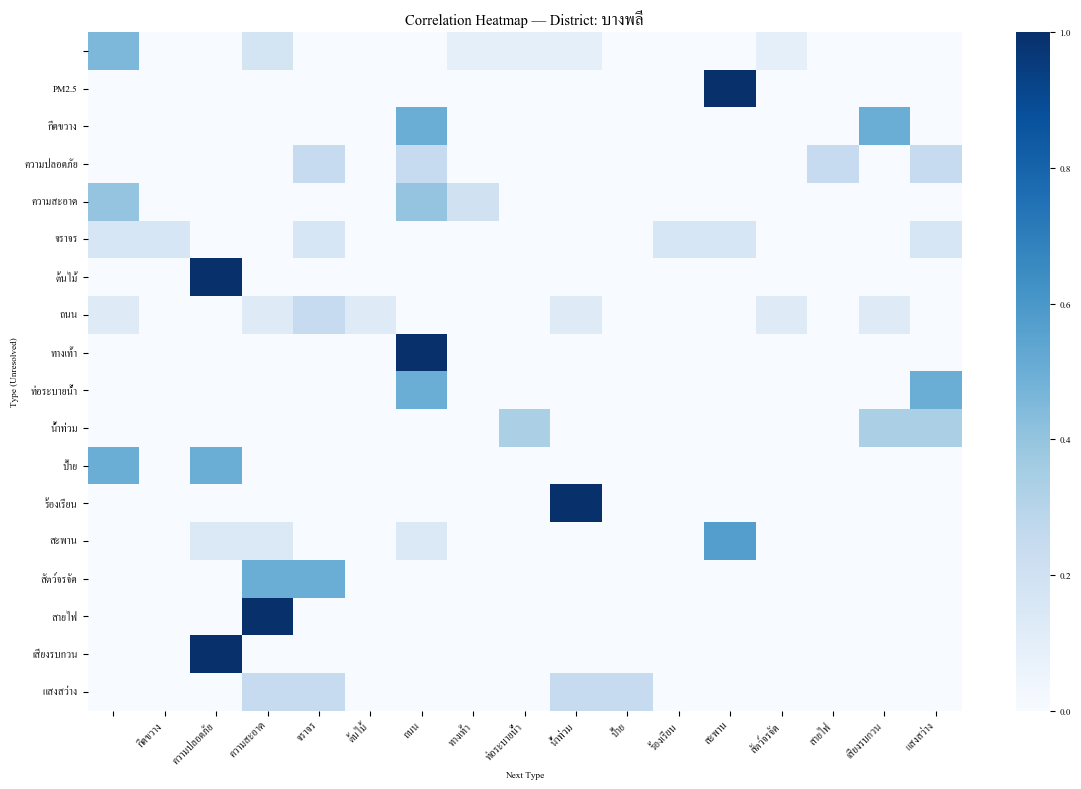

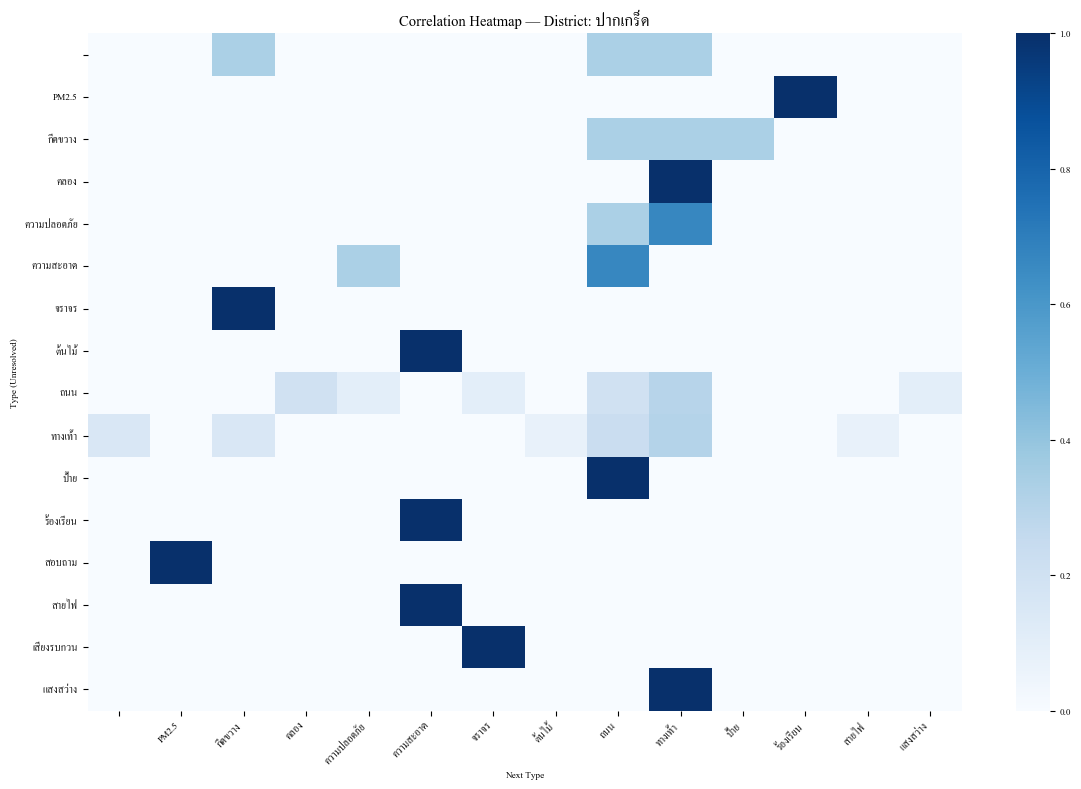

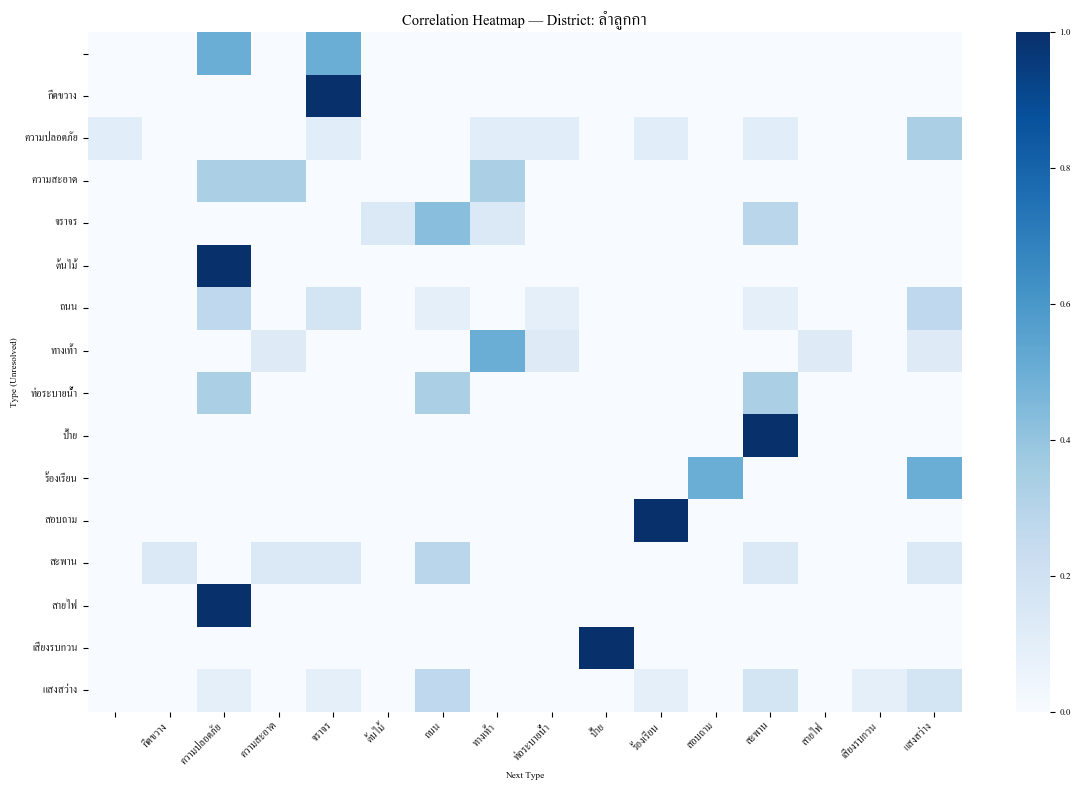

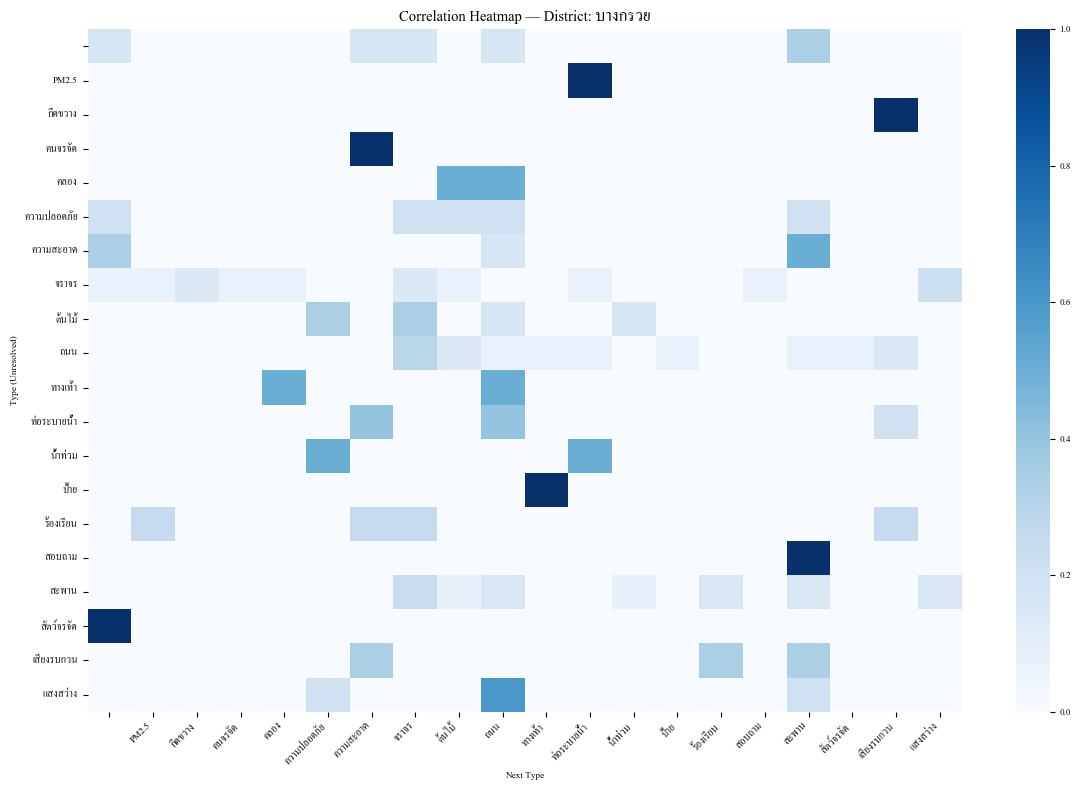

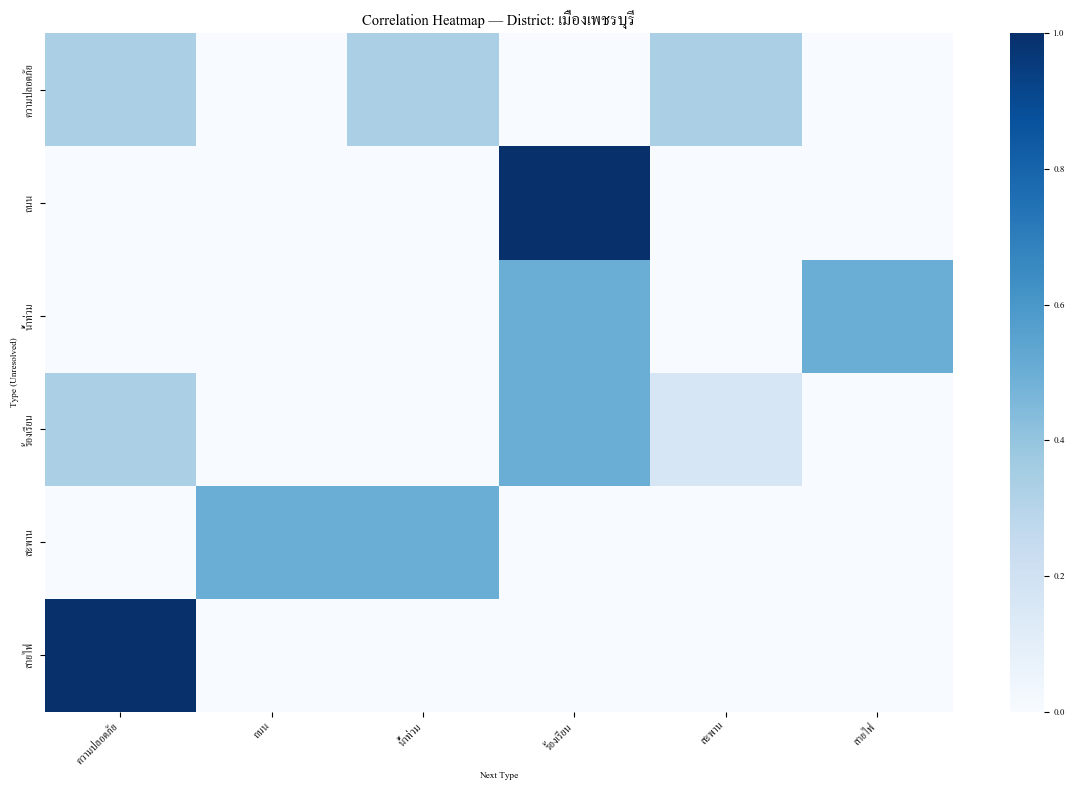

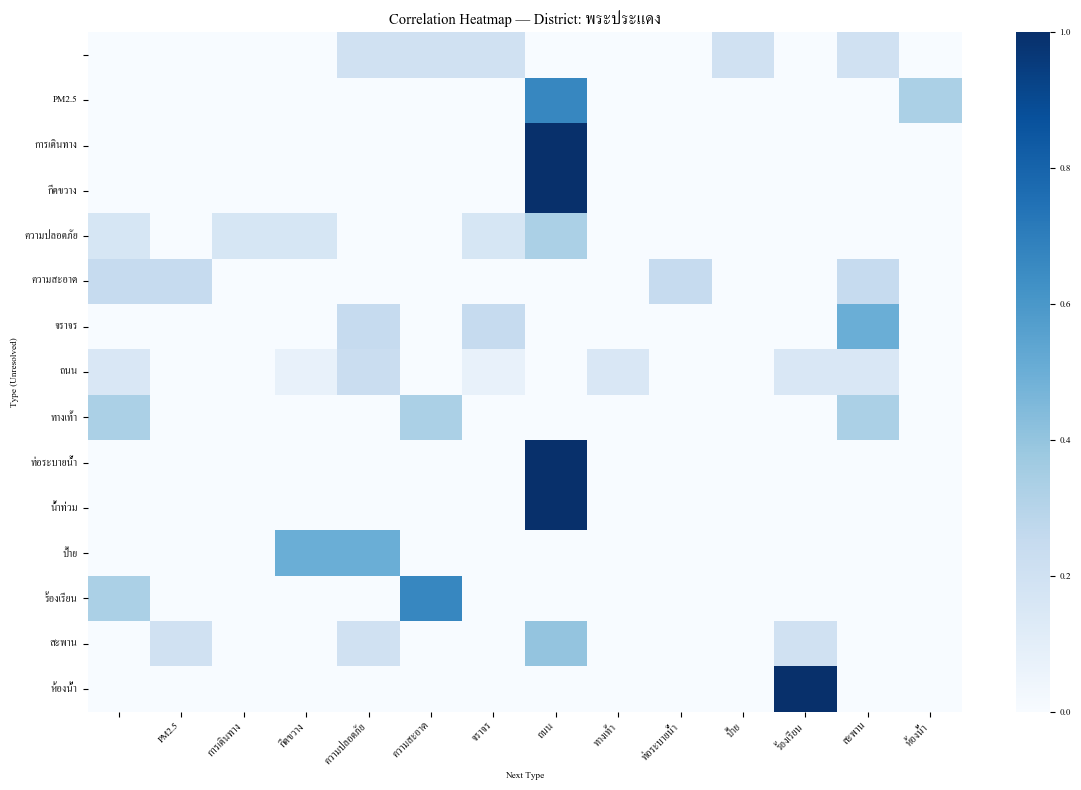

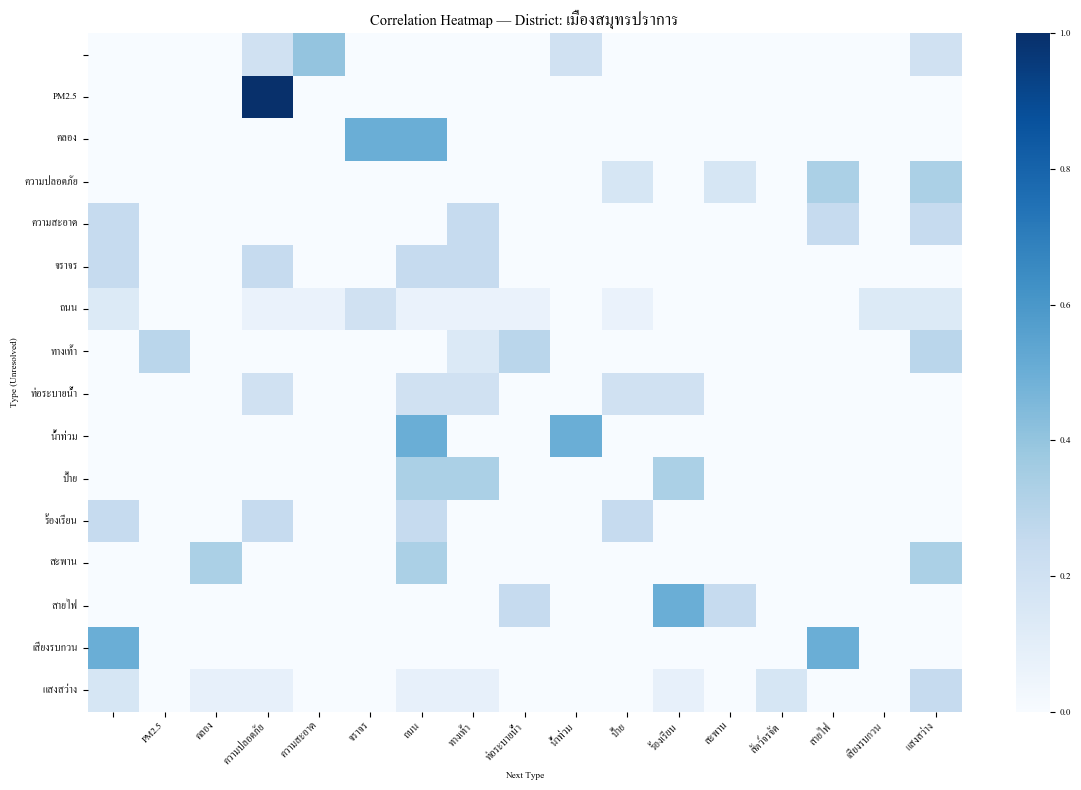

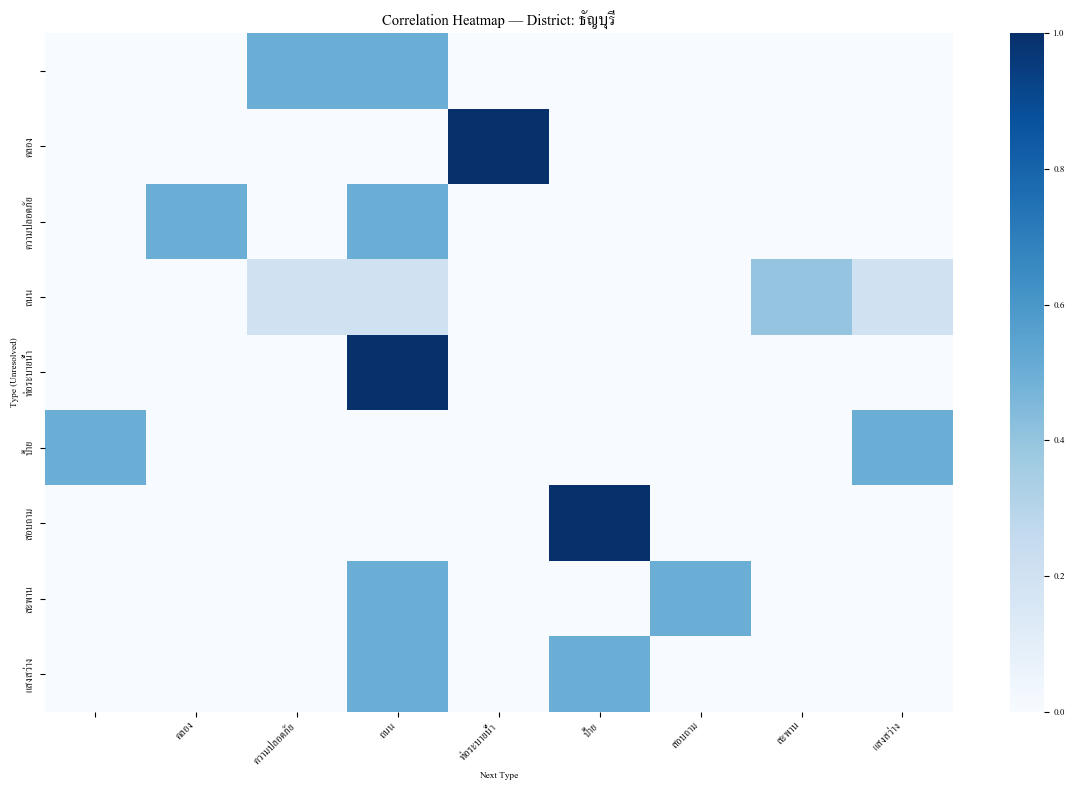

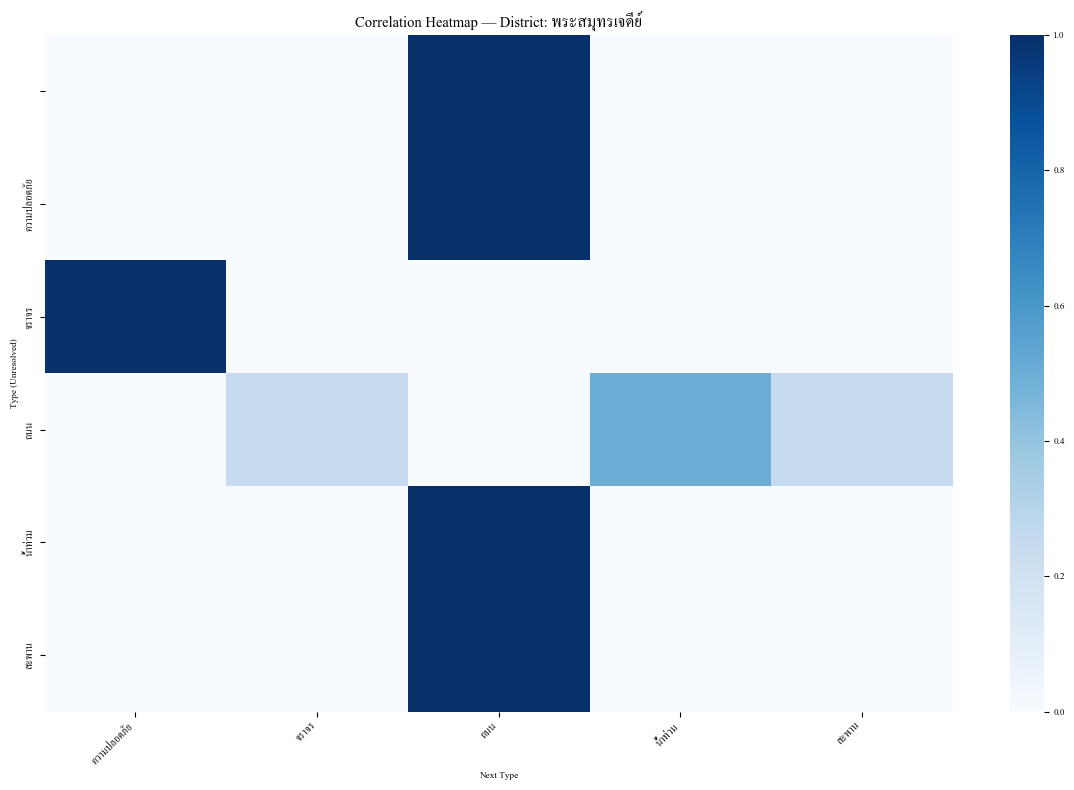

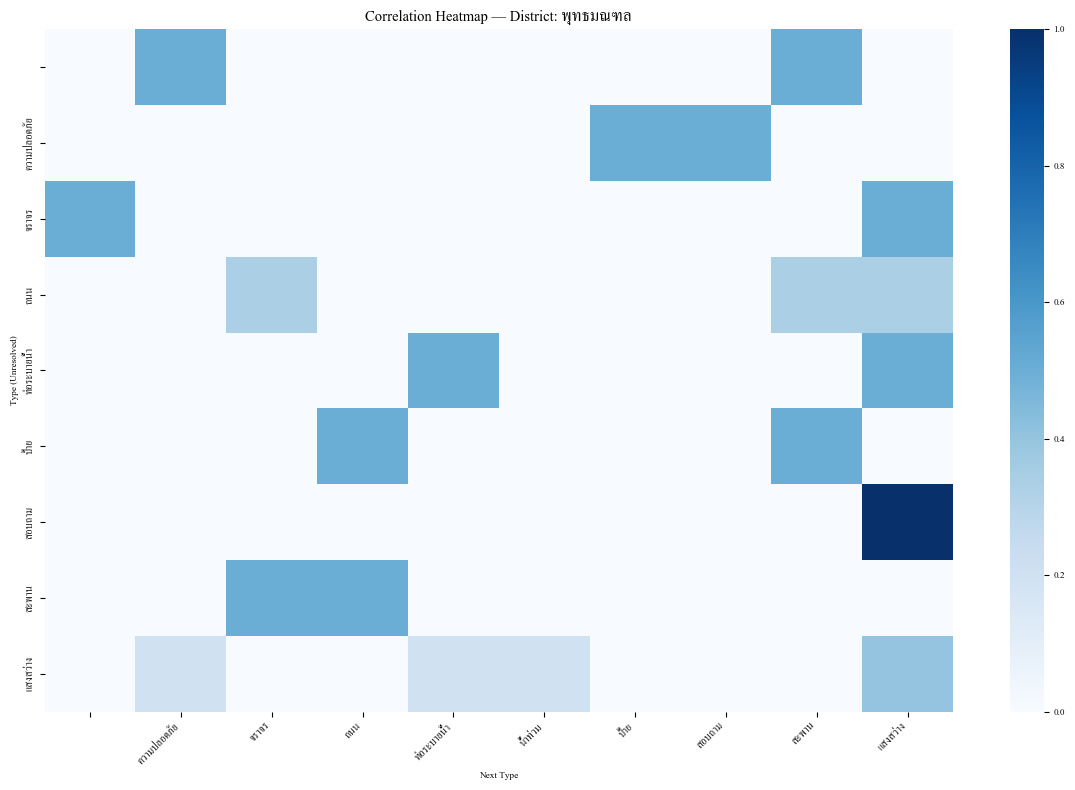

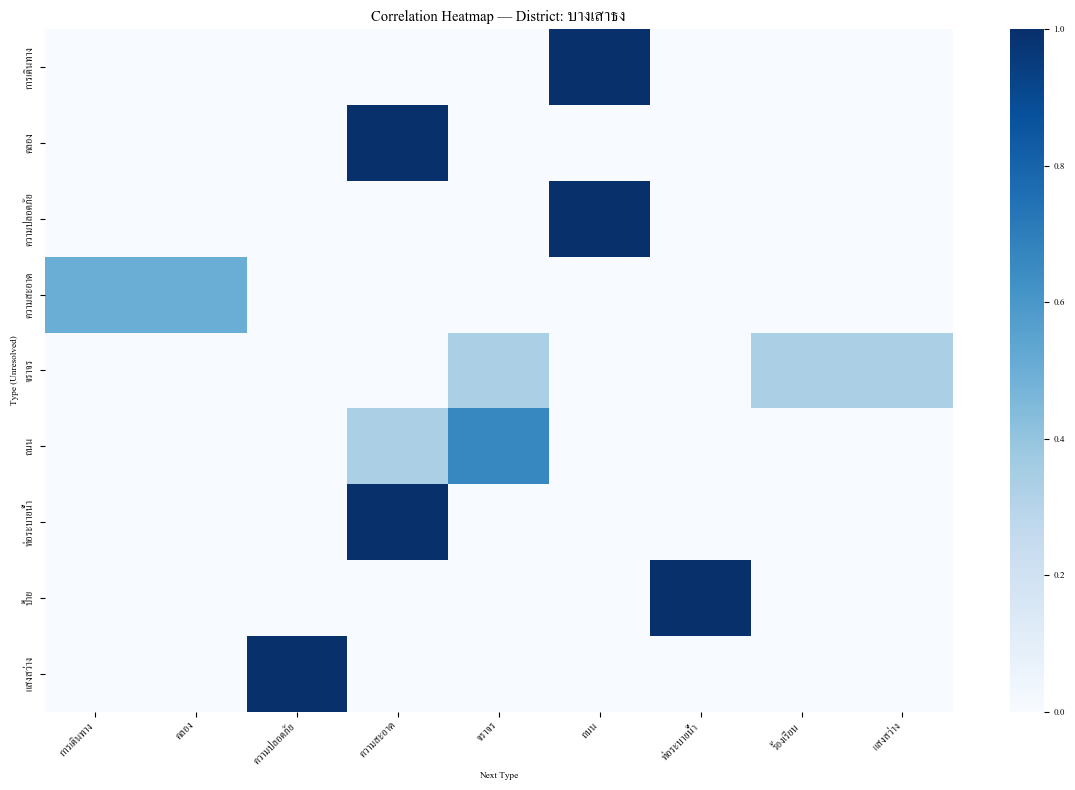

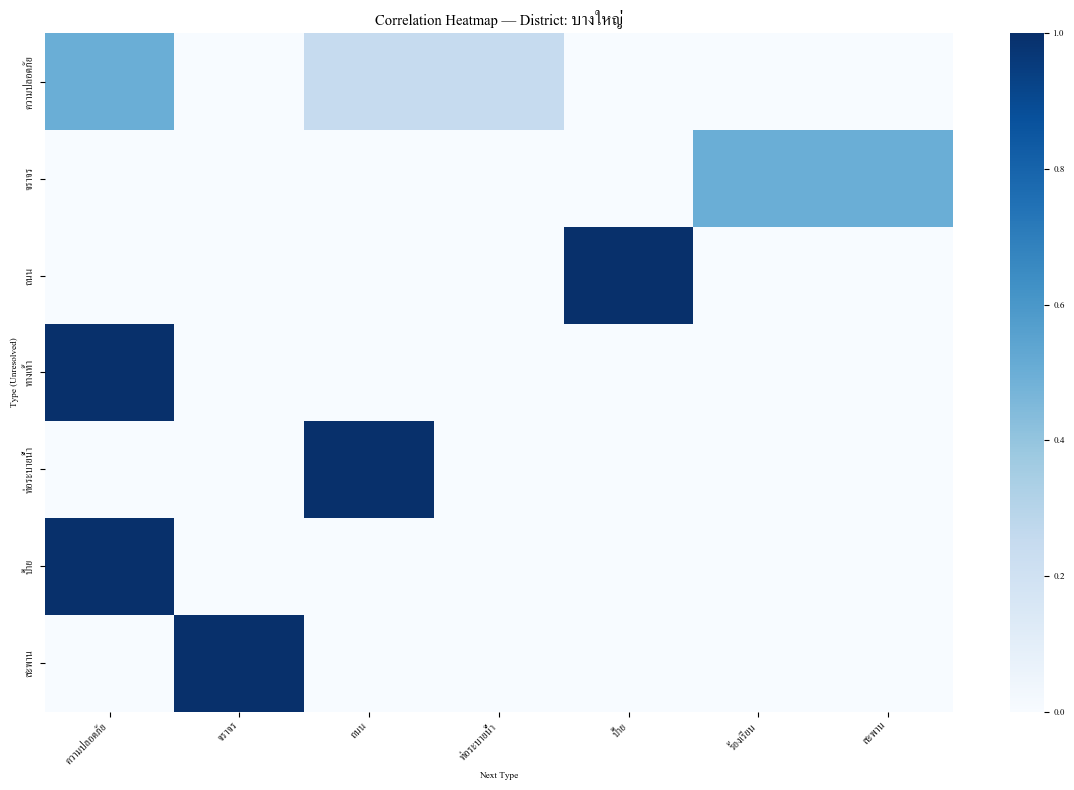

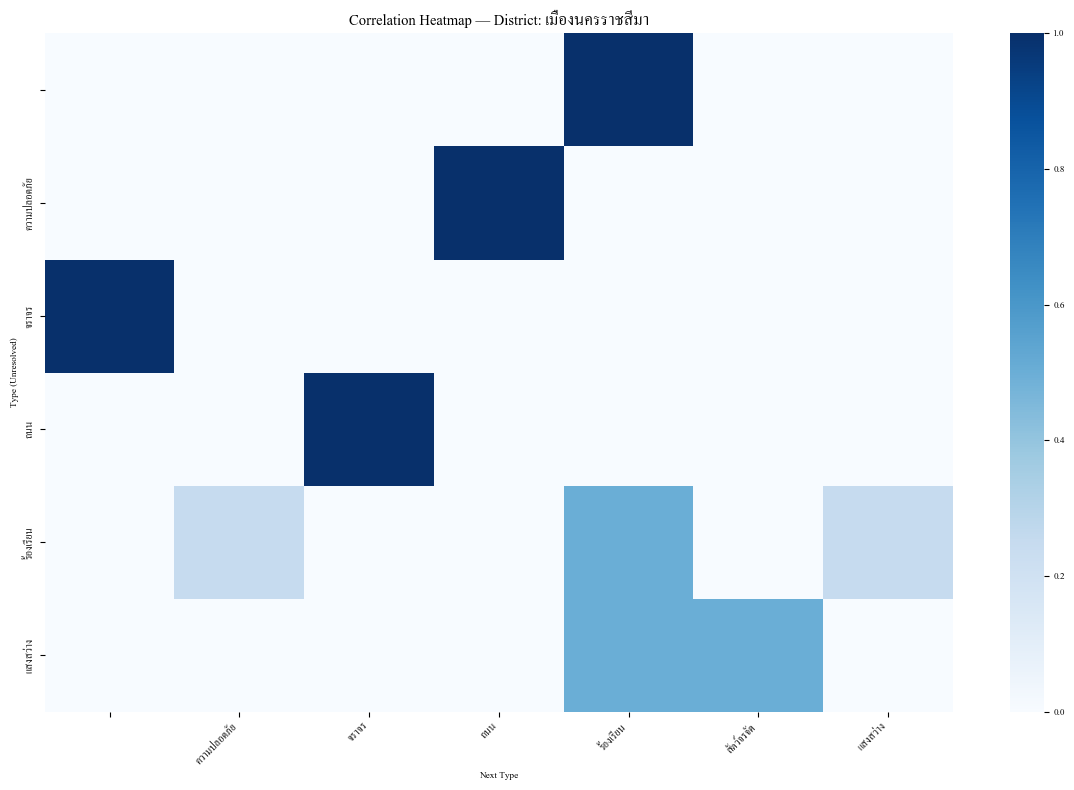

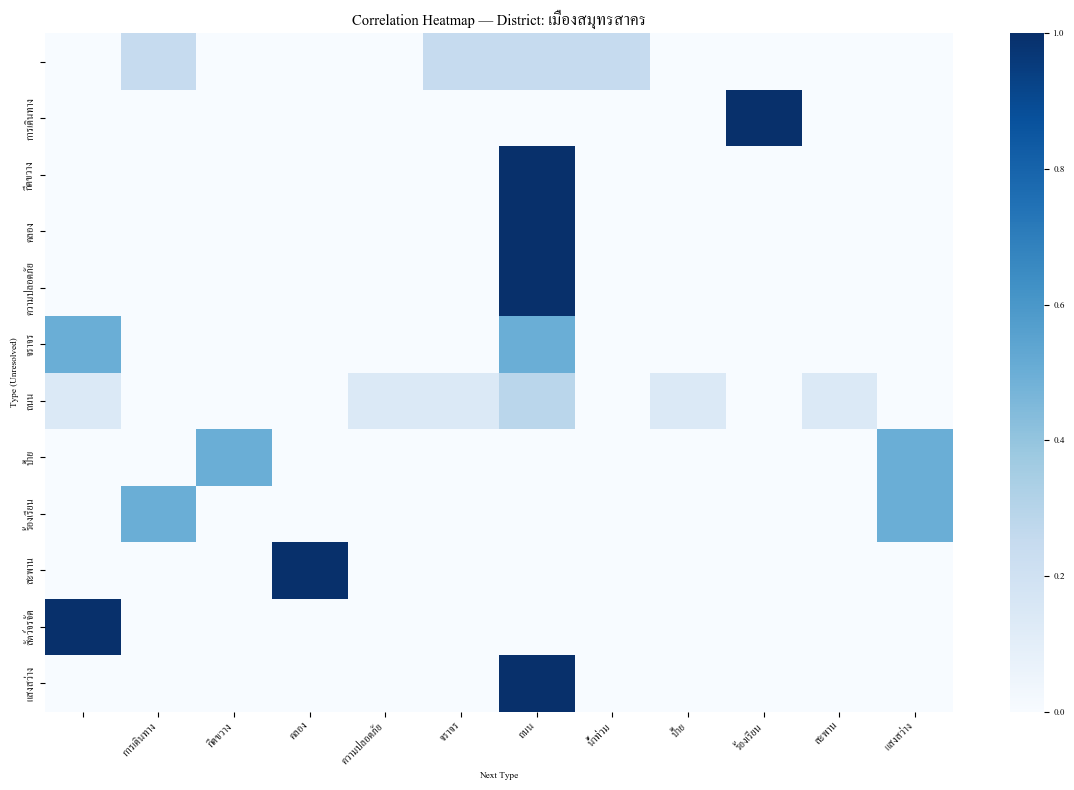

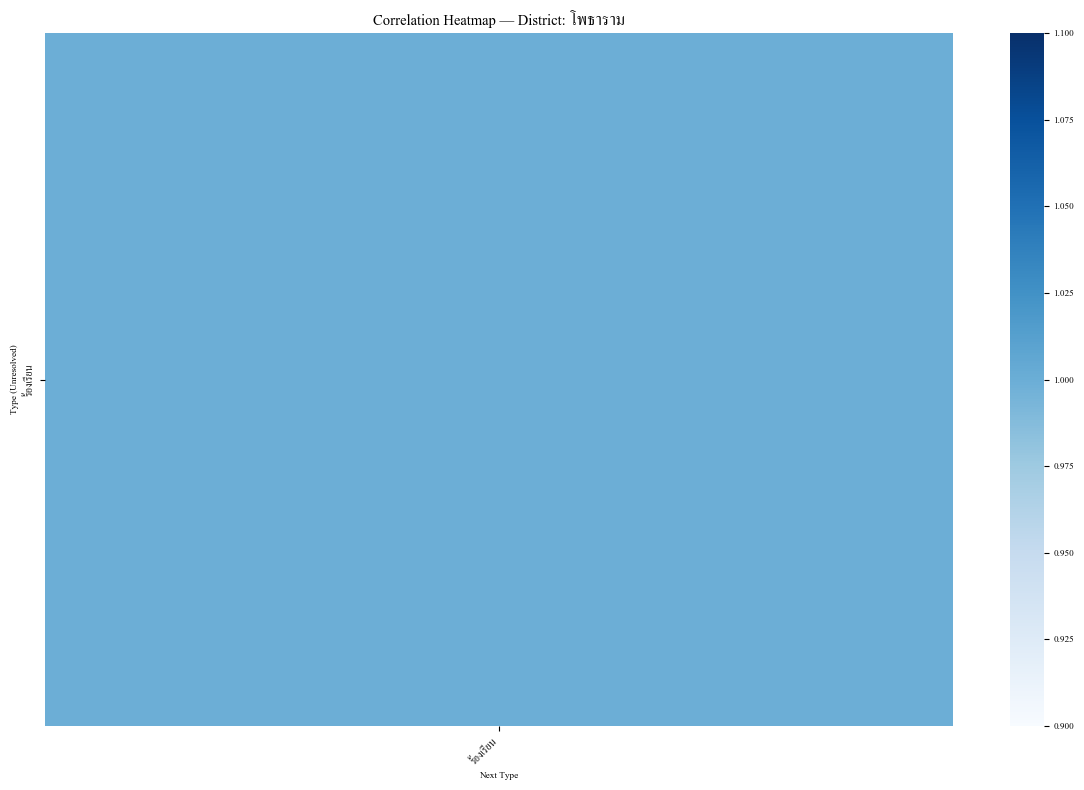

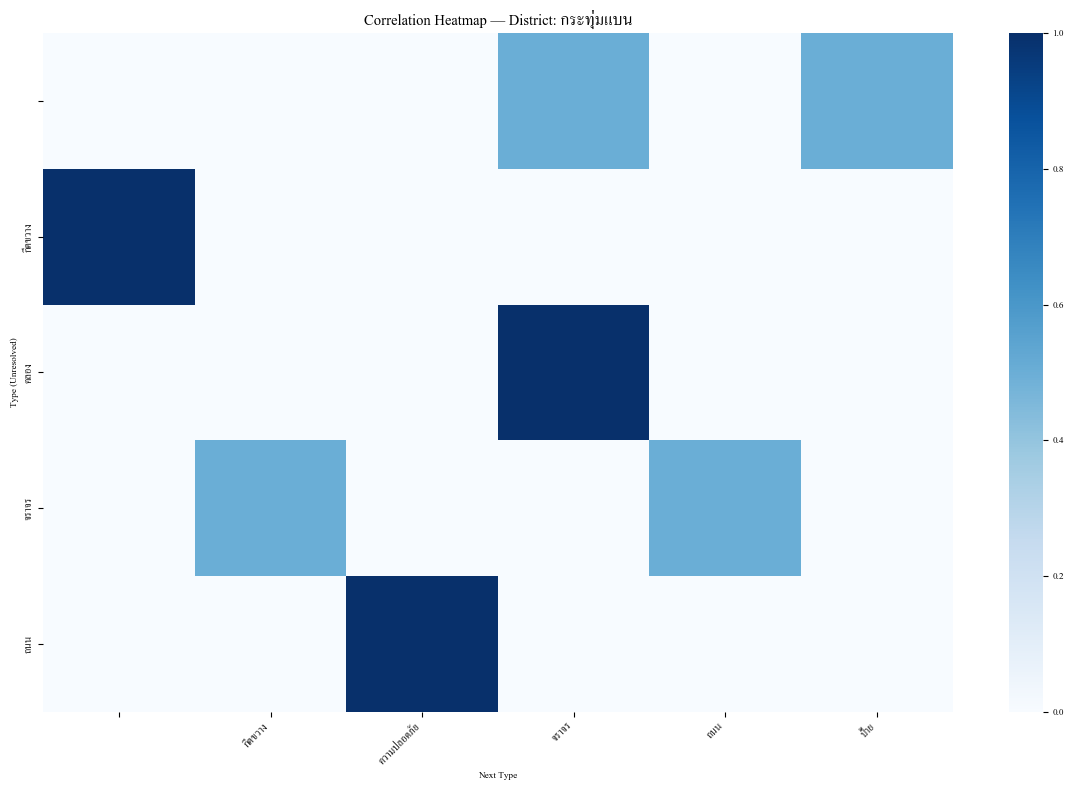

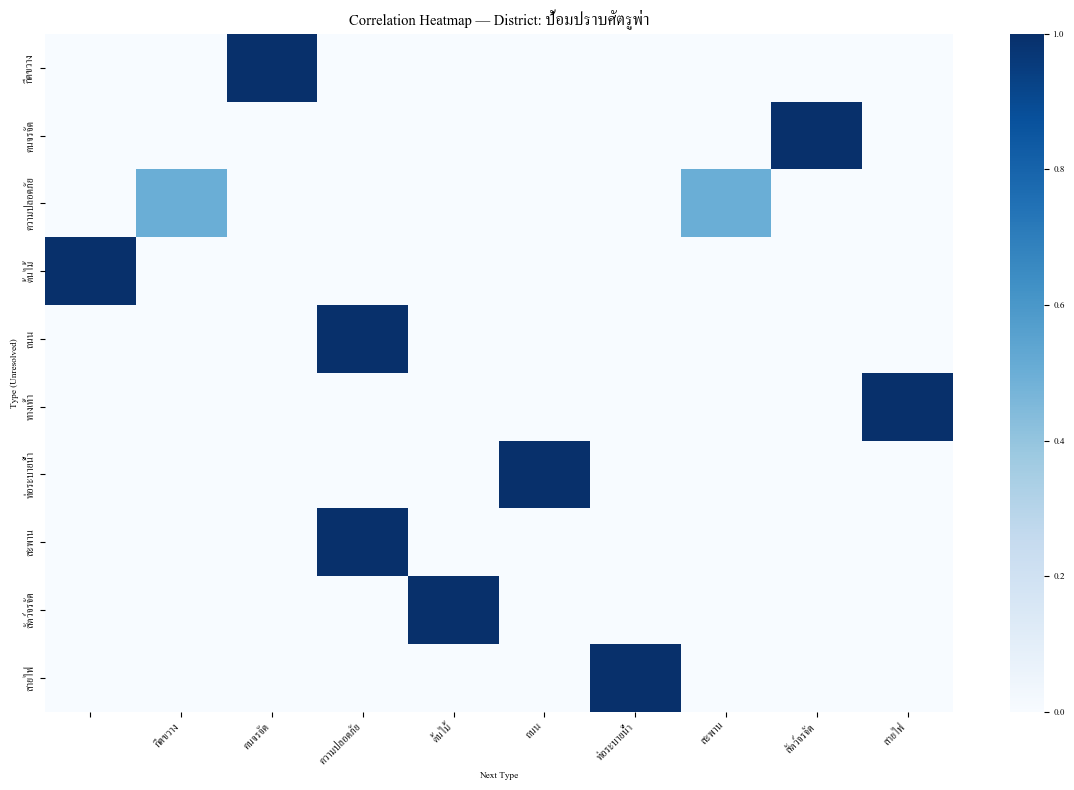

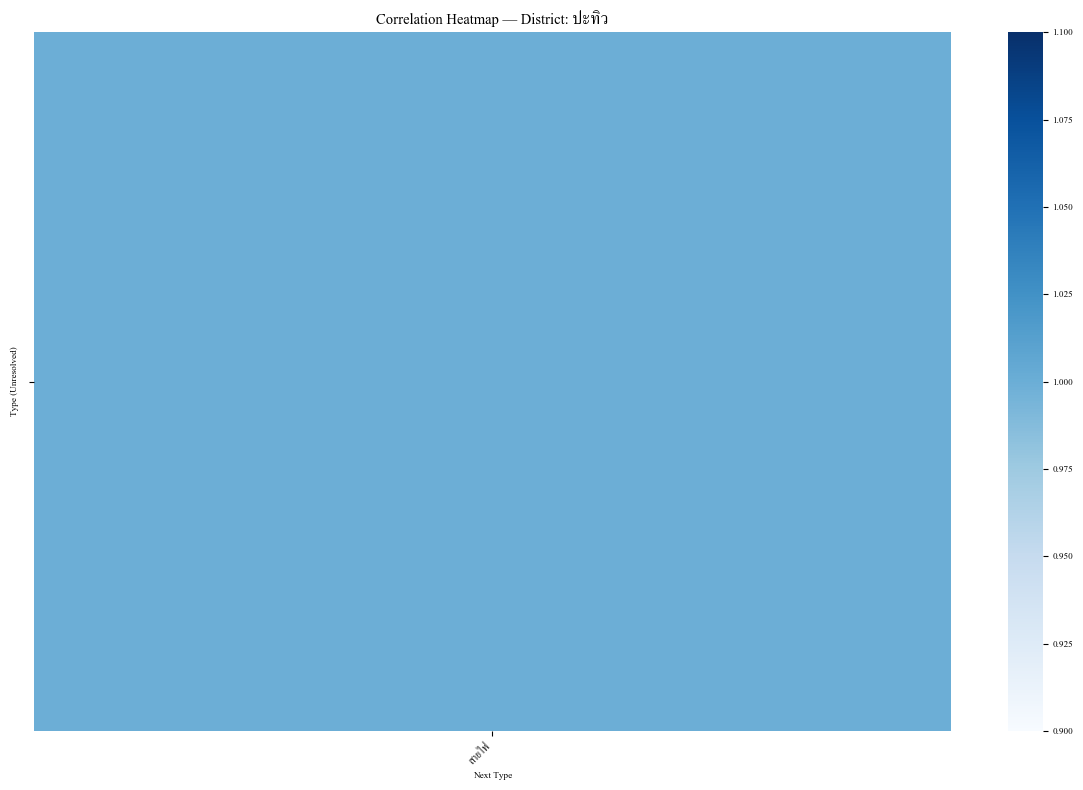

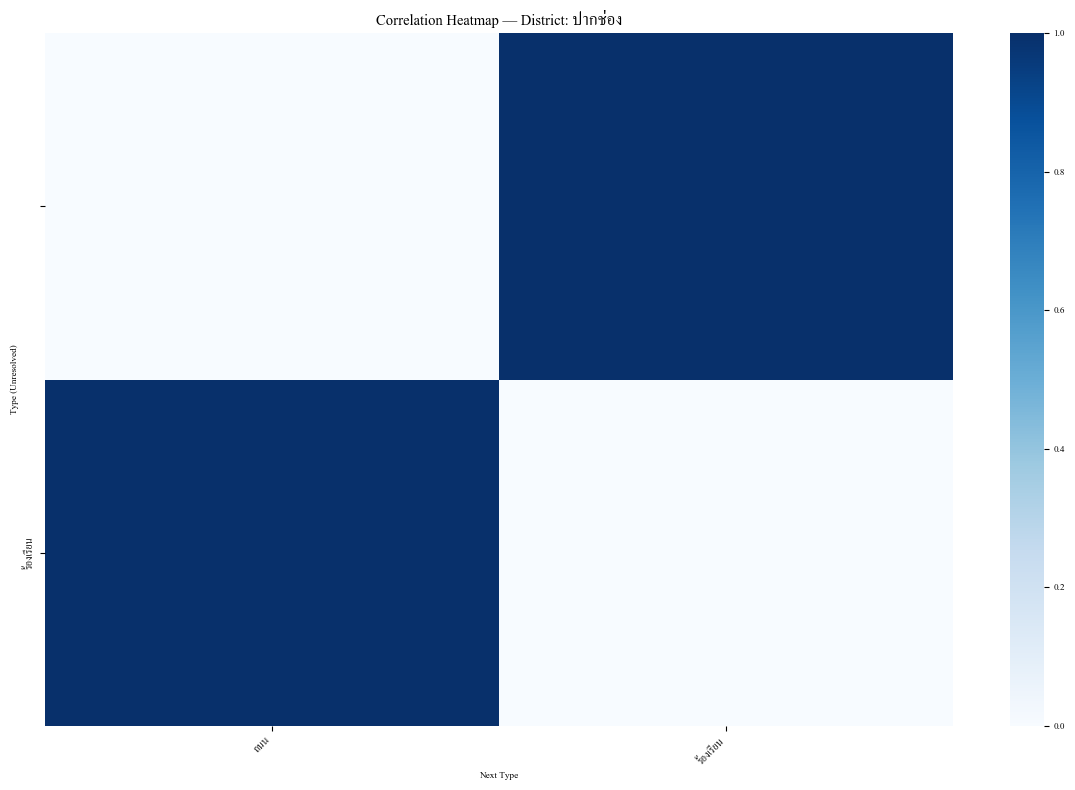

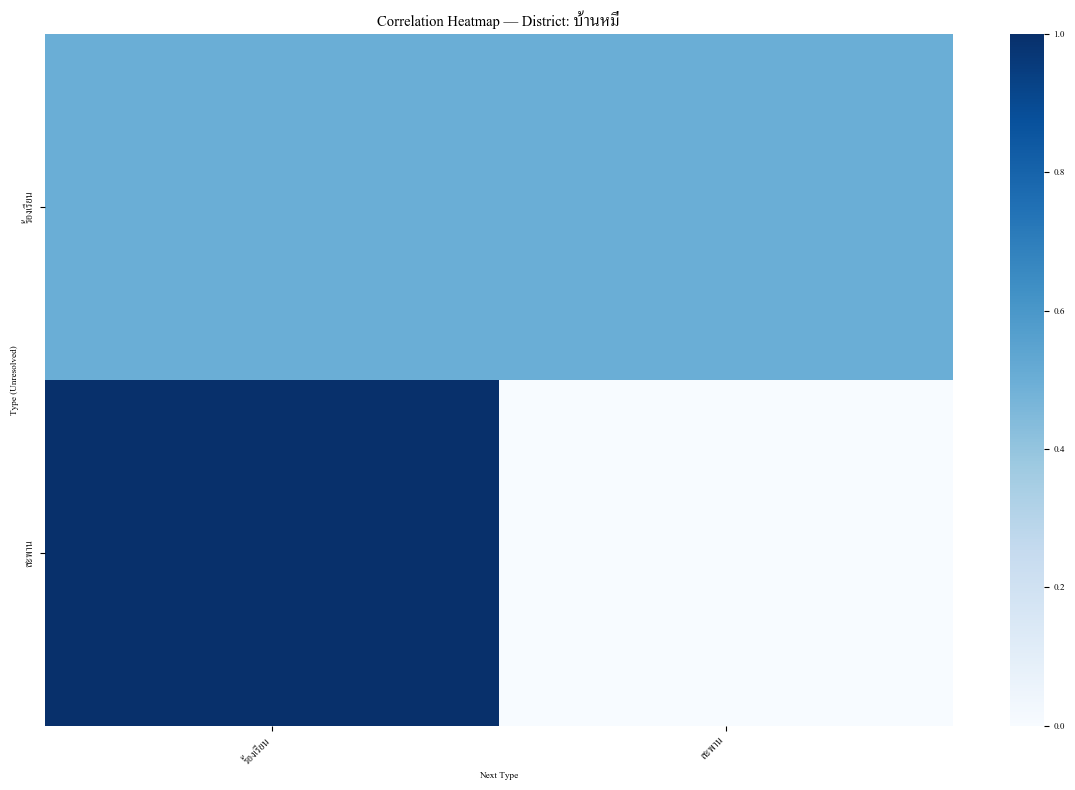

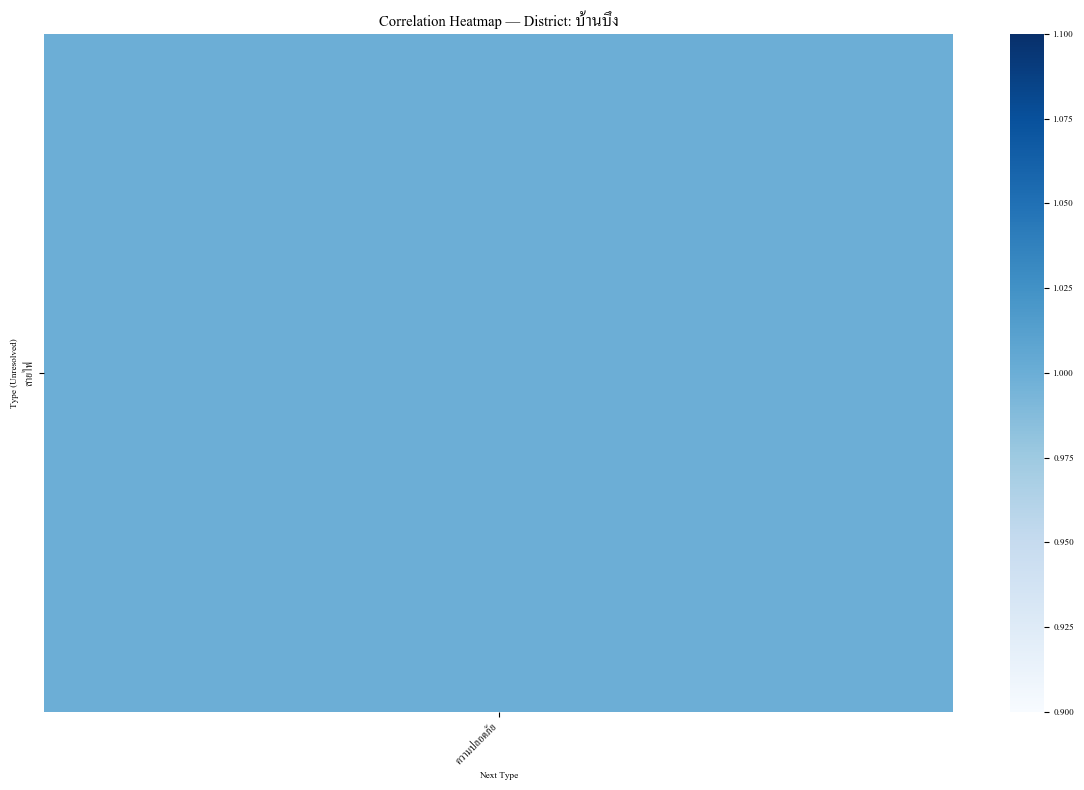

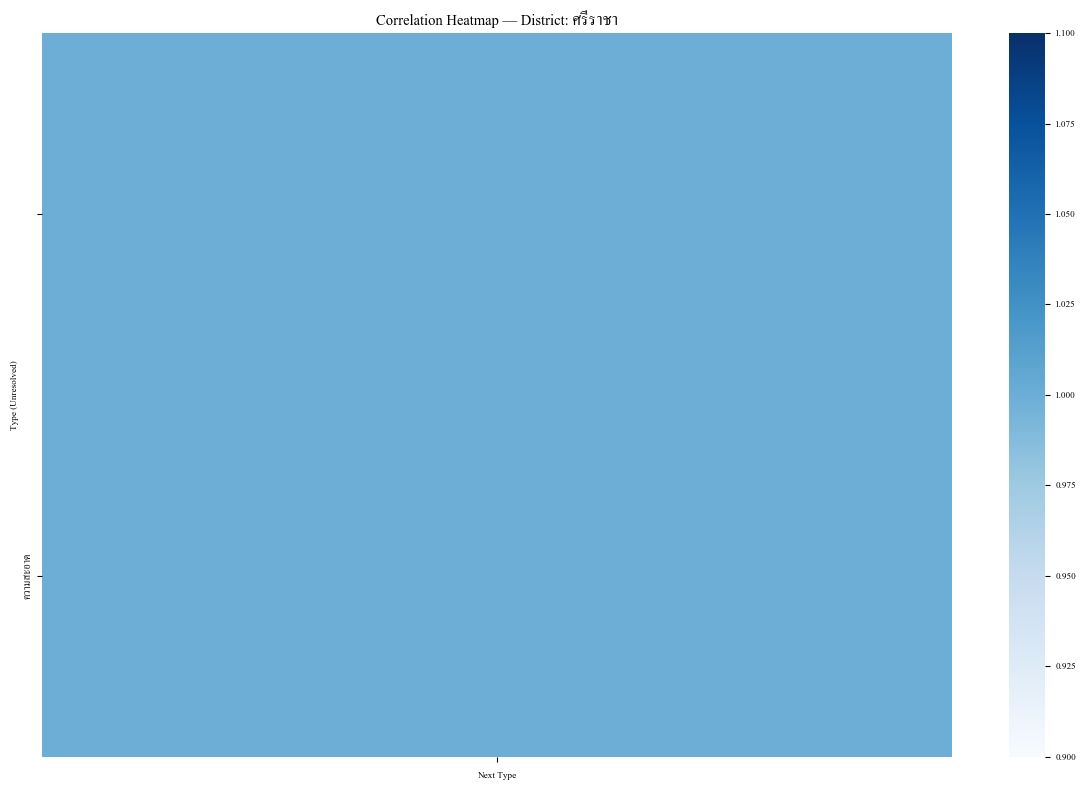

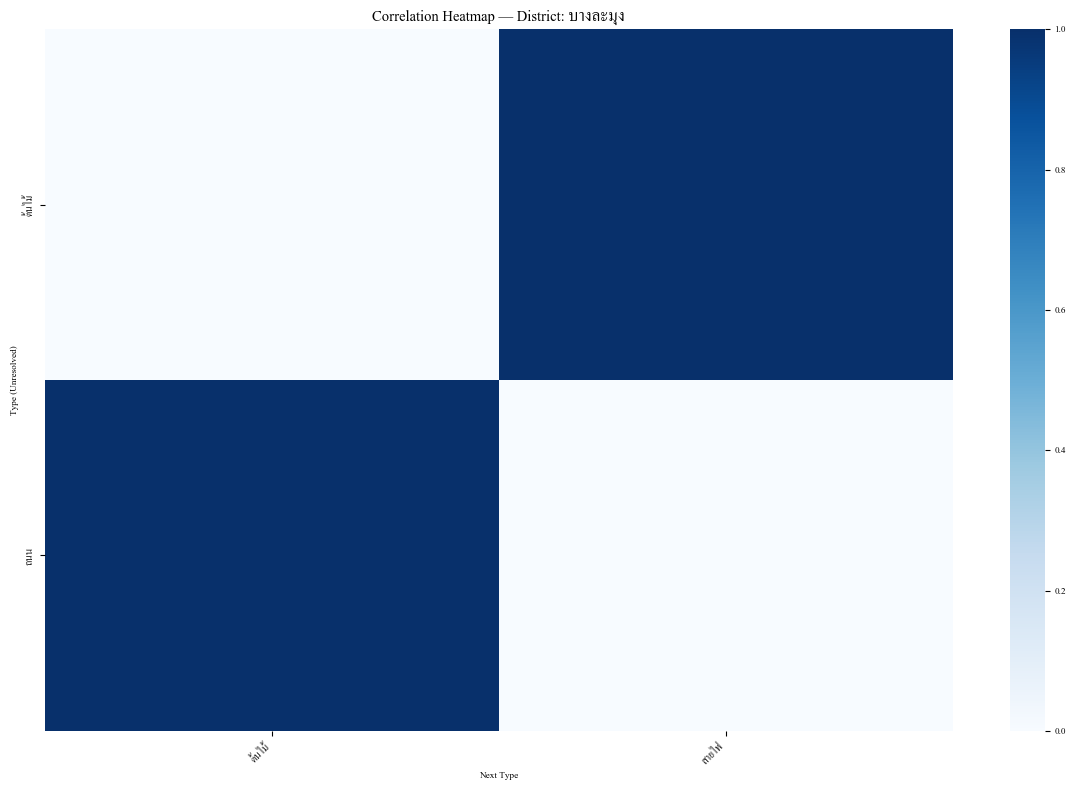

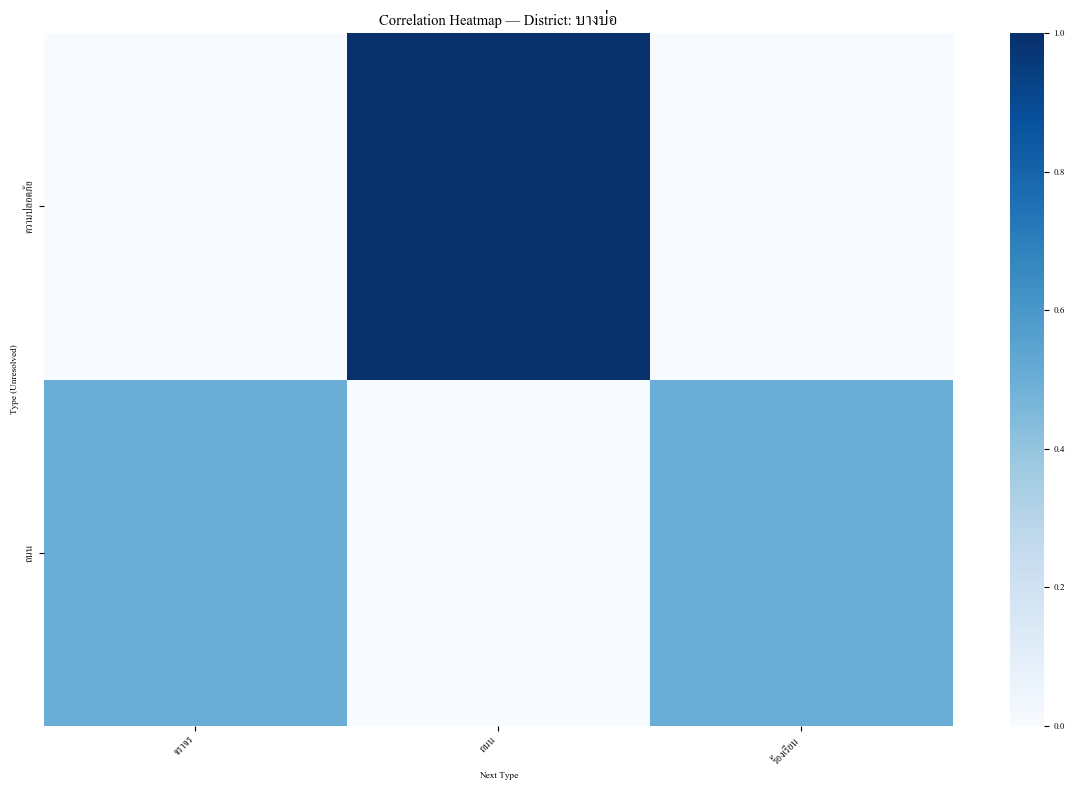

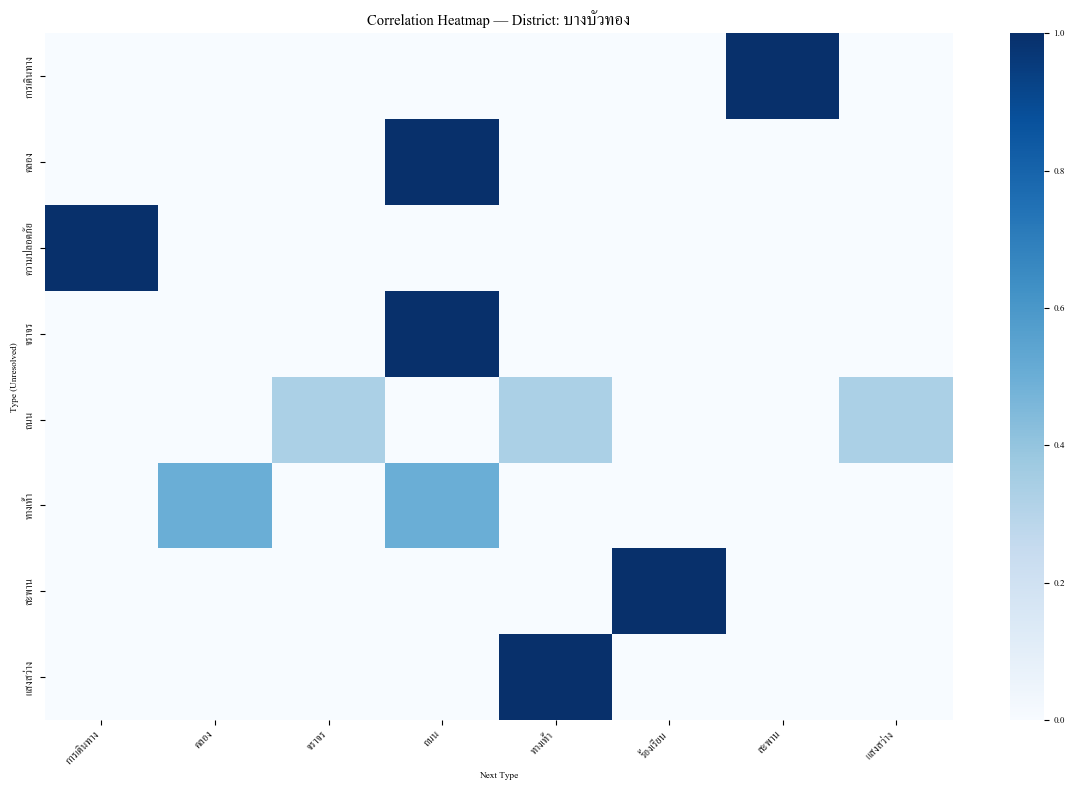

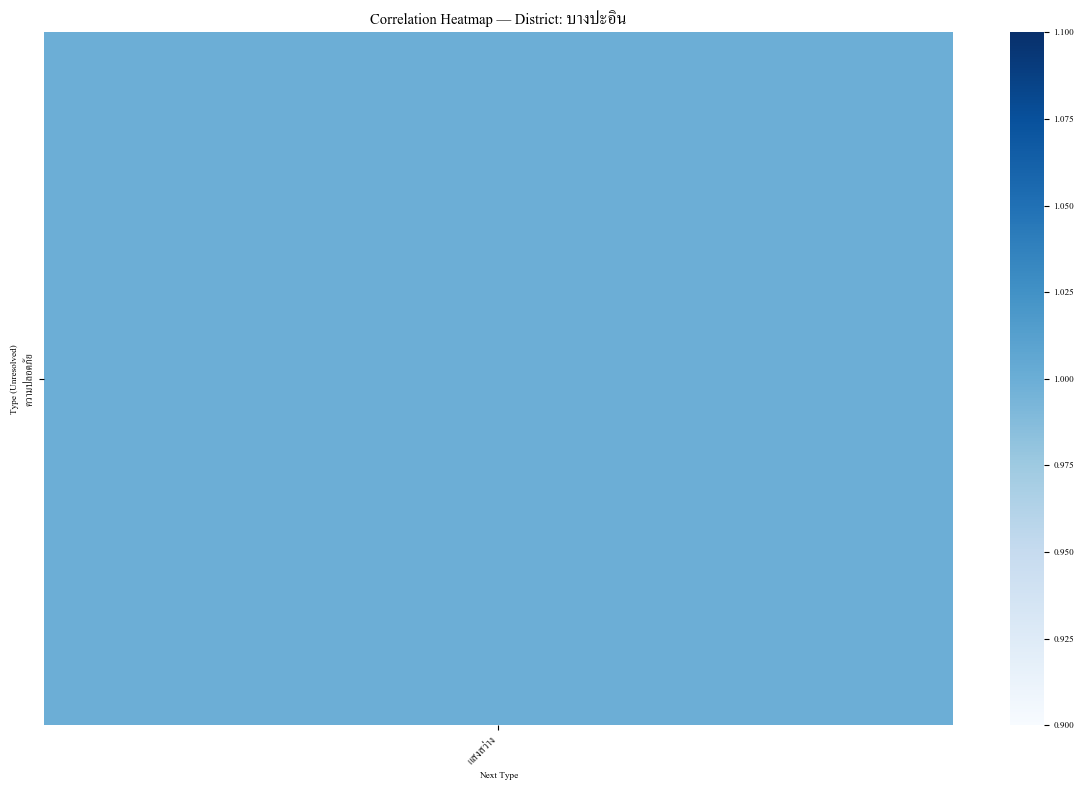

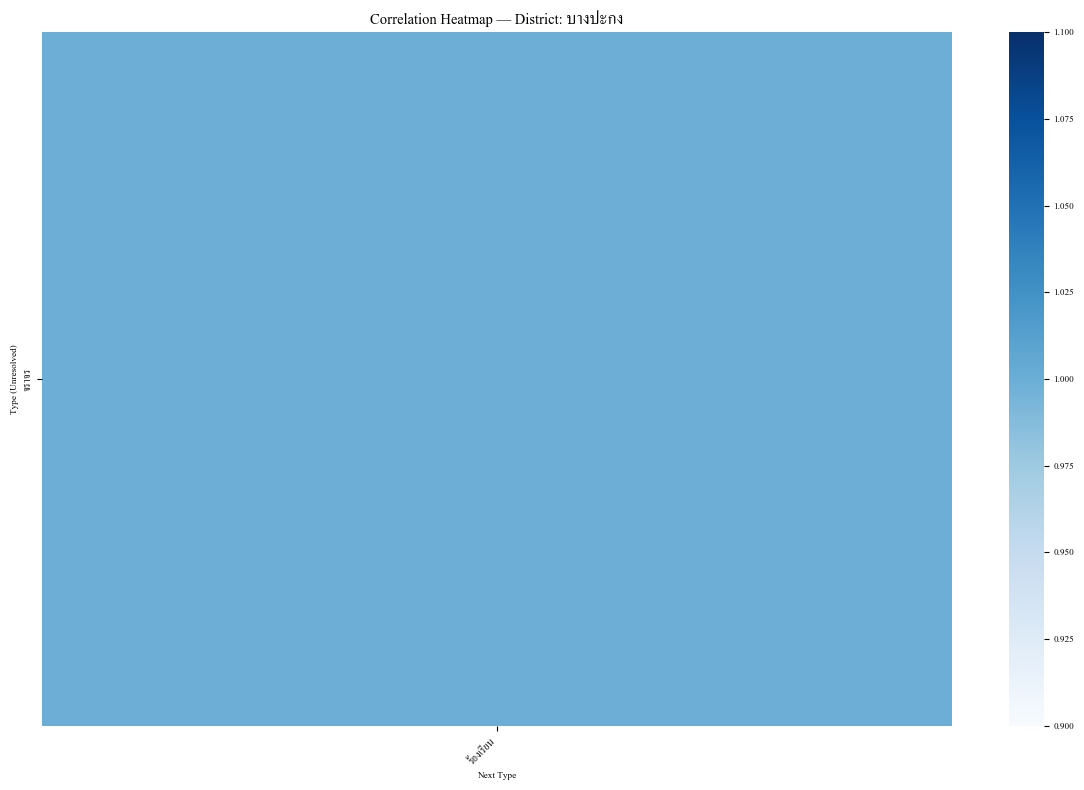

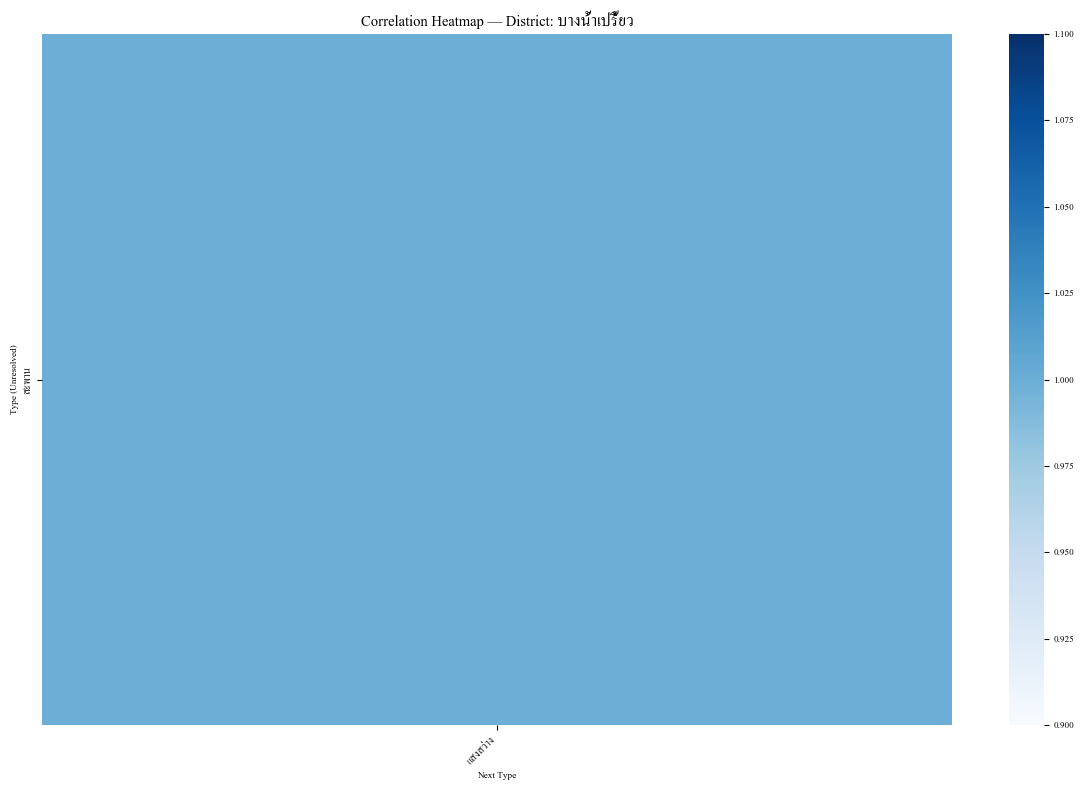

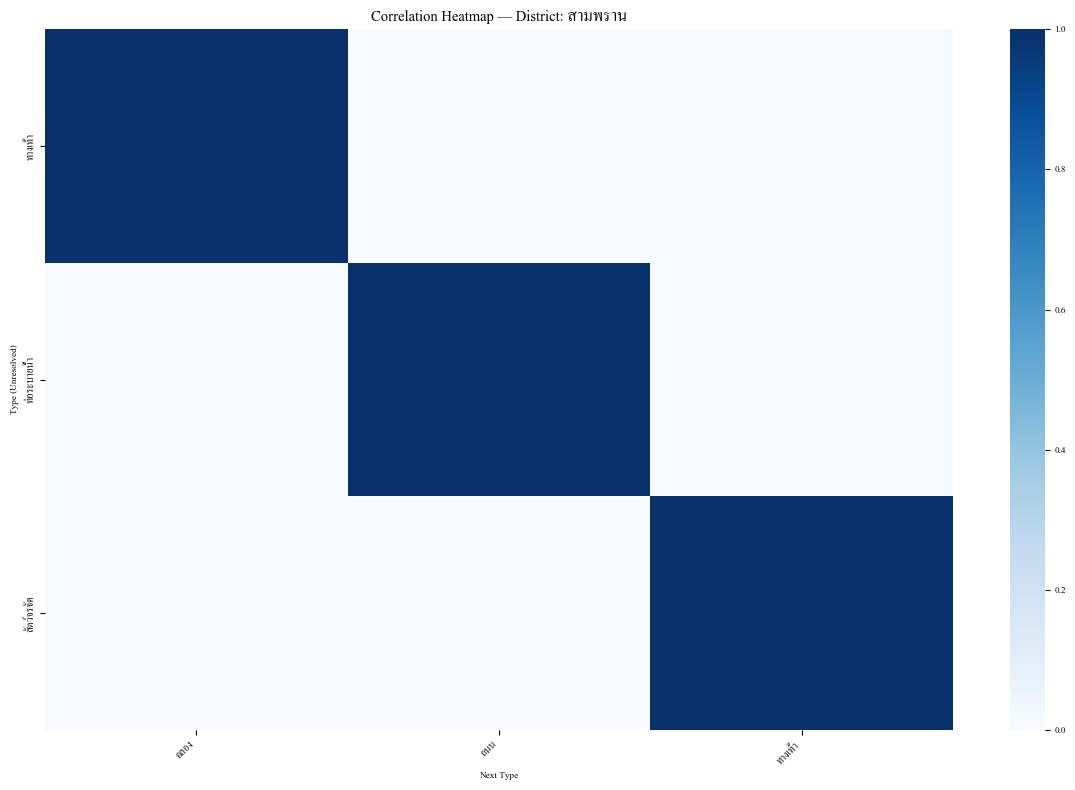

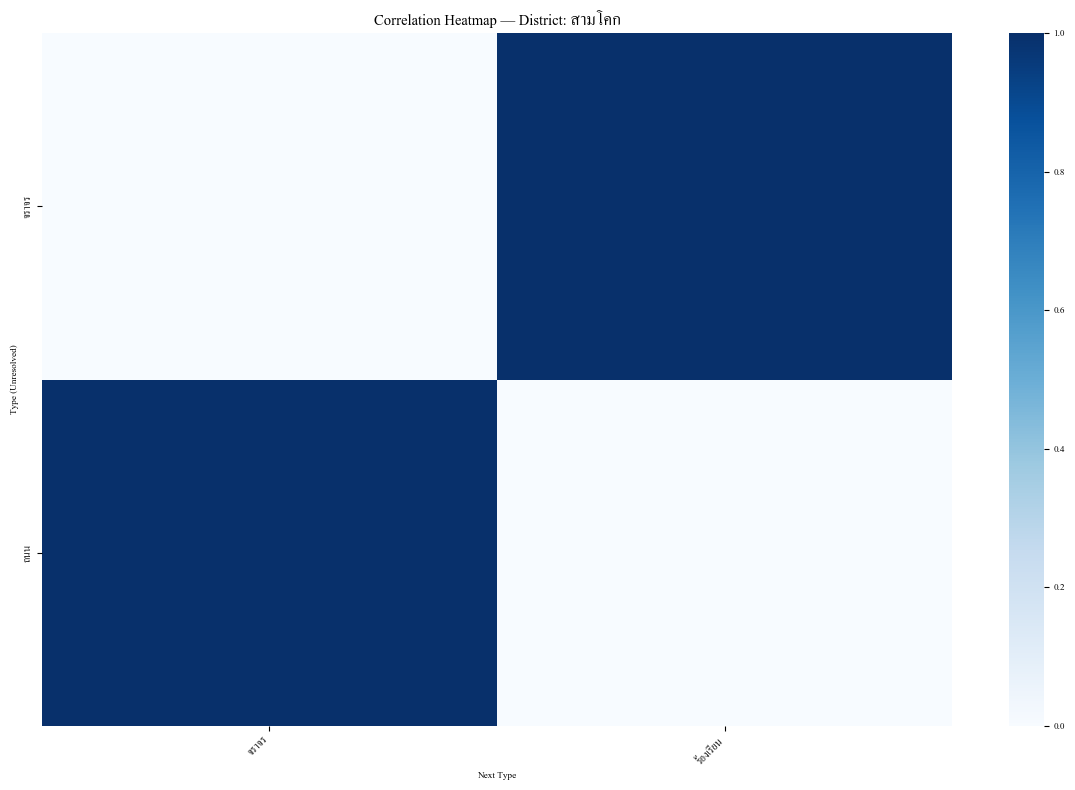

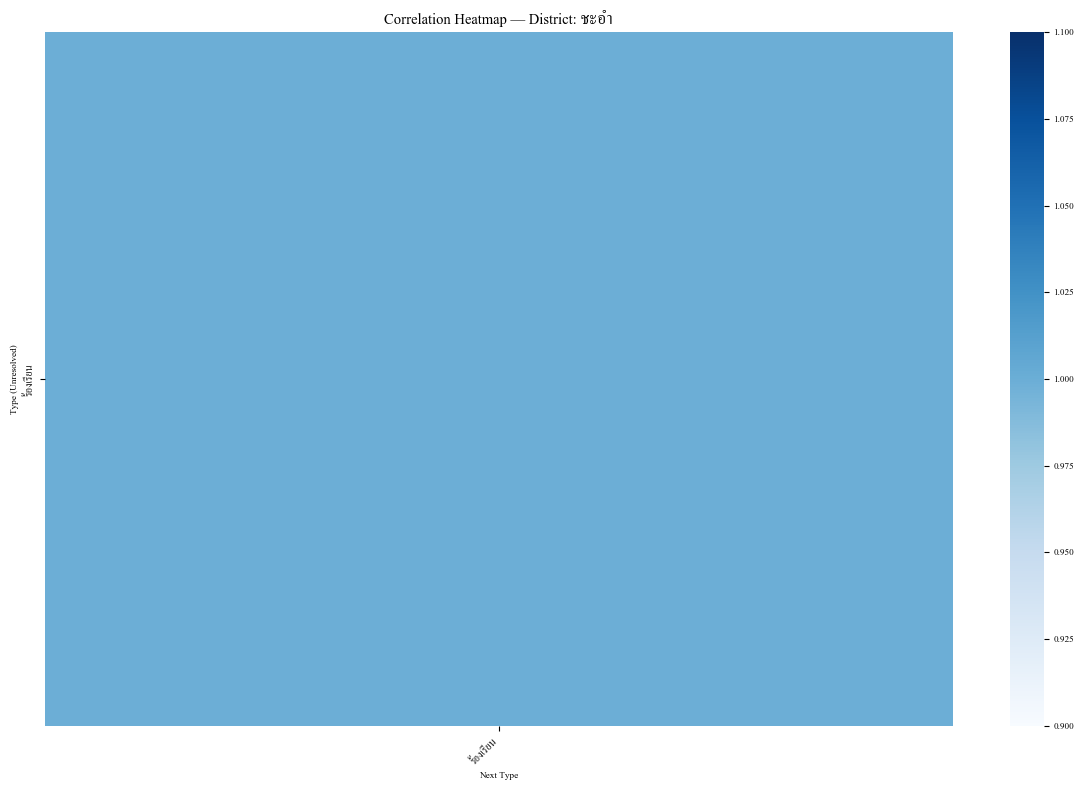

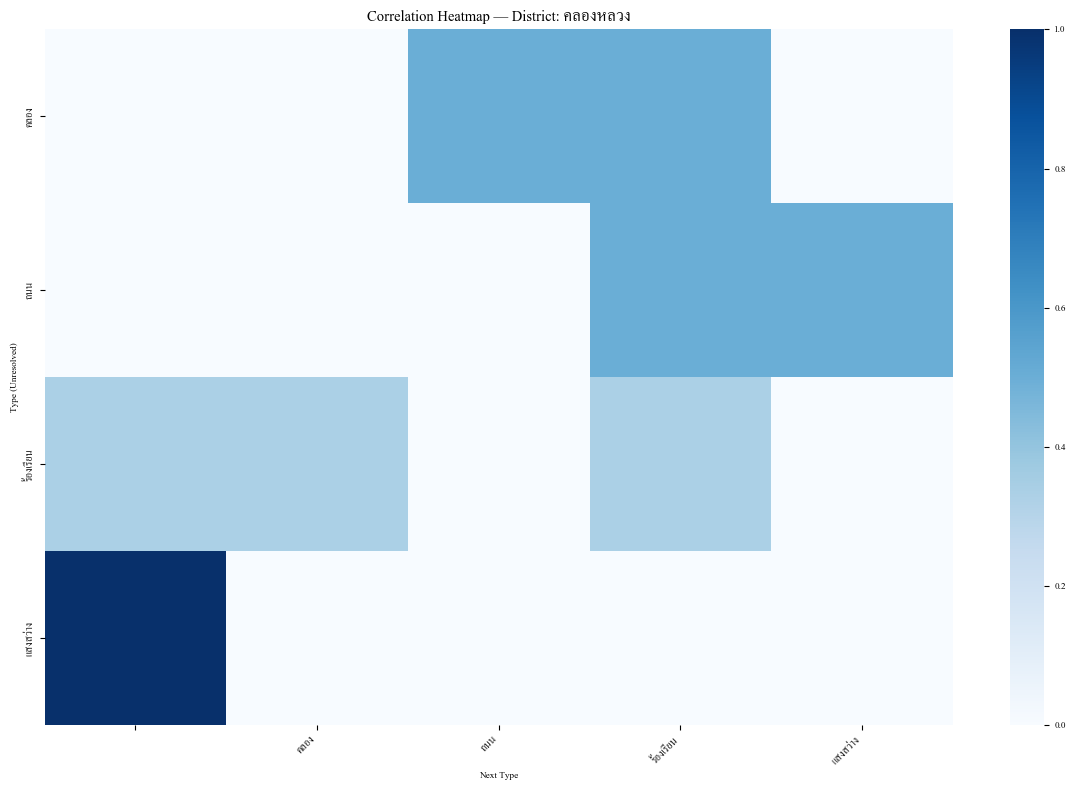

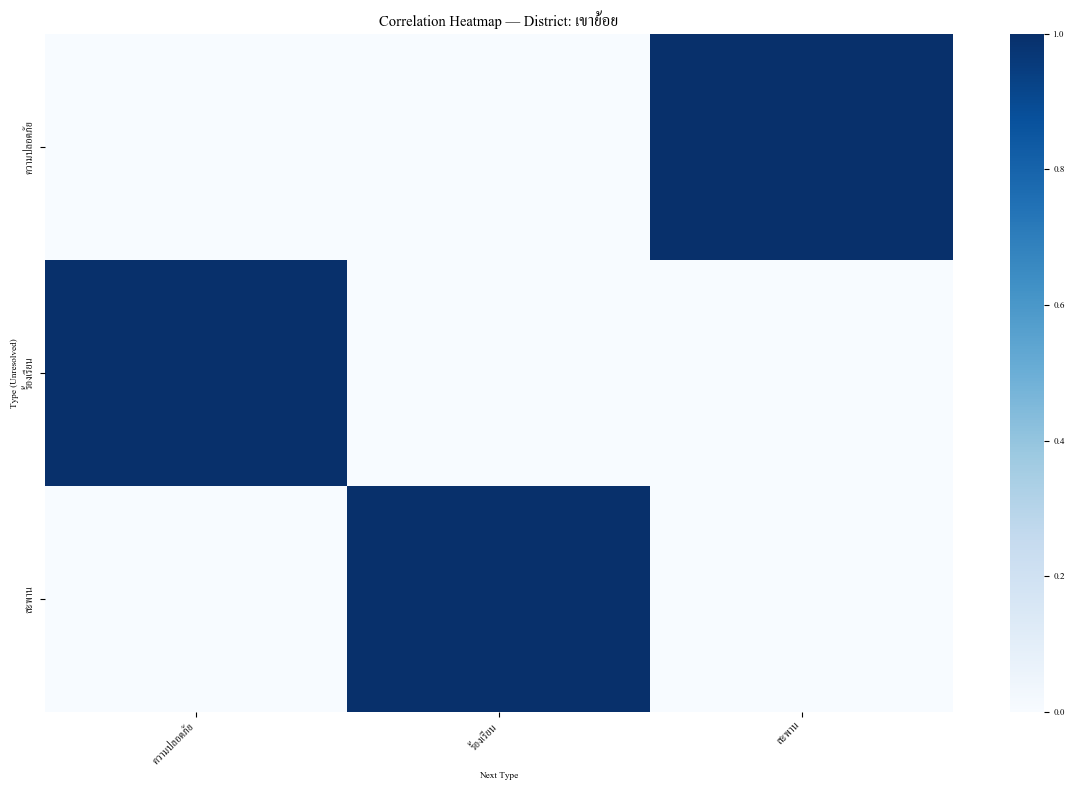

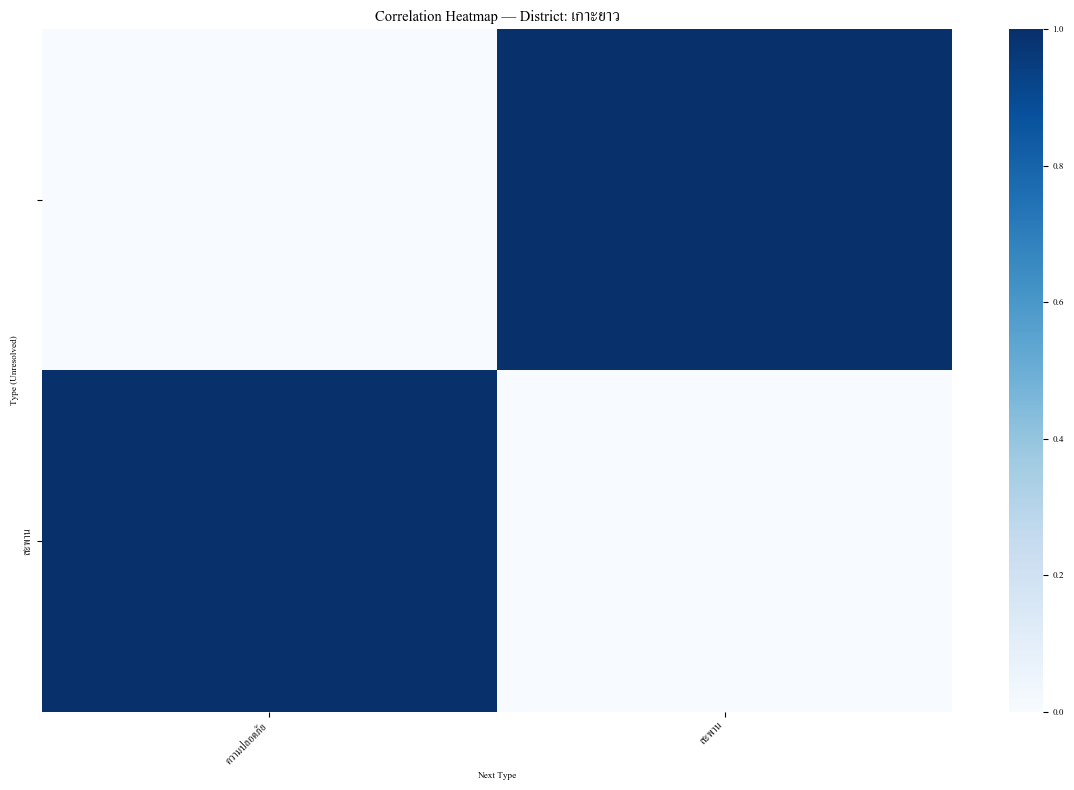

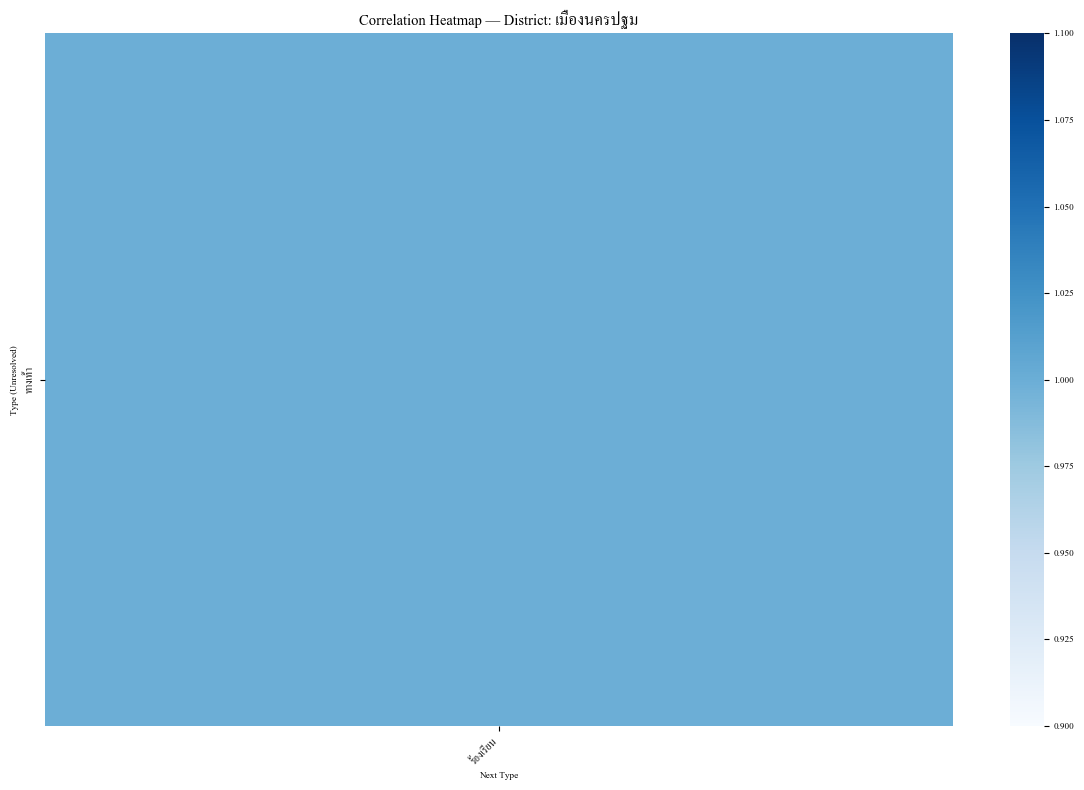

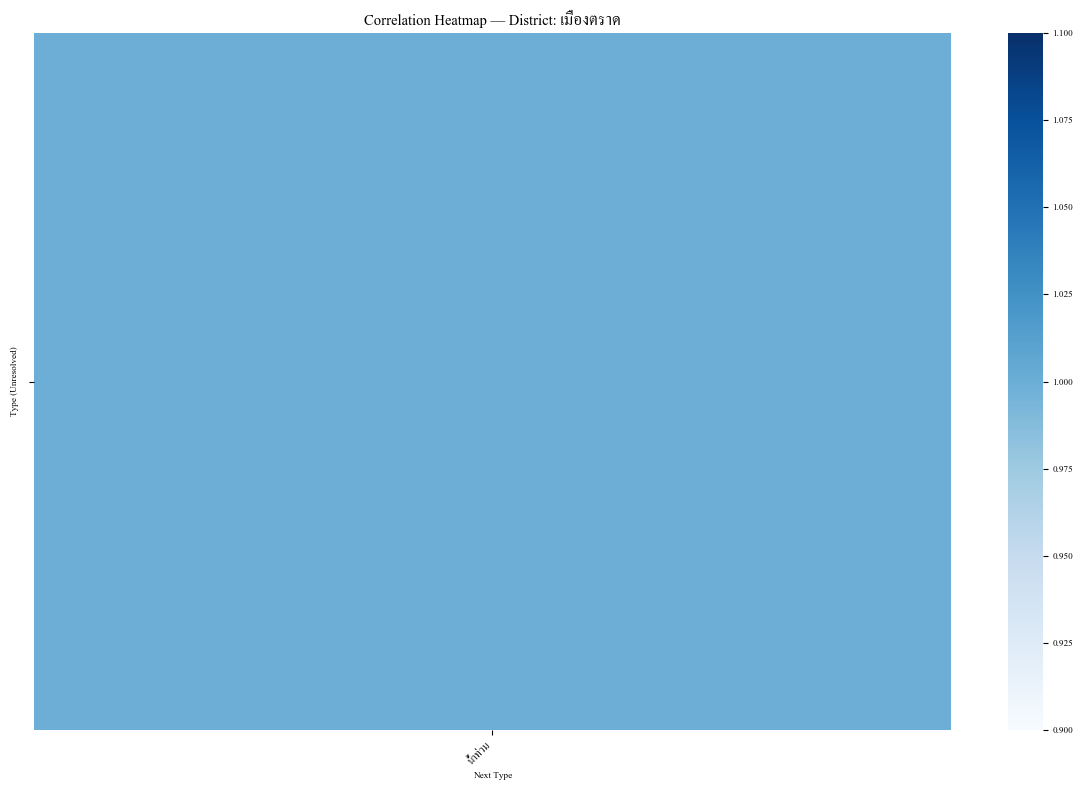

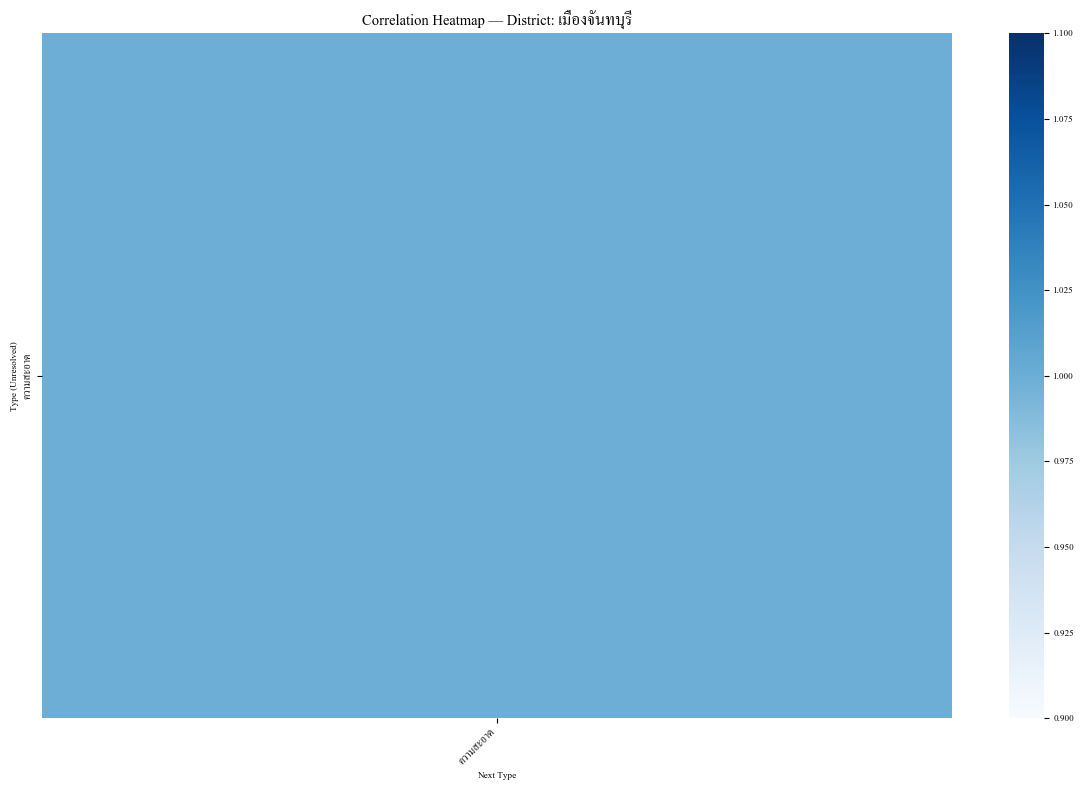

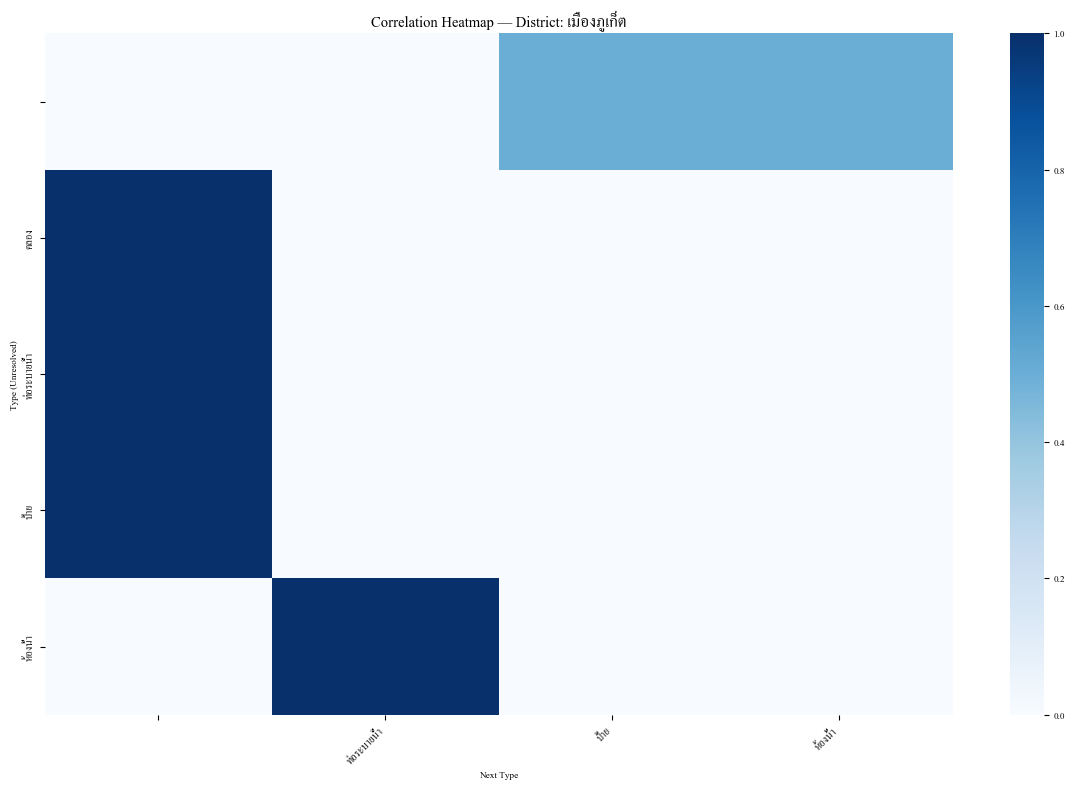

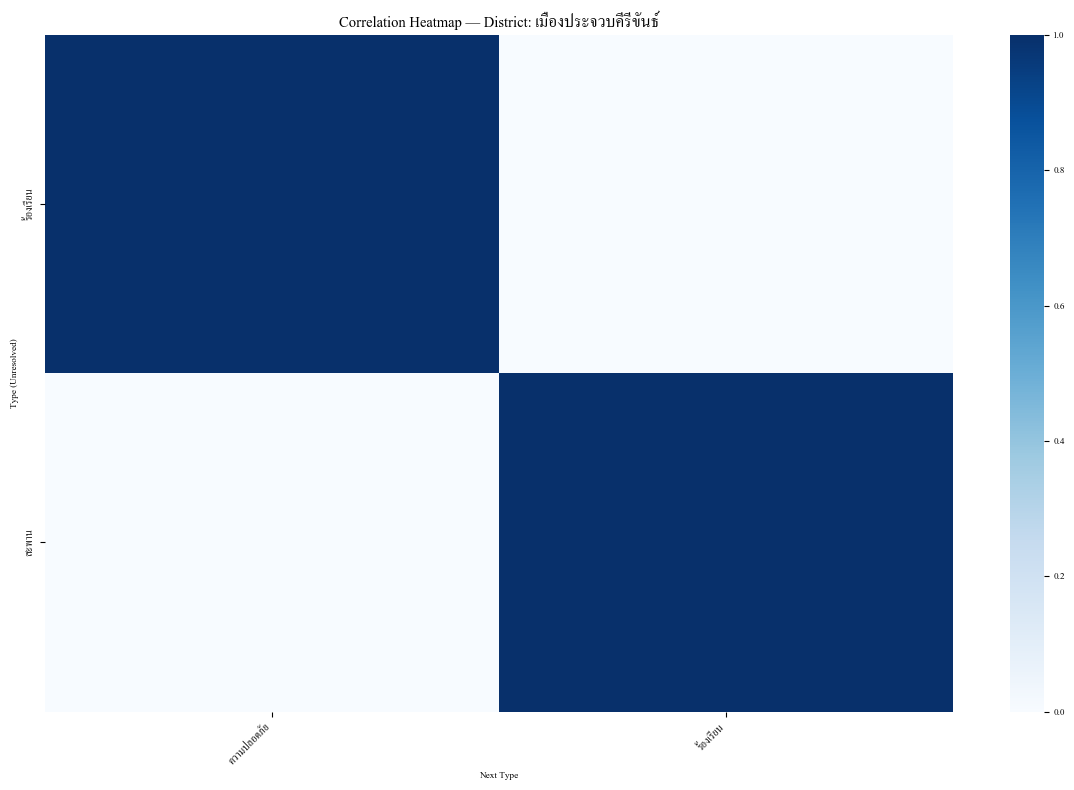

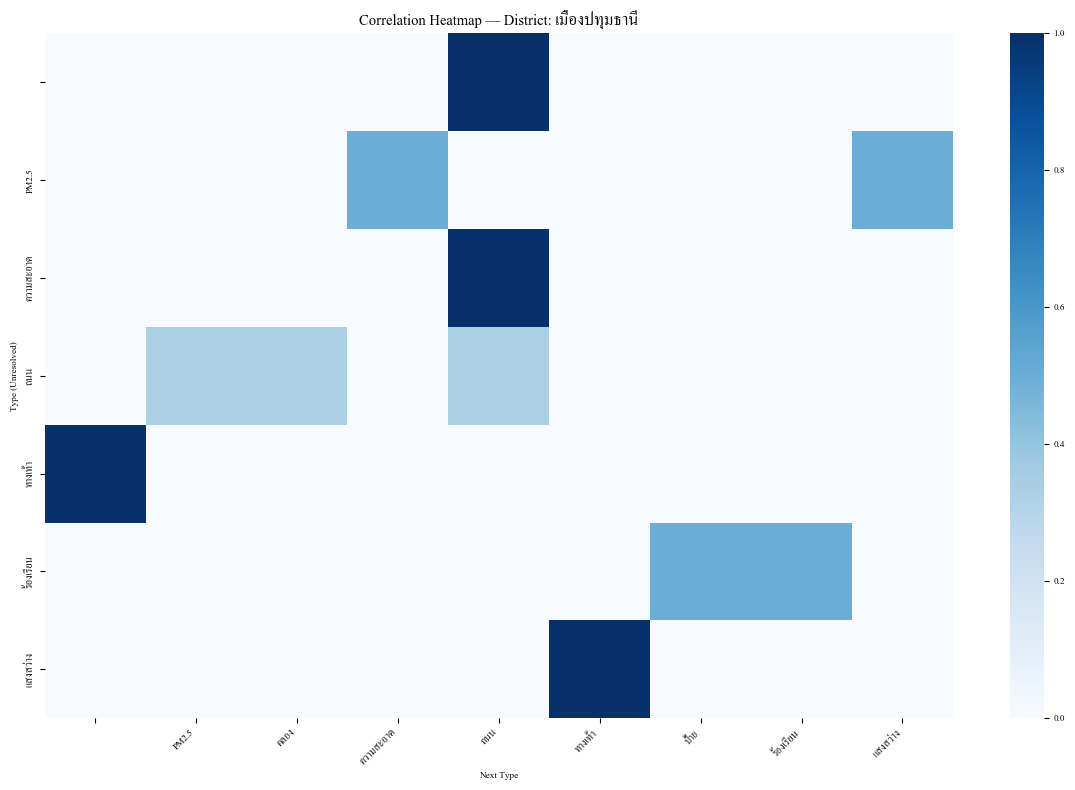

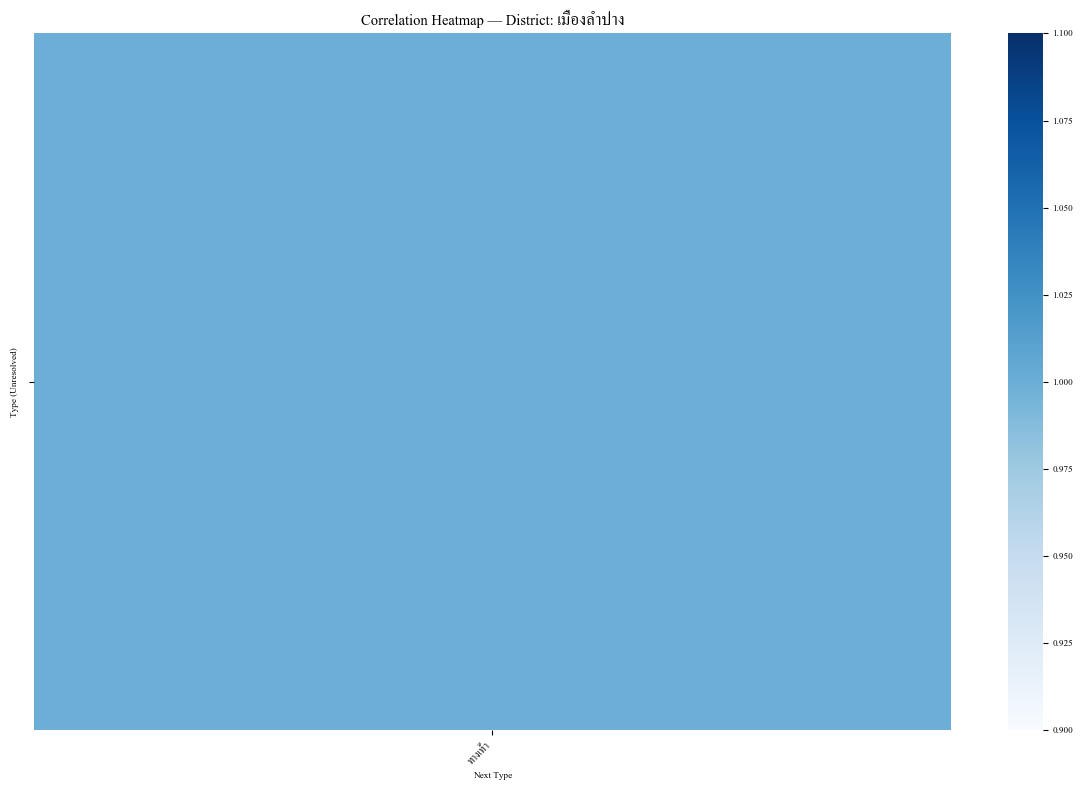

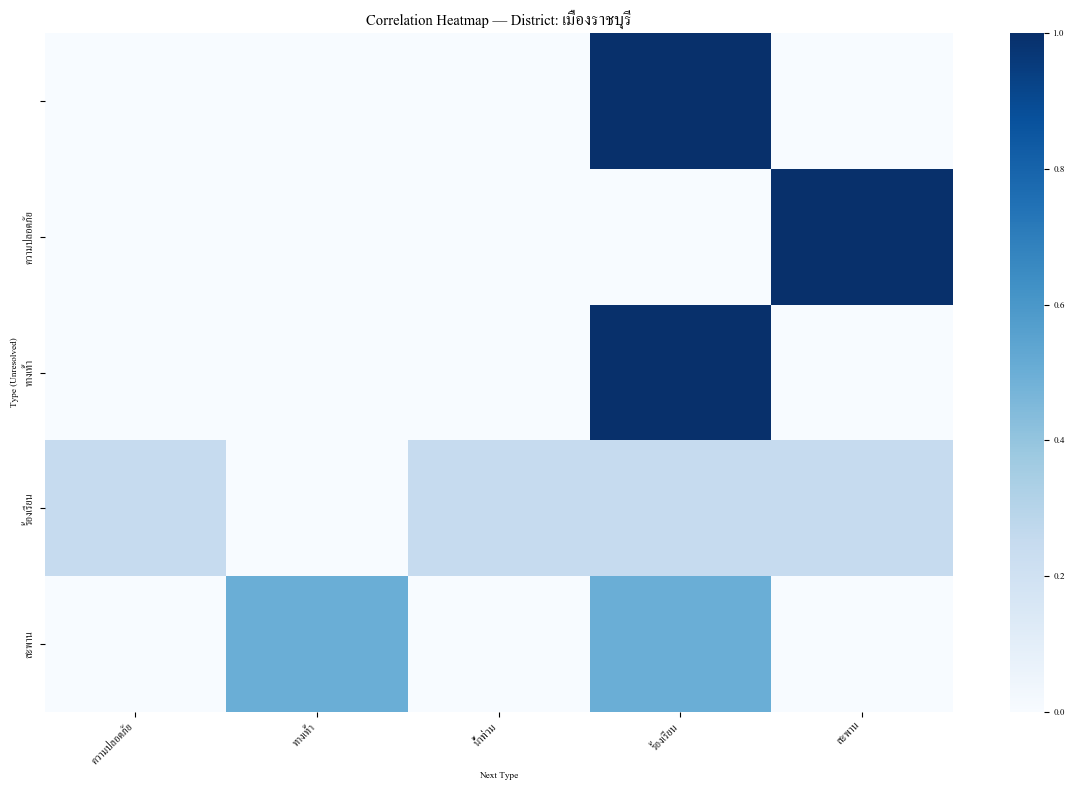

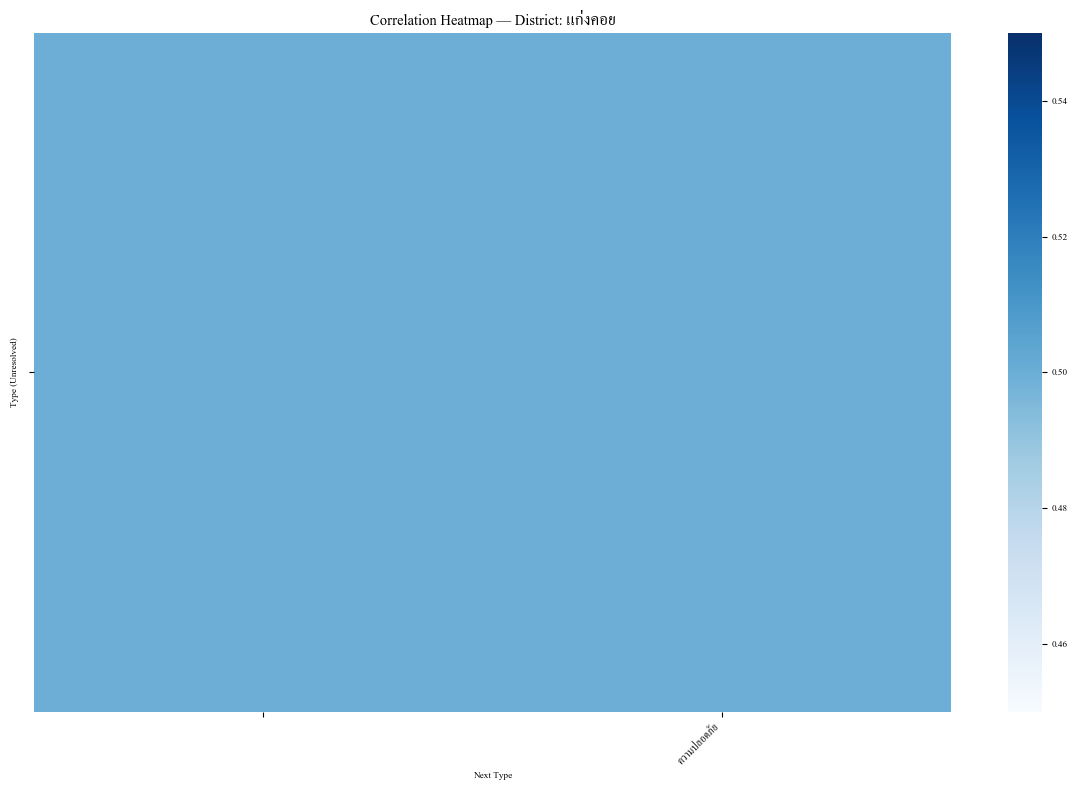

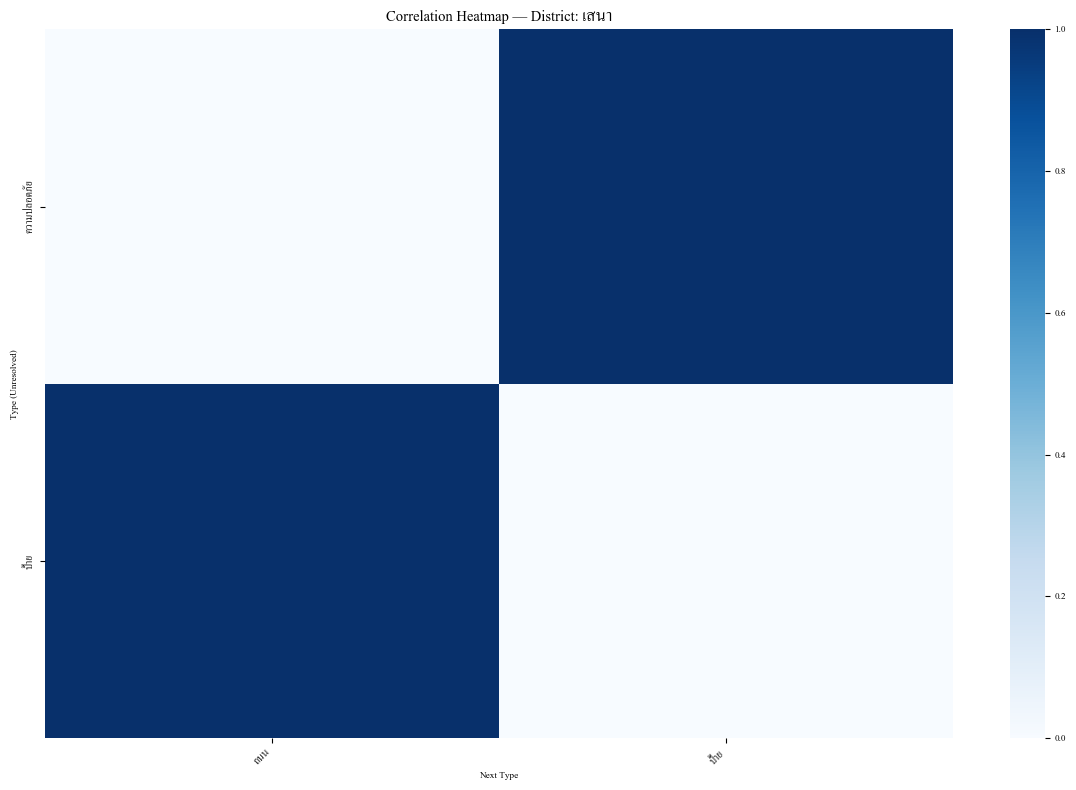

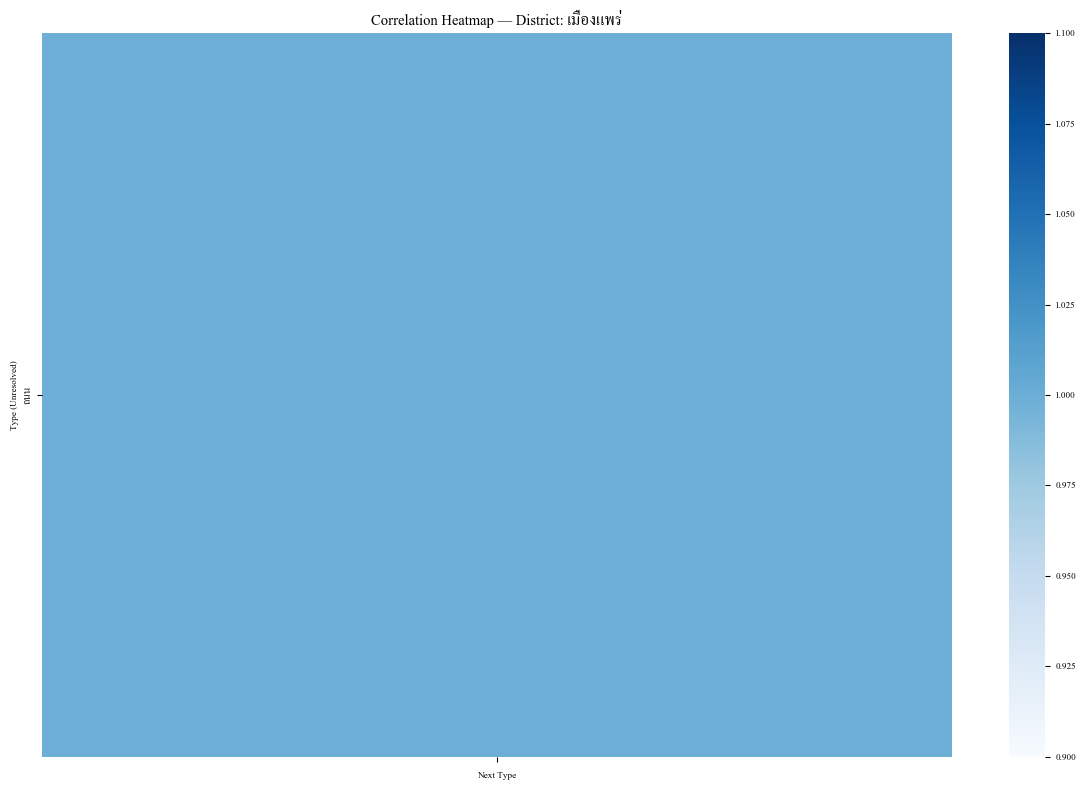

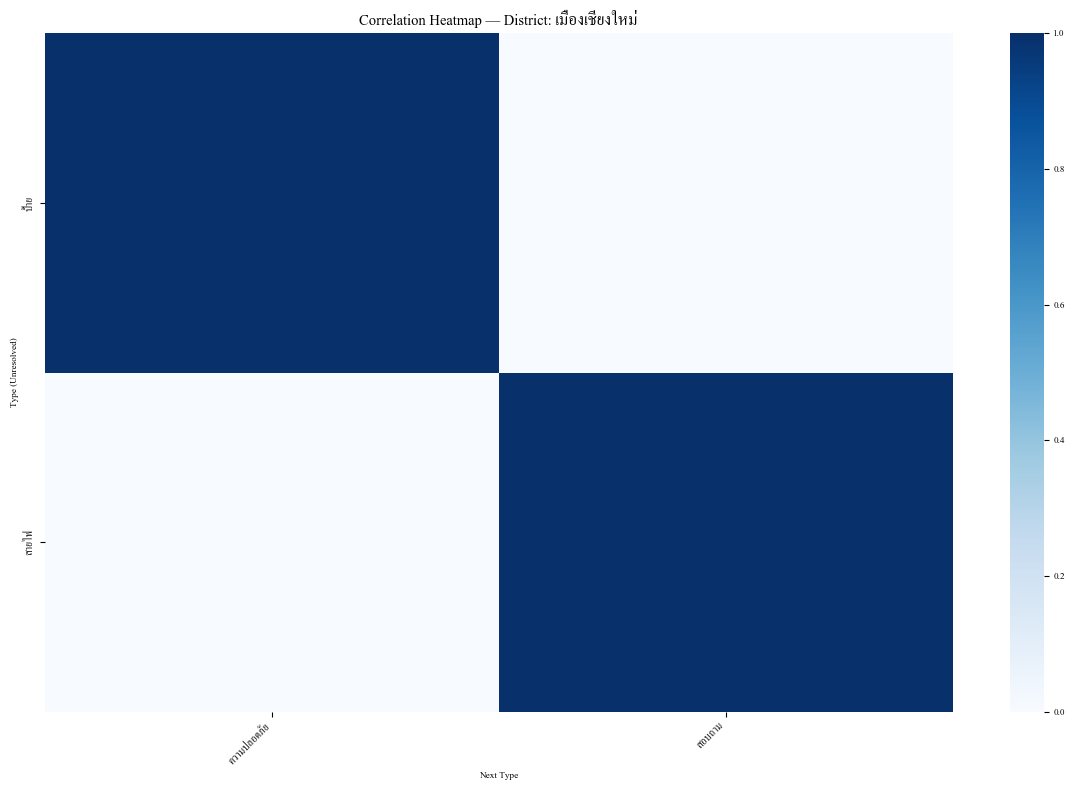

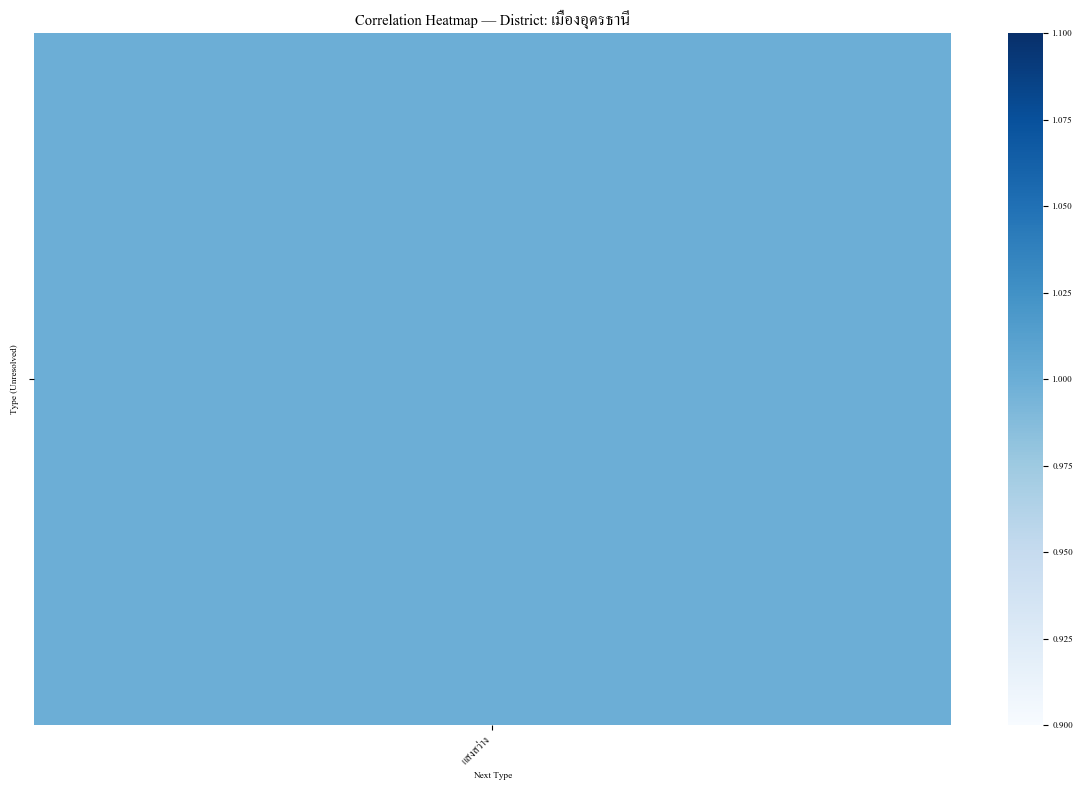

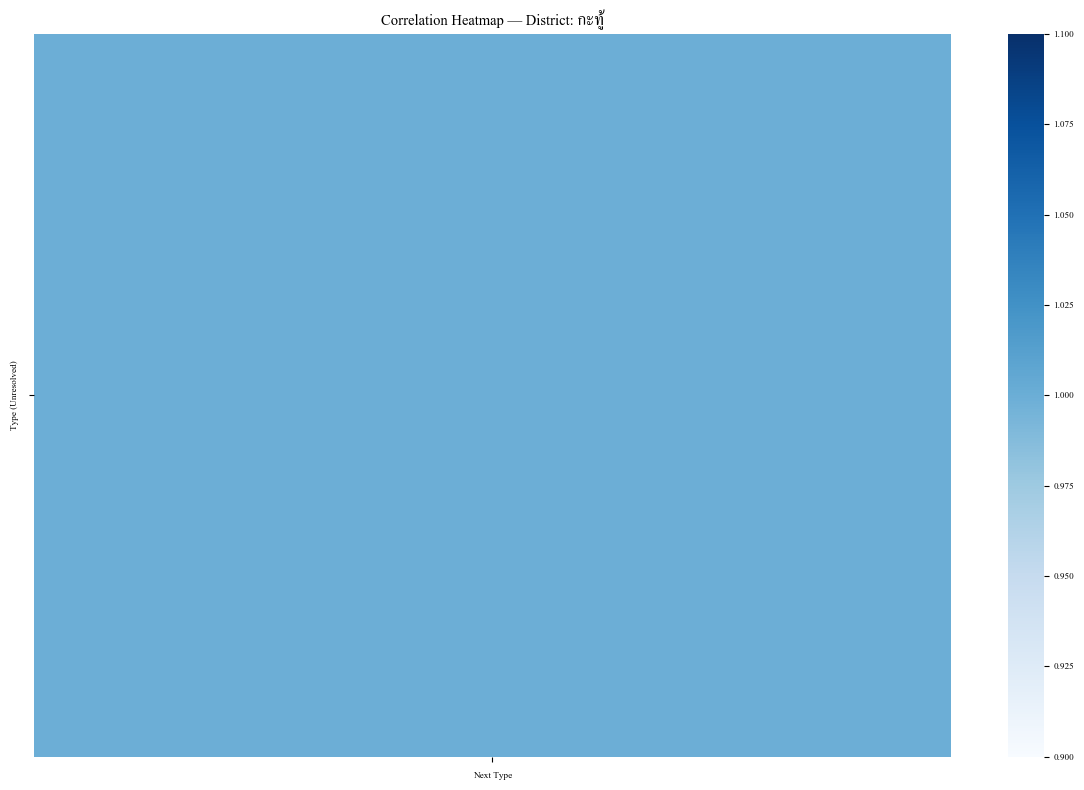

In [21]:
for d in districts:
    df_d = pattern[pattern['district'] == d]

    # Pivot: type → next_type matrix
    pivot = df_d.pivot_table(
        index='type',
        columns='next_type',
        values='count',
        fill_value=0
    )

    # Normalize rows (optional but recommended)
    pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_norm, cmap="Blues", annot=False)
    plt.title(f"Correlation Heatmap — District: {d}", fontsize=16)
    plt.xlabel("Next Type")
    plt.ylabel("Type (Unresolved)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()